# House Price Prediction — Exploratory Data Analysis
This notebook covers the first phase of the project — understanding the dataset,
identifying issues, and extracting initial insights before any cleaning or modeling.

**Dataset:** [Ames Housing Dataset (Kaggle)](https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset)  
**Target Variable:** `SalePrice`  
**Rows:** 1460 | **Columns:** 81

## Import the necessary libraries ##
- Numpy
- Pandas
- Matplotlib
- Seaborn

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset ##

In [126]:
df = pd.read_csv('../data/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. First Look
A quick glance at the first few rows reveals a mix of numerical and categorical
columns. Some columns like `Alley` already show NaN values, hinting at missing
data patterns we'll investigate further.

In [127]:
print(f'Rows: {df.shape[0]} and Columns: {df.shape[1]}')

Rows: 1460 and Columns: 81


## 2. Dataset Shape
The dataset contains **1460 rows and 81 columns** — reasonably sized for
traditional ML models without requiring heavy compute.

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 3. Data Types
- **35 int64** columns — counts, areas, years
- **3 float64** columns — some are years with missing values (pandas auto-converts int with nulls to float)
- **43 object** columns — categorical features like neighborhood, quality ratings

**Notable issue:** `GarageYrBlt` appears as `float64` because pandas upcasts integer columns containing ***missing values***. Conceptually it is a year variable, though its final treatment will depend on preprocessing.  
**Notable issue:** Quality/condition columns like `ExterQual`, `BsmtQual` are stored as
strings (Ex, Gd, TA, Fa, Po) but carry natural order — candidate for ***ordinal encoding***.

In [129]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 4. Statistical Summary
- `LotArea` shows a suspicious gap between Q3 and max — strong indicator of outliers.
- Several columns like `PoolArea`, `WoodDeckSF`, `EnclosedPorch` have Q1/Q2/Q3 all at zero,
meaning the feature is absent for the majority of houses — expected given the nature of these features.
- `SalePrice` ranges from 34,900 to 755,000 — a very wide range.

In [130]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending = False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


## 5. Missing Values
Several columns have significant missing data. However, in this dataset, many missing values are structural, meaning `NA` indicates the absence of a feature rather than unknown information.

For example, `PoolQC`, `MiscFeature`, `Alley`, `Fence`, and `FireplaceQu` are missing mostly because the corresponding feature does not exist for that house. These should not be treated the same way as genuinely missing values like LotFrontage.

It is also useful to track the percentage of missing values per column, since very high missingness can affect whether a feature is retained, imputed, or converted into an indicator. In some cases, the fact that a value is missing may itself carry predictive information. 

Missing-value handling should therefore be based on the meaning of the feature, not just the null count.

| Column | Missing % | Reason |
|---|---|---|
| PoolQC | ~99.5% | No Pool |
| MiscFeature | ~96% | No Misc Feature |
| Alley | ~93% | No Alley Access |
| Fence | ~80% | No Fence |
| FireplaceQu | ~47% | No Fireplace |
| LotFrontage | ~17% | Genuinely missing — needs imputation |

**Strategy:** Fill structural NAs with `"None"` or `0`. Impute genuinely missing ones.

In [131]:
print(df['SalePrice'].describe())
print()
print('Skewness: ', df['SalePrice'].skew())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness:  1.8828757597682129


## 6. Target Variable — SalePrice
- **Mean:** ~$180,921


- **Median:** ~$163,000
- **Skewness: 1.88** — highly right skewed
- A small number of very expensive houses pull the distribution to the right.
- `SalePrice` is strongly right-skewed. A ***log transformation*** is a strong candidate because it often stabilizes variance and makes the target distribution more symmetric, which can help many regression models. This will be evaluated during preprocessing.

In [132]:
outlier_summary = {}
outlier_cols = [] 
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1 # calculating the Inter-Quartile Range
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    if len(outliers) > 0: # store only those columns which actually have outliers
        outlier_summary[col] = len(outliers)
        outlier_cols.append(col)

outlier_df = pd.Series(outlier_summary).sort_values(ascending=False)
print(outlier_df)
print()
print('Total features with outliers:', outlier_df.shape[0])

EnclosedPorch    208
BsmtFinSF2       167
OverallCond      125
ScreenPorch      116
MSSubClass       103
MasVnrArea        96
LotFrontage       88
BsmtHalfBath      82
OpenPorchSF       77
LotArea           69
KitchenAbvGr      68
SalePrice         61
TotalBsmtSF       61
MiscVal           52
BedroomAbvGr      35
WoodDeckSF        32
GrLivArea         31
TotRmsAbvGrd      30
BsmtUnfSF         29
LowQualFinSF      26
3SsnPorch         24
GarageArea        21
1stFlrSF          20
PoolArea           7
BsmtFinSF1         7
YearBuilt          7
GarageCars         5
Fireplaces         5
2ndFlrSF           2
OverallQual        2
BsmtFullBath       1
dtype: int64

Total features with outliers: 31


## 7. Outliers
Outliers are far more widespread than initially observed — 31 numerical columns
are affected, not just `LotArea`.

Notable offenders:
- `EnclosedPorch` → 208 outliers
- `BsmtFinSF2` → 167 outliers
- `ScreenPorch` → 116 outliers
- `SalePrice` → 61 outliers

These columns are candidates for outlier treatment during preprocessing. Depending on the feature, potential approaches include capping, transformation, or leaving the values unchanged if they reflect valid extreme cases.

In [133]:
skewed_cols = {}
skew_cols = []
num_cols = df.select_dtypes(include = np.number).columns
for col in num_cols:
    skew = df[col].skew()
    if (skew > 1 or skew < -1): #values falling in range [-1, 1] are
                                #considered acceptable
        skewed_cols[col] = skew
        skew_cols.append(col)
skewness_summary = pd.Series(skewed_cols).sort_values(ascending = False)
print(skewness_summary)
print()
print('Total features with skewness > 1 or < -1:', skewness_summary.shape[0])

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
dtype: float64

Total features with skewness > 1 or < -1: 20


## 8. Skewed Features
20 numerical features have skewness above 1.0 — not just `SalePrice`.

Worst offenders:
- `MiscVal` → 24.5
- `PoolArea` → 14.8
- `LotArea` → 12.2
- `3SsnPorch` → 10.3

These features are strong candidates for transformation because of their heavy right skew. Log-based transformations such as `log1p` may help reduce skewness, but each feature should be evaluated individually since some may already be usable as-is or may respond better to other treatments.

In [150]:
#The data description allows us to understand which
#features have null values which correspond to 'Absence'
#of the feature and which features genuinely have missing values

# Type 1: NA genuinely means "None" / absence of feature
none_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
             'GarageType','GarageFinish','GarageQual','GarageCond',
             'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1',
             'BsmtFinType2','MasVnrType']

print("=== NA means 'None' (not truly missing) ===")
for col in none_cols:
    print(f"  {col}: {df[col].isnull().sum()} nulls")

# Type 2: Genuinely missing — needs imputation
print("\n=== Genuinely Missing (needs imputation) ===")
genuine = ['LotFrontage', 'Electrical']
for col in genuine:
    print(f"  {col}: {df[col].isnull().sum()} nulls")

=== NA means 'None' (not truly missing) ===
  PoolQC: 1453 nulls
  MiscFeature: 1406 nulls
  Alley: 1369 nulls
  Fence: 1179 nulls
  FireplaceQu: 690 nulls
  GarageType: 81 nulls
  GarageFinish: 81 nulls
  GarageQual: 81 nulls
  GarageCond: 81 nulls
  BsmtQual: 37 nulls
  BsmtCond: 37 nulls
  BsmtExposure: 38 nulls
  BsmtFinType1: 37 nulls
  BsmtFinType2: 38 nulls
  MasVnrType: 872 nulls

=== Genuinely Missing (needs imputation) ===
  LotFrontage: 259 nulls
  Electrical: 1 nulls


## 9. Two Types of Missing Values
A critical distinction — not all nulls mean the same thing:

**Type 1 — NA = Absence of feature (15 columns)**
Per the data description, NA literally means the feature doesn't exist
for that house. e.g. PoolQC is null because the house has no pool.
→ Strategy: fill with `"None"` (categorical) or `0` (numerical)

**Type 2 — Genuinely Missing (2 columns)**
- `LotFrontage` → 259 nulls — street frontage not recorded
- `Electrical` → 1 null — electrical system not recorded
  
A useful first distinction is that many nulls are structural, while a smaller set appear genuinely missing and may require imputation. Some columns may still need case-by-case verification against the data description before final preprocessing decisions are made.

→ Strategy: impute using median / mode

In [136]:
cat_cols = df.select_dtypes(include = 'object').columns
print('Number of unique values per object-type column:')
print()
cardinality = df[cat_cols].nunique().sort_values(ascending = False)
print(cardinality)

Number of unique values per object-type column:

Neighborhood     25
Exterior2nd      16
Exterior1st      15
SaleType          9
Condition1        9
Condition2        8
HouseStyle        8
RoofMatl          8
Functional        7
BsmtFinType2      6
Heating           6
RoofStyle         6
SaleCondition     6
BsmtFinType1      6
GarageType        6
Foundation        6
Electrical        5
FireplaceQu       5
HeatingQC         5
GarageQual        5
GarageCond        5
MSZoning          5
LotConfig         5
ExterCond         5
BldgType          5
BsmtExposure      4
MiscFeature       4
Fence             4
LotShape          4
LandContour       4
BsmtCond          4
KitchenQual       4
ExterQual         4
BsmtQual          4
LandSlope         3
GarageFinish      3
MasVnrType        3
PavedDrive        3
PoolQC            3
Utilities         2
CentralAir        2
Street            2
Alley             2
dtype: int64


## 10. Categorical Cardinality
Most categorical columns have low unique value counts — safe for One-Hot Encoding.
However, 3 columns have high cardinality:

- `Neighborhood` → 25 unique values
- `Exterior2nd` → 16 unique values
- `Exterior1st` → 15 unique values

These columns have relatively higher cardinality than the rest of the categorical features. One-hot encoding is still possible, but it may increase dimensionality. Depending on model performance, grouping rare categories or using alternative encoding strategies can be considered.

## 11. Feature Engineering Opportunities
Raw features don't always tell the full story. Several meaningful features
can be derived from existing columns:

| New Feature | Formula | Why |
|---|---|---|
| `TotalSF` | BsmtSF + 1stFlrSF + 2ndFlrSF | Total house size is more meaningful than parts |
| `HouseAge` | YrSold - YearBuilt | Age at time of sale matters more than build year |
| `RemodAge` | YrSold - YearRemodAdd | Recency of remodel affects price |
| `TotalBath` | Full + 0.5 × Half + BsmtFull + 0.5 × BsmtHalf | Combined bathroom count |
| `HasPool` | PoolArea > 0 | Binary — presence matters more than size |
| `HasGarage` | GarageArea > 0 | Binary flag |
| `HasFireplace` | Fireplaces > 0 | Binary flag |

These will be created during the feature engineering phase.

## Visualizing the Findings
We have successfully scoured the data for various insights. Missing values,
outliers, skewed data points are spread across the dataset. Now is a good time
to visualize them:

### Missing Values — Visualization
The bar chart confirms the missing value analysis above visually.
Columns like `PoolQC`, `MiscFeature`, and `Alley` are clearly dominant,
all of which represent absence of a feature rather than truly missing data.

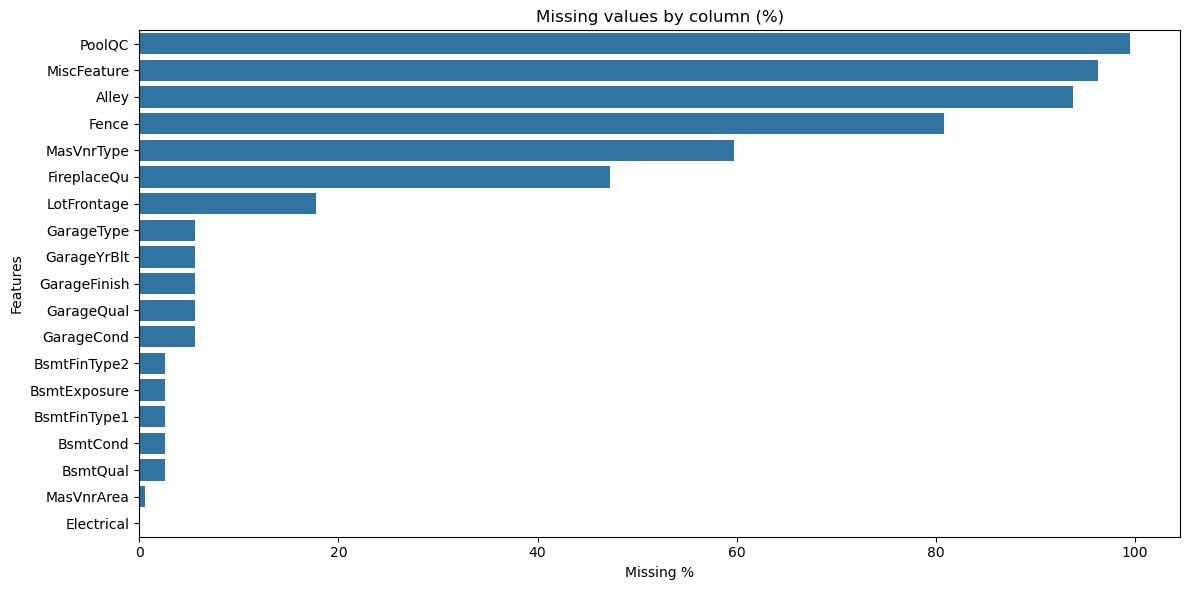

In [146]:
missing_percent = df.isnull().sum() / len(df) * 100;
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending = False)

plt.figure(figsize=(12,6))
sns.barplot(x = missing_percent.values, y = missing_percent.index)
plt.title('Missing values by column (%)')
plt.xlabel('Missing %')
plt.ylabel('Features')
plt.savefig('../plots/missing_values.png')
plt.tight_layout()
plt.show()

### Outliers — Visualization
Boxplots generated for all 31 columns flagged by the IQR method.
Columns like `EnclosedPorch`, `LotArea`, and `GrLivArea` show
significant outliers that will be addressed during preprocessing.

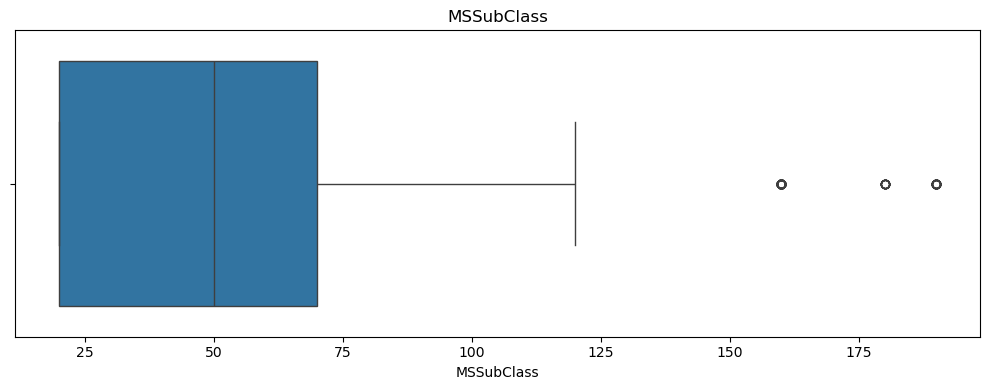

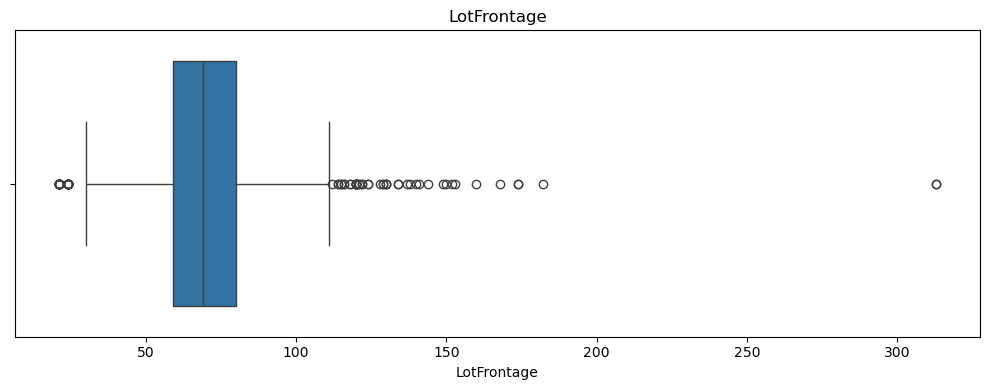

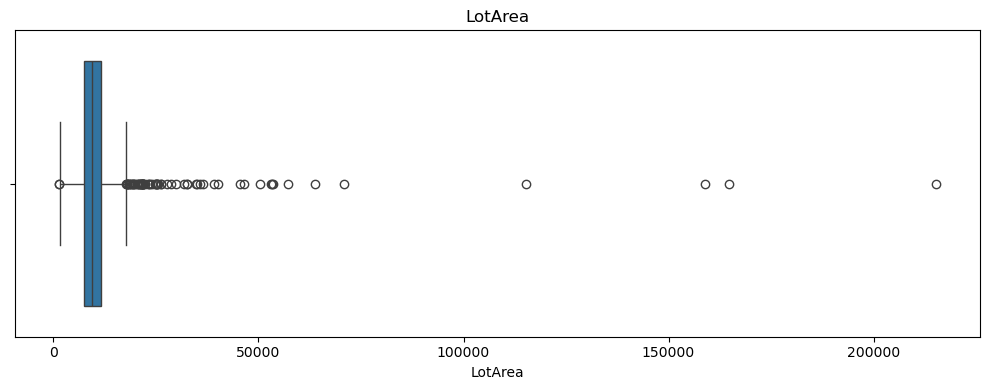

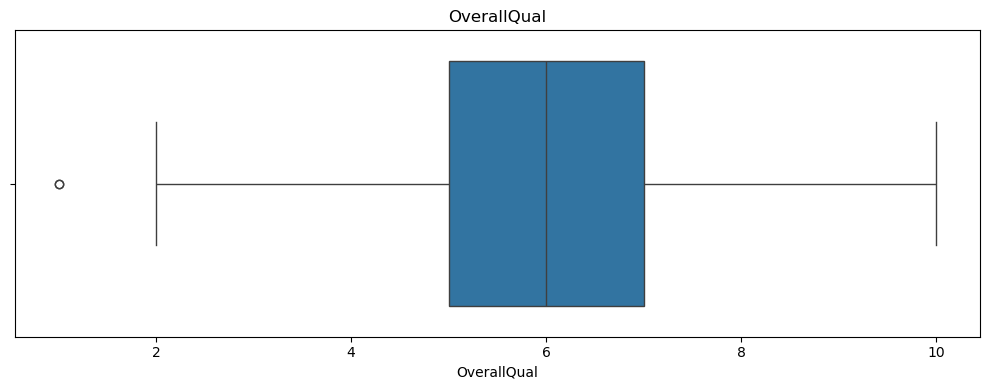

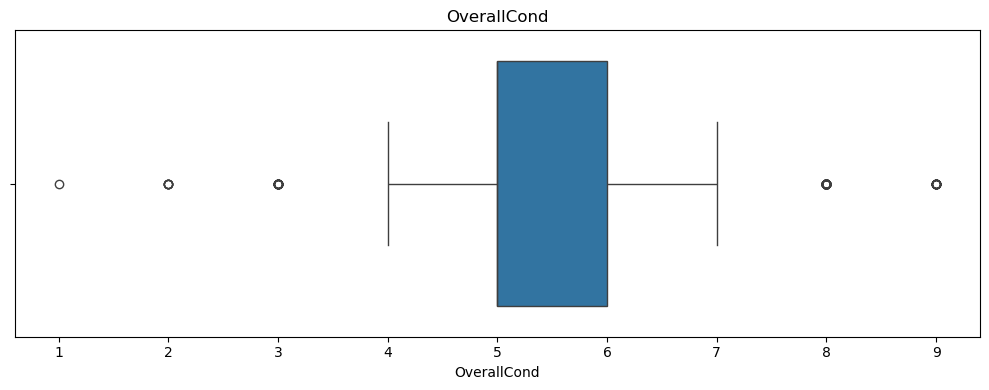

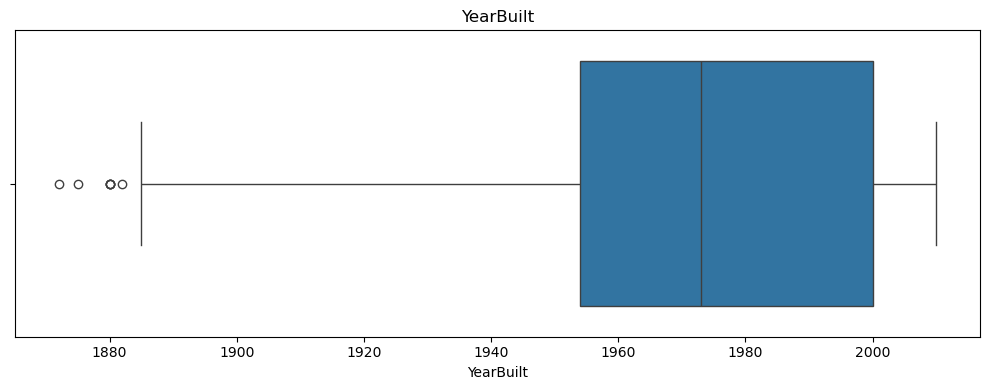

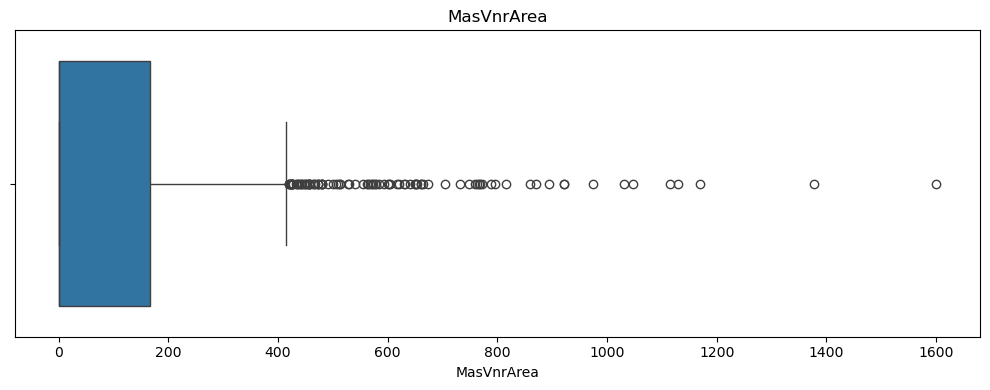

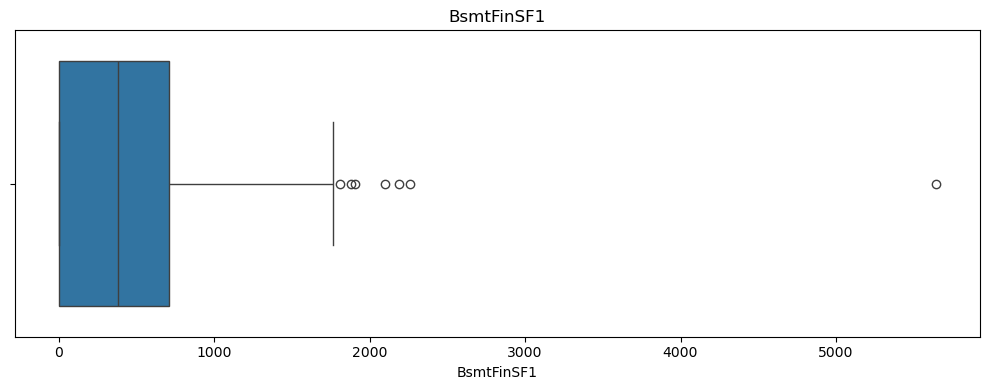

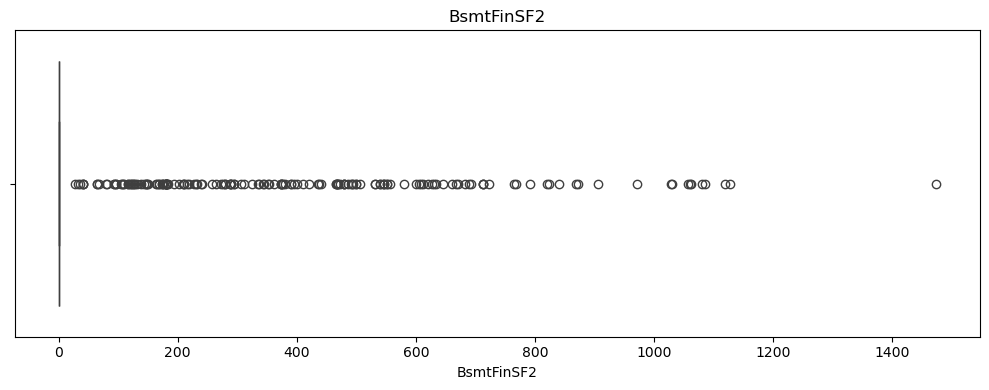

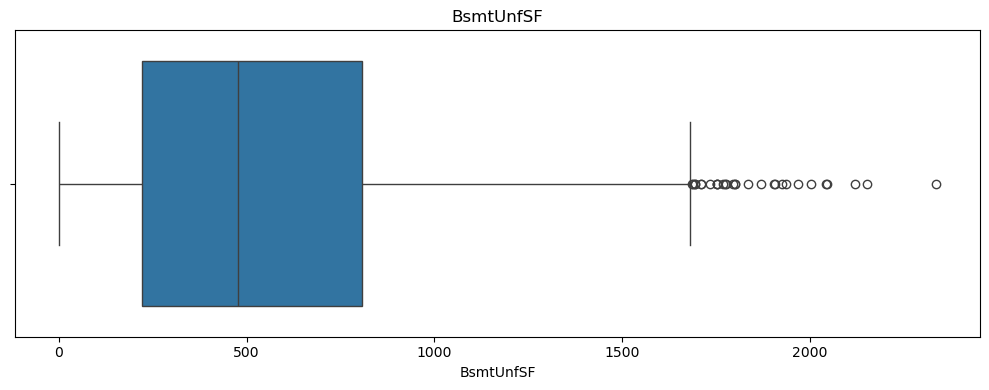

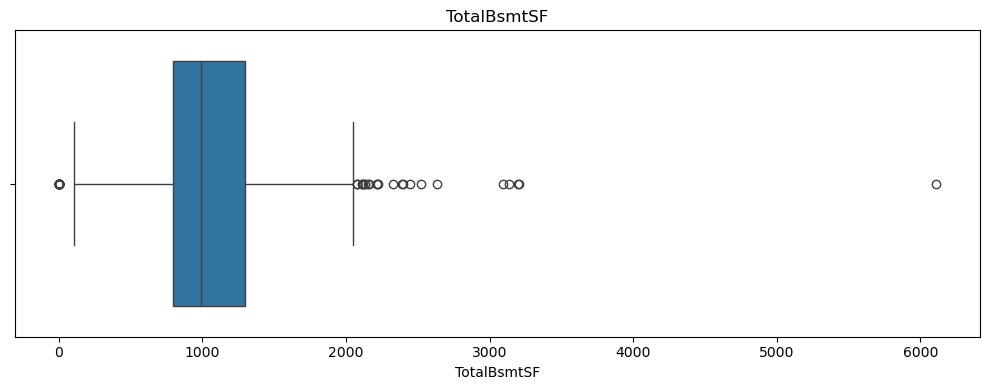

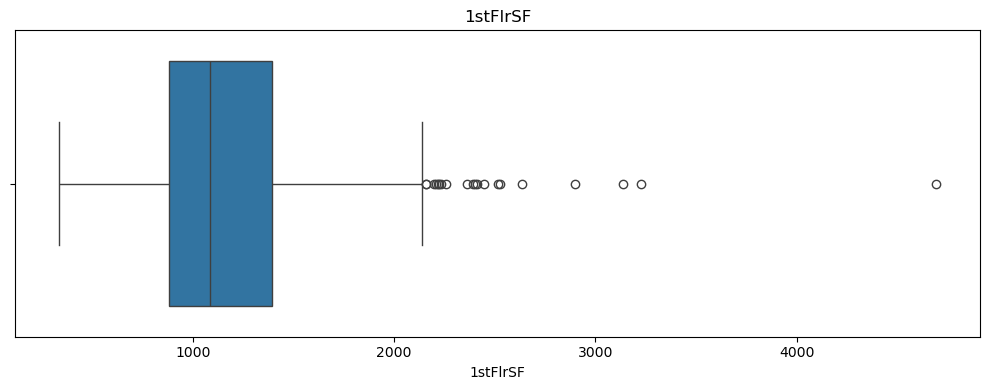

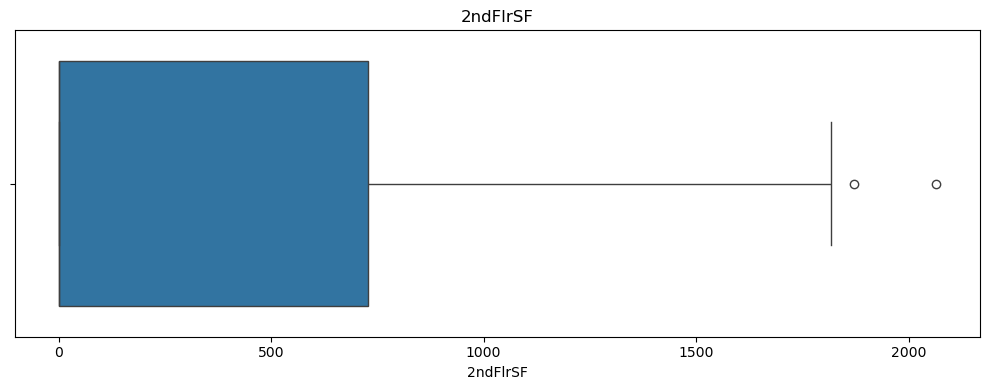

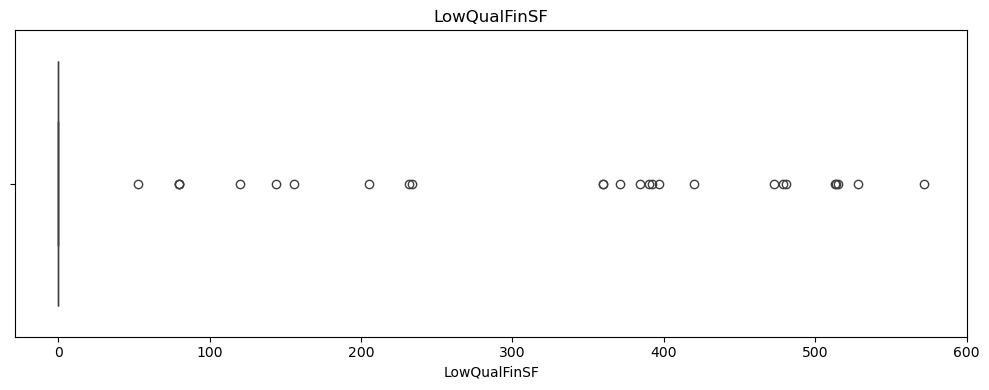

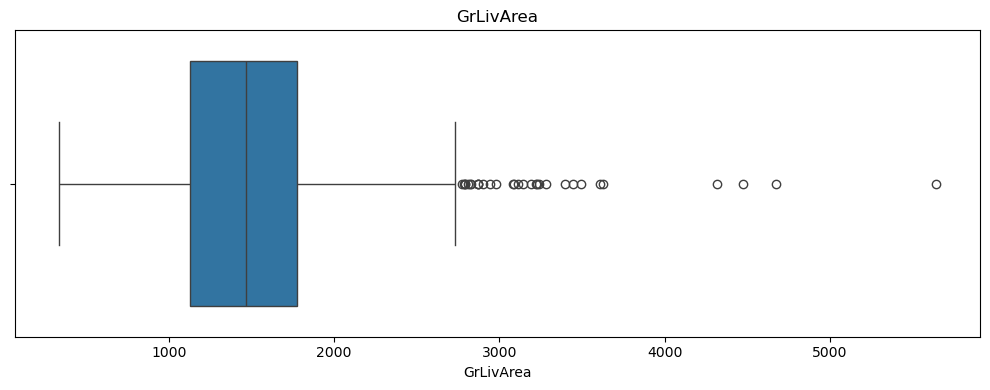

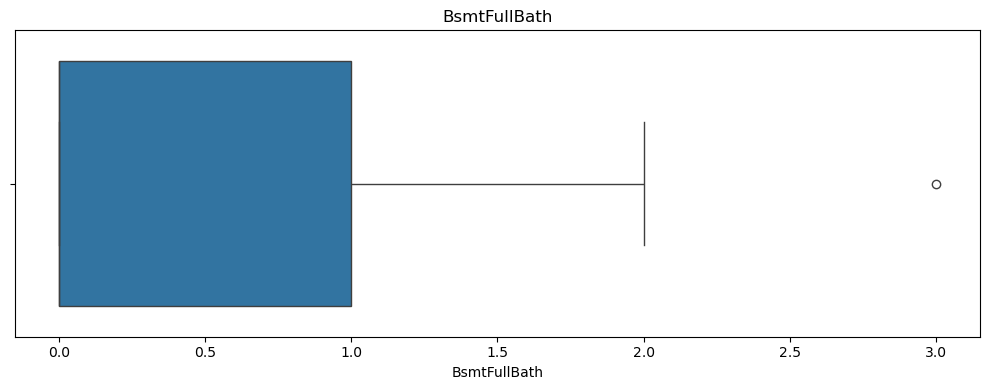

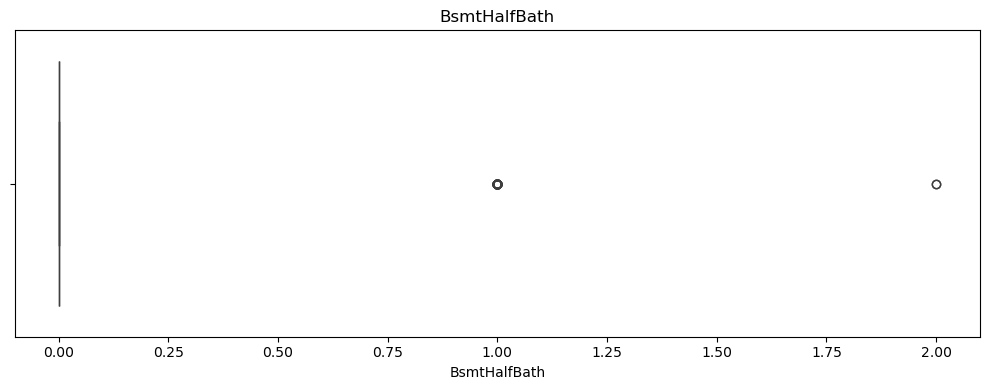

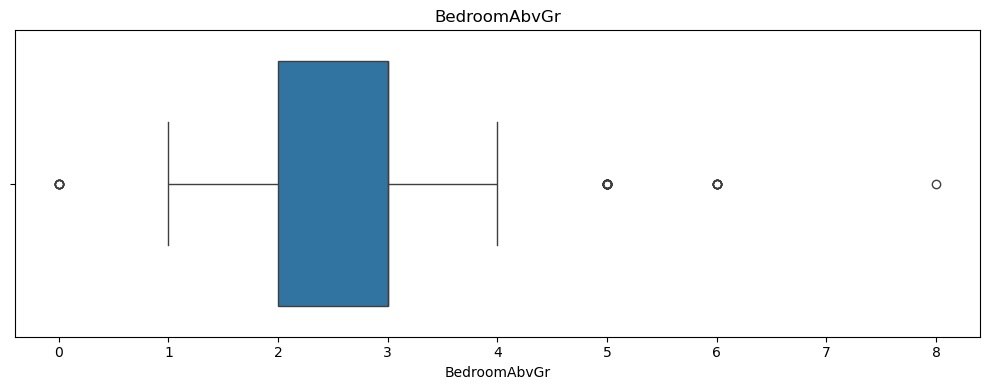

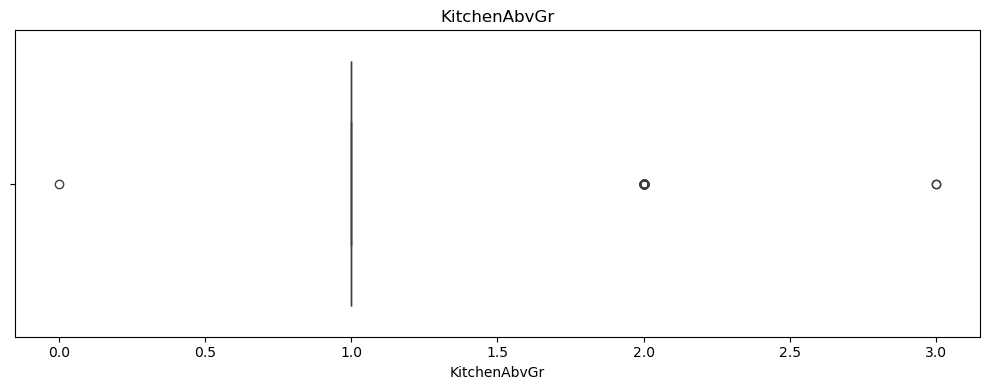

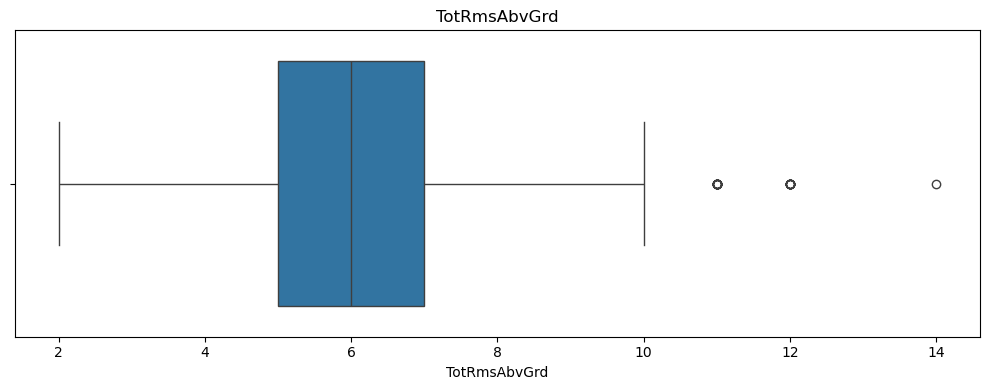

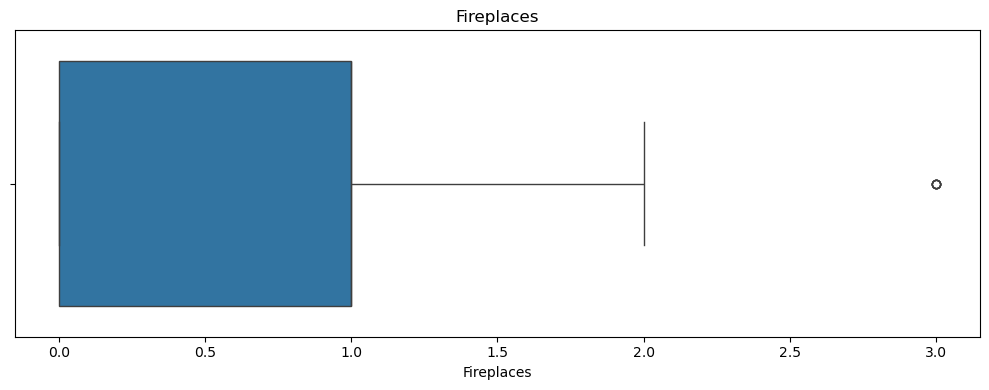

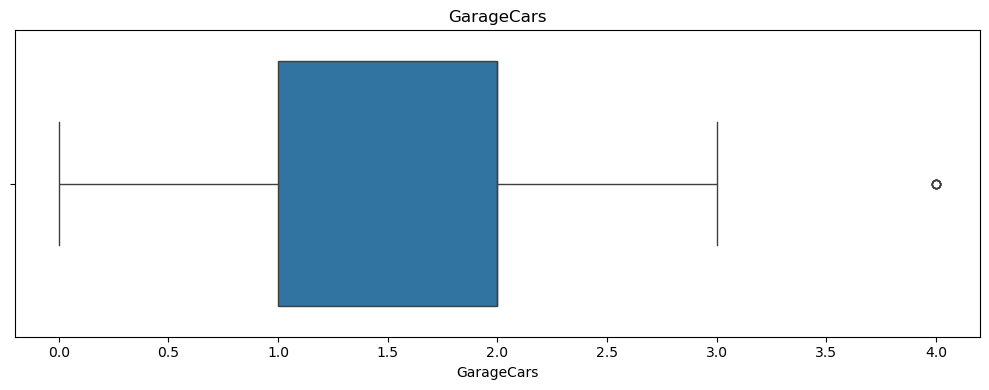

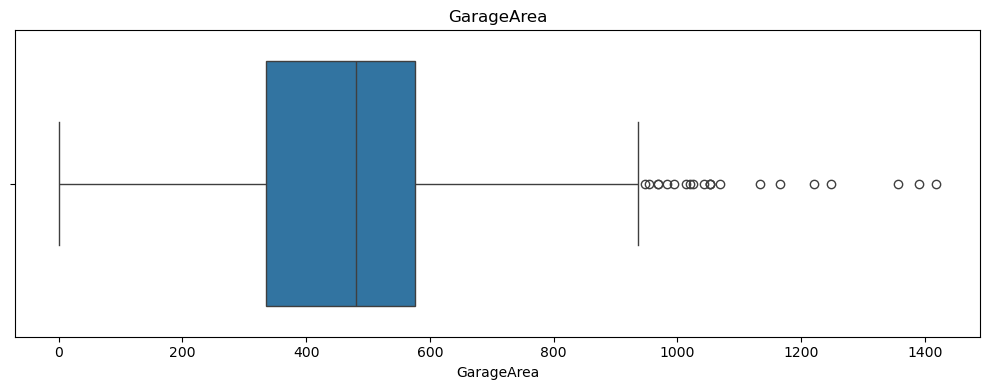

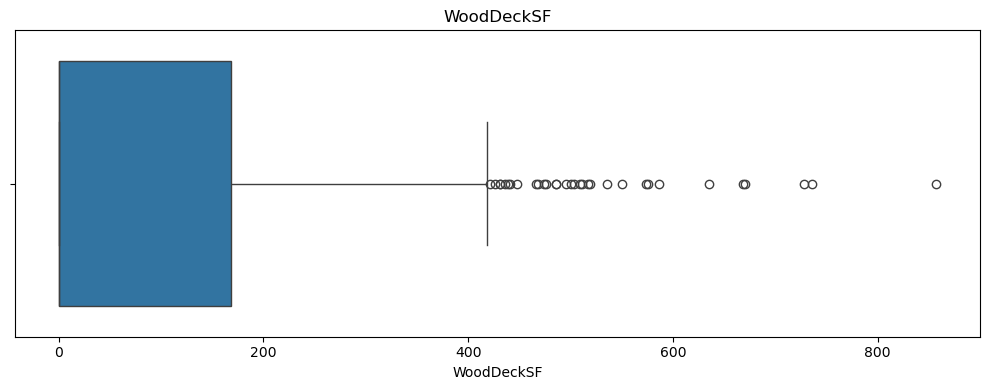

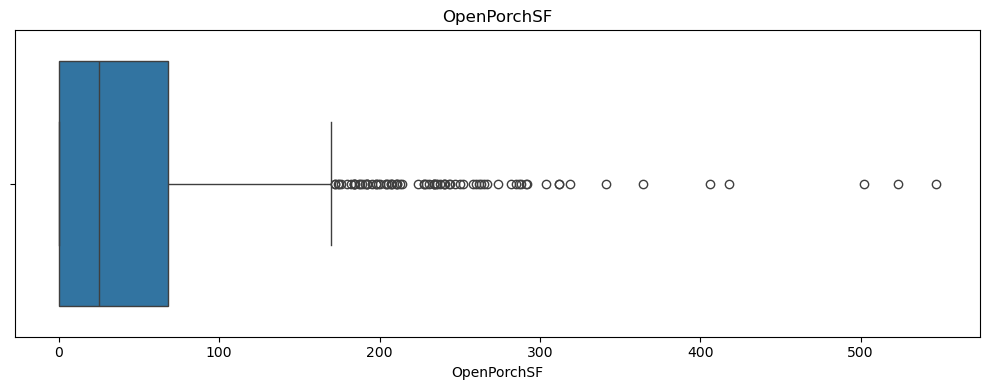

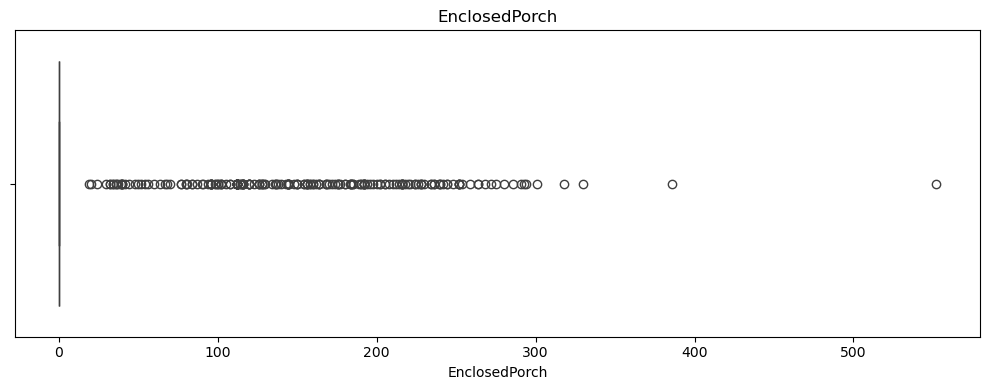

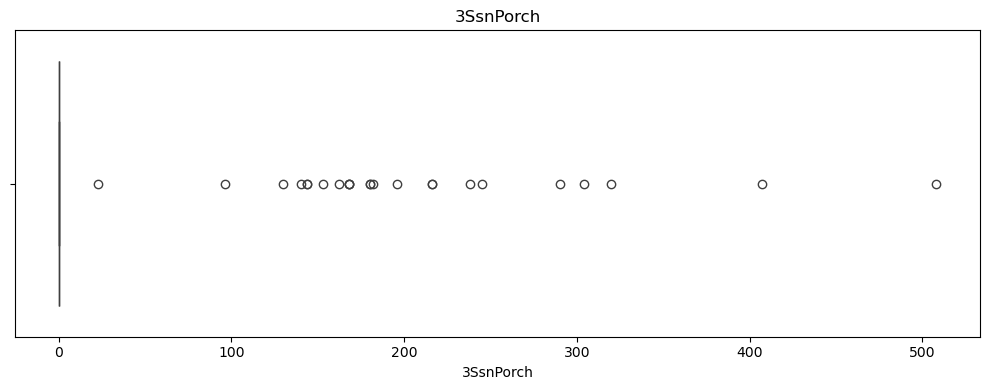

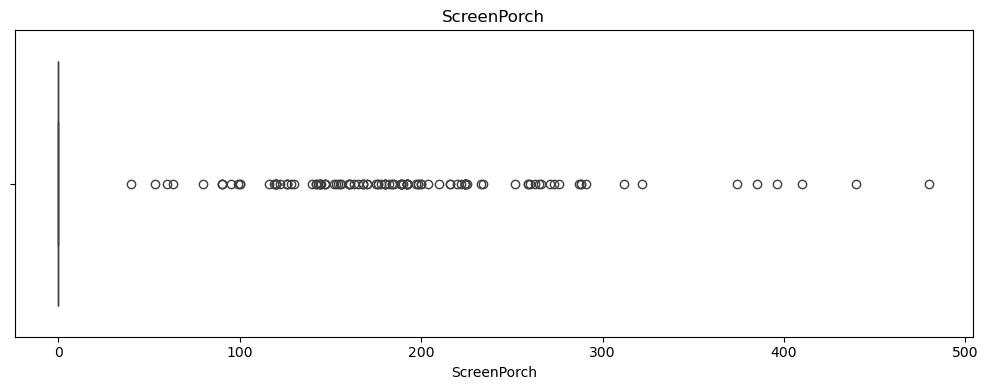

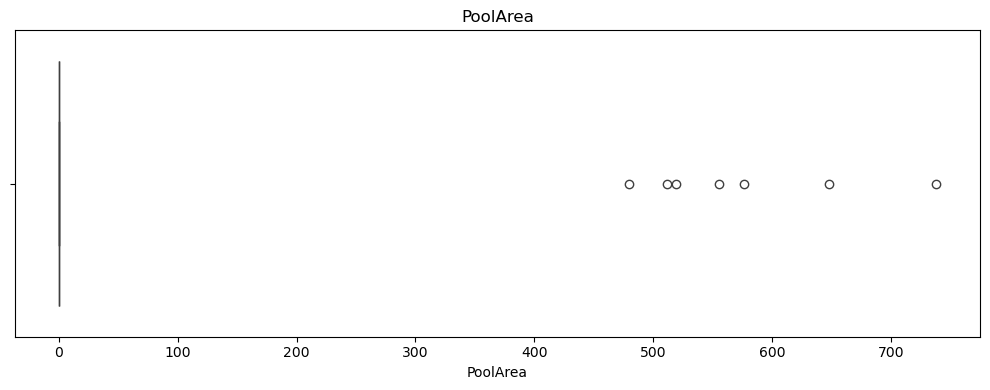

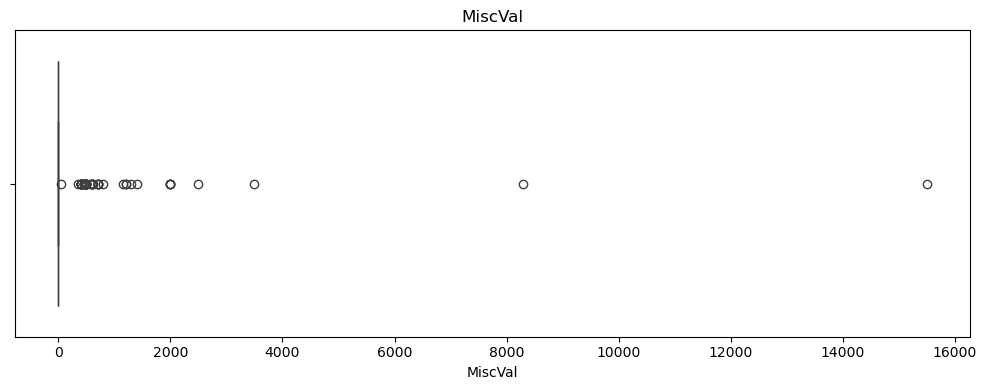

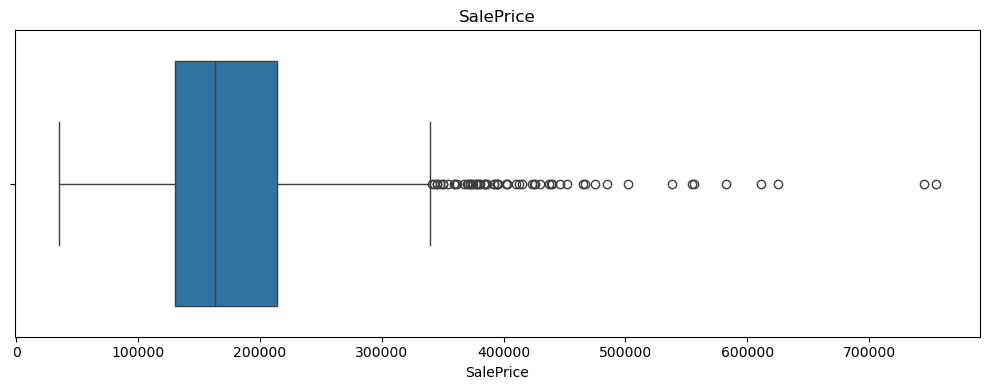

In [145]:
for col in outlier_cols:
    fig, ax = plt.subplots(figsize=(10,4))
    sns.boxplot(x = df[col], ax = ax)
    ax.set_title(col)
    plt.tight_layout()
    plt.show()

### Skewed Features — Visualization
KDE plots generated for all 20 highly skewed features (skewness > 1 or < -1).
Most distributions show a strong right skew — majority of values are
concentrated at the lower end with a long tail towards higher values.
Log transformation will be applied during preprocessing to normalize these.

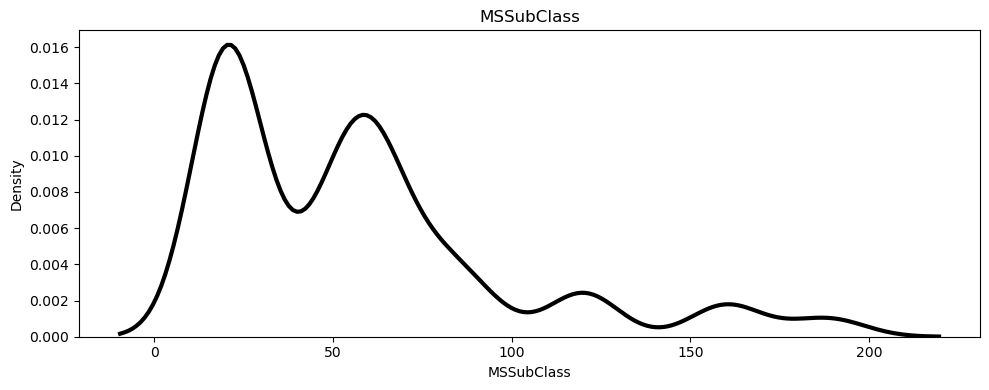

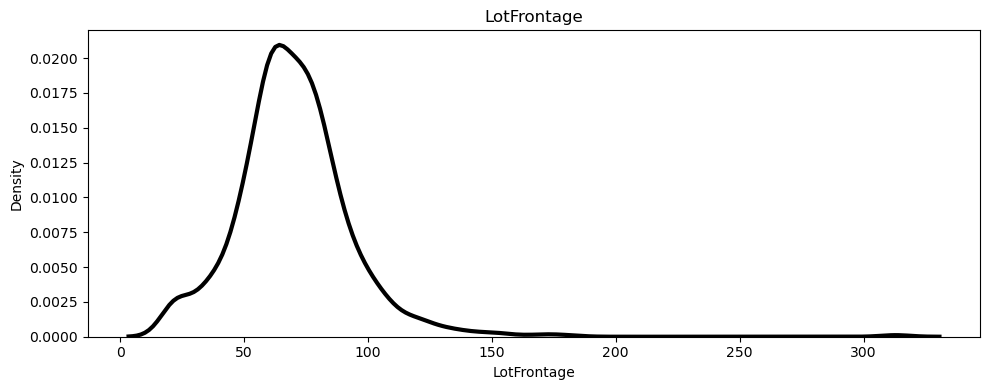

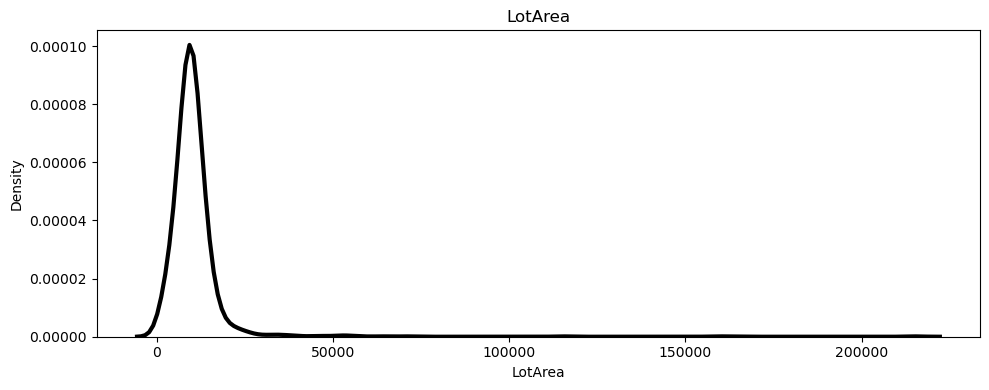

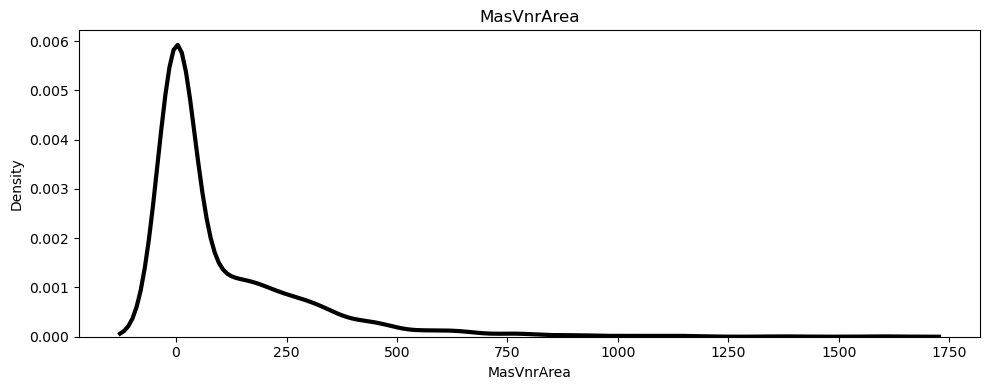

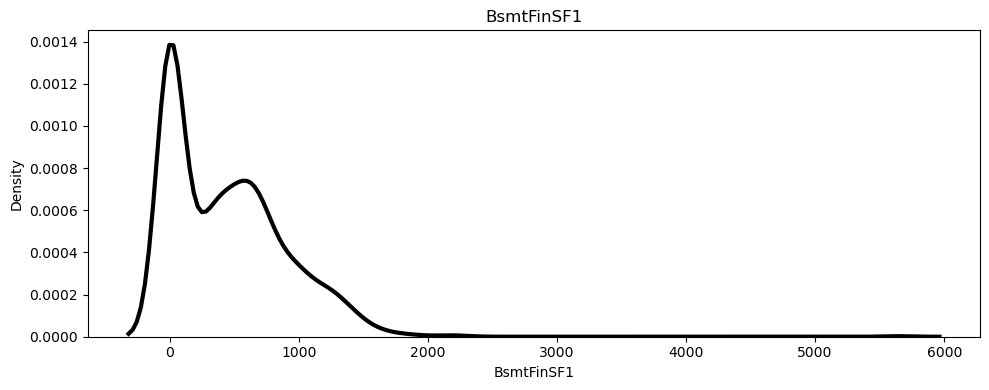

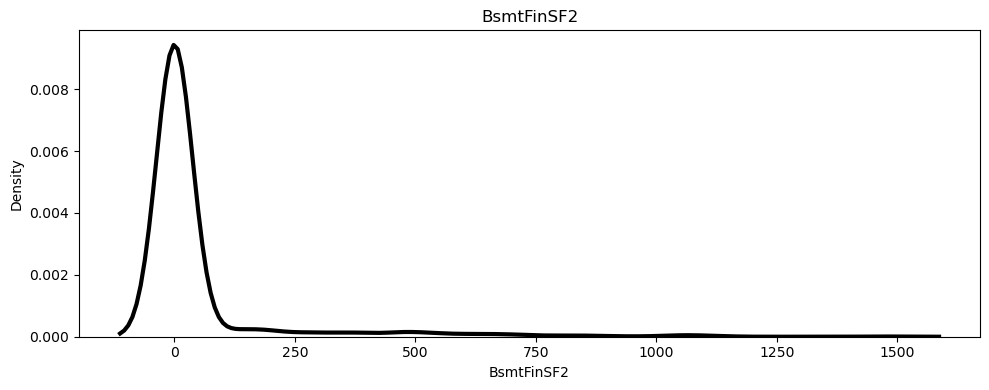

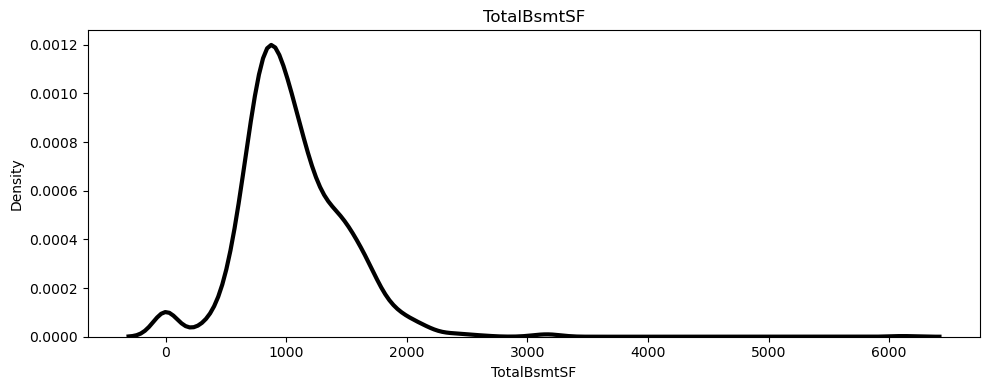

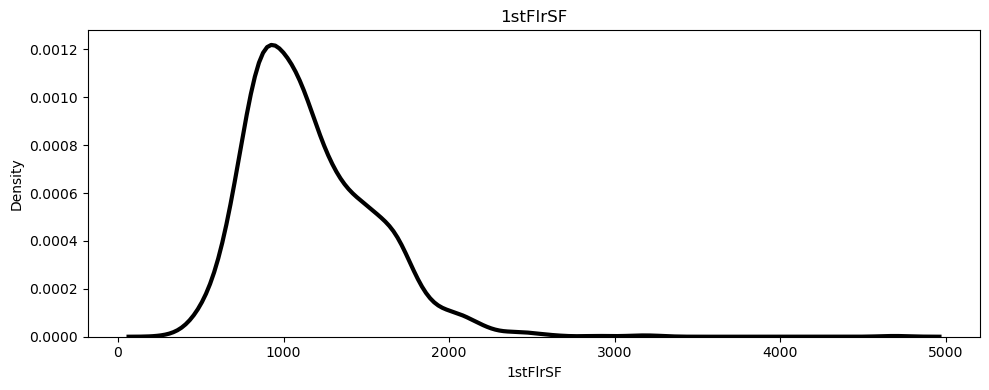

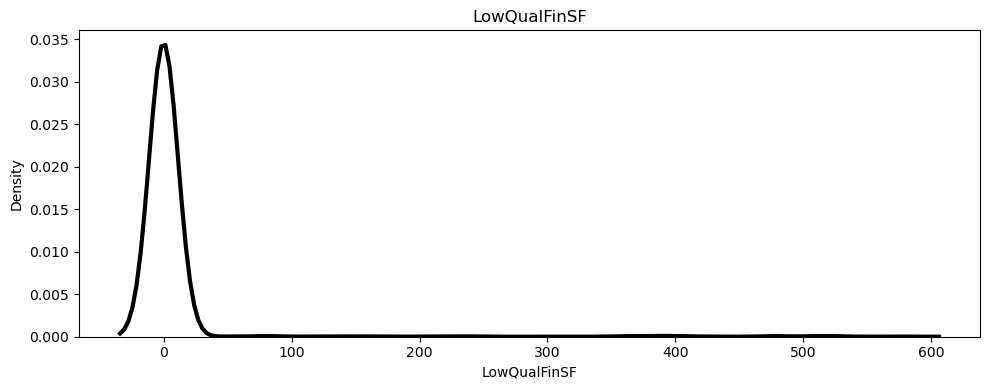

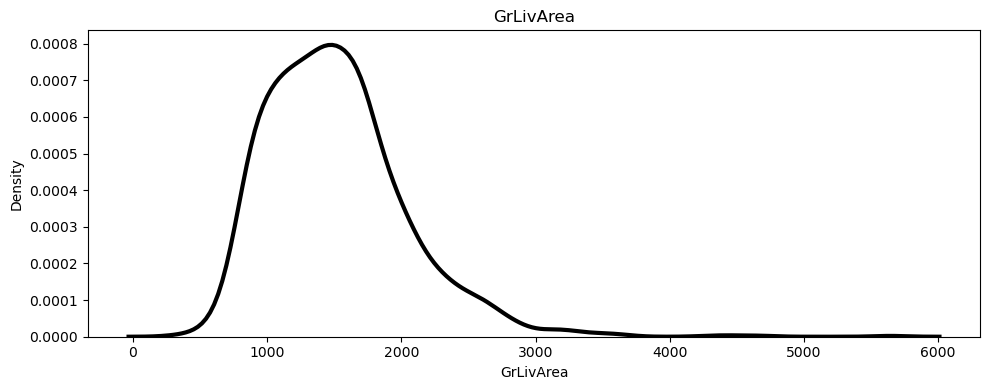

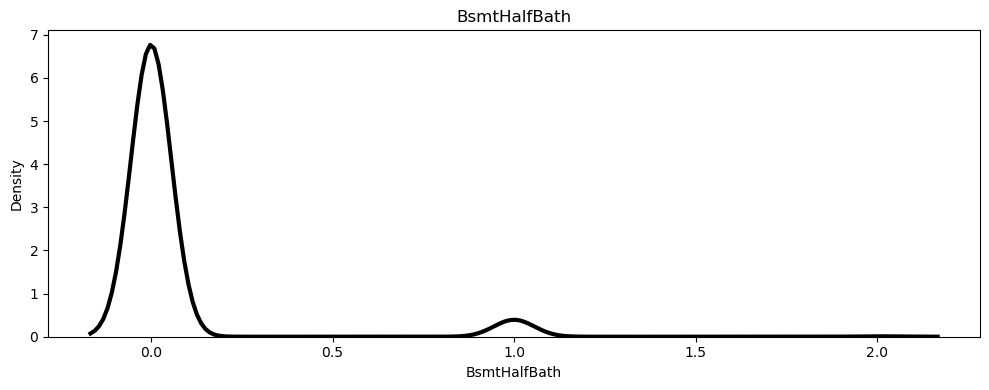

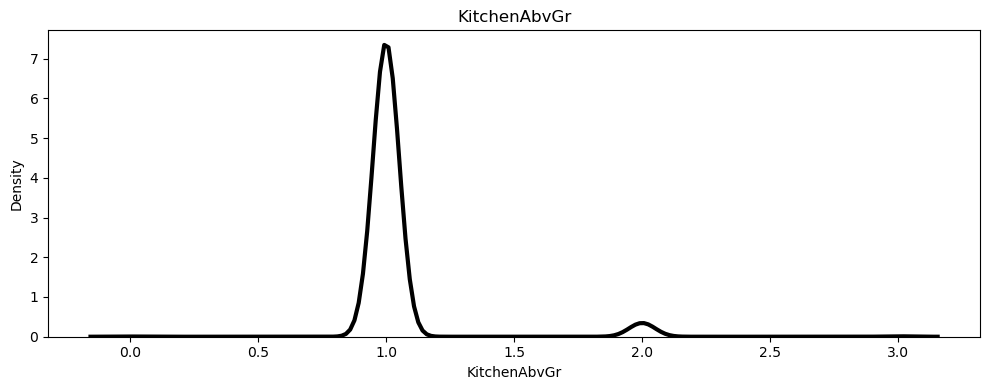

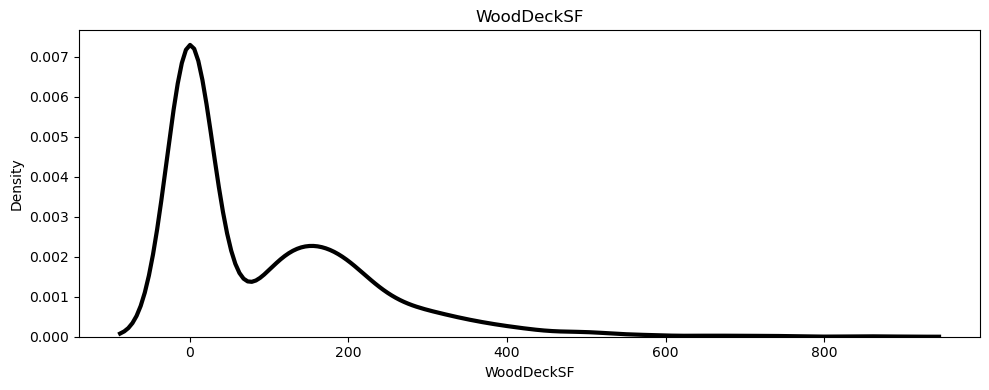

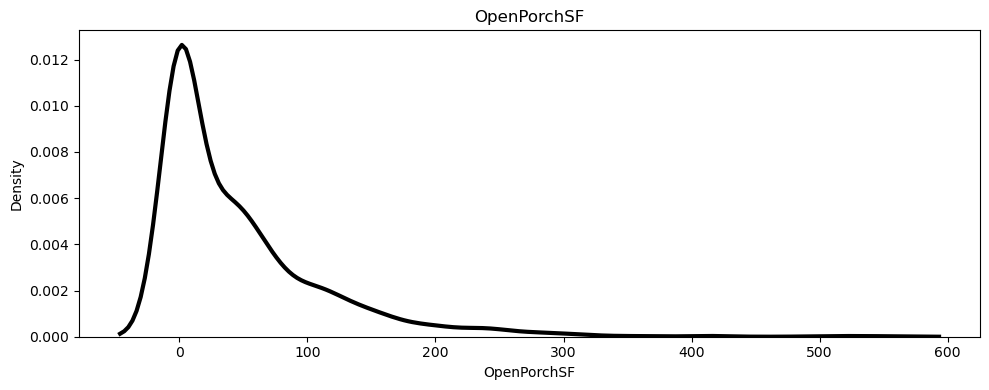

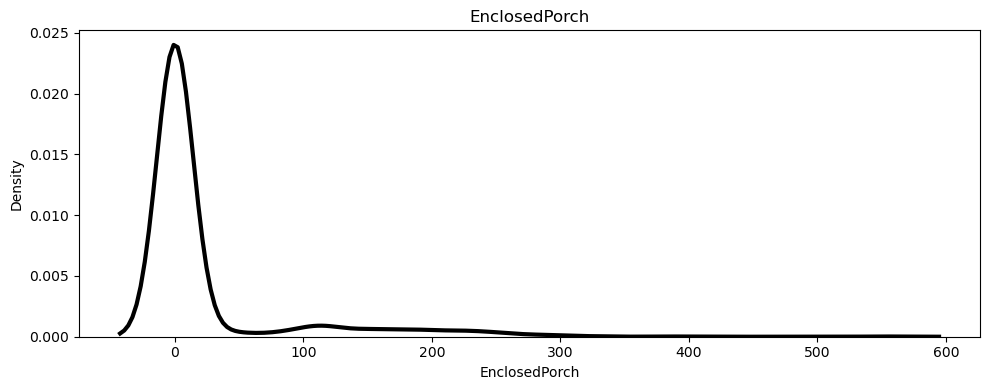

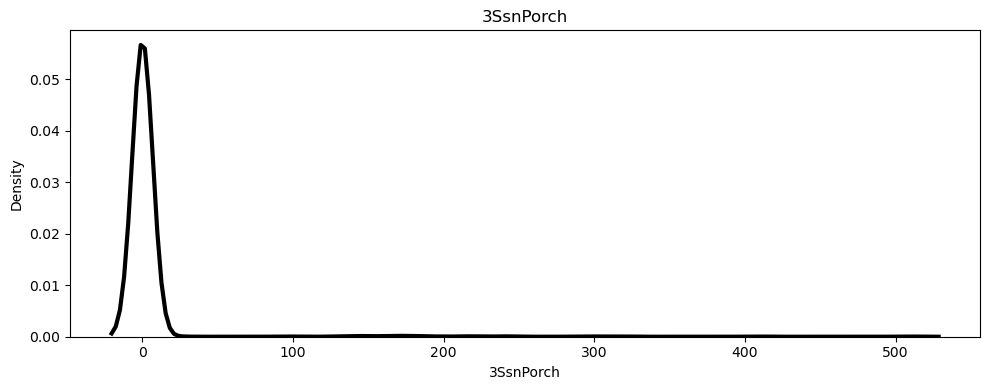

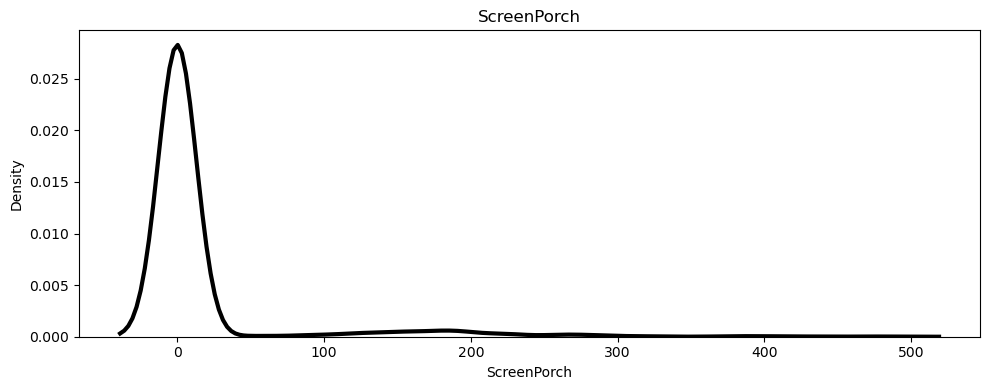

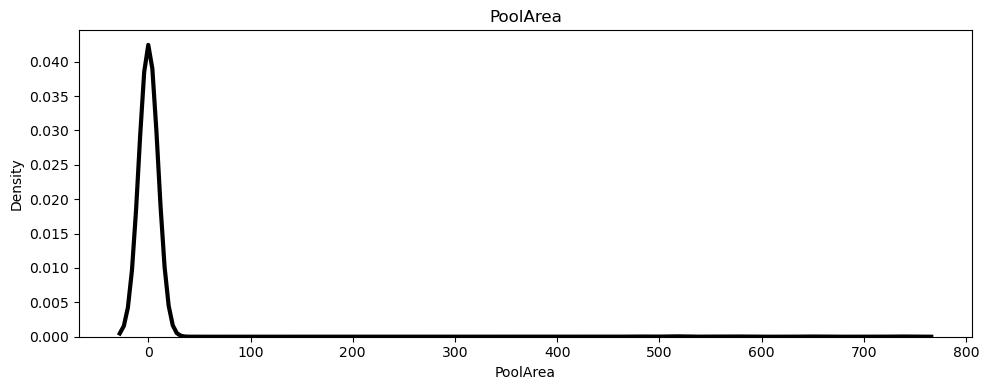

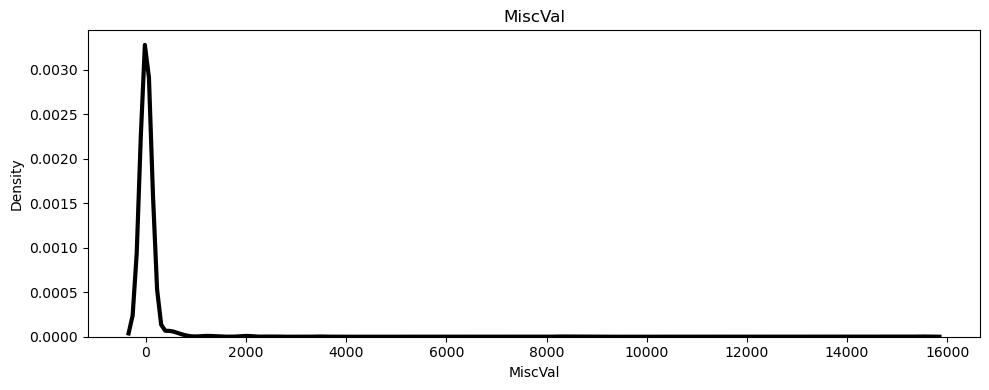

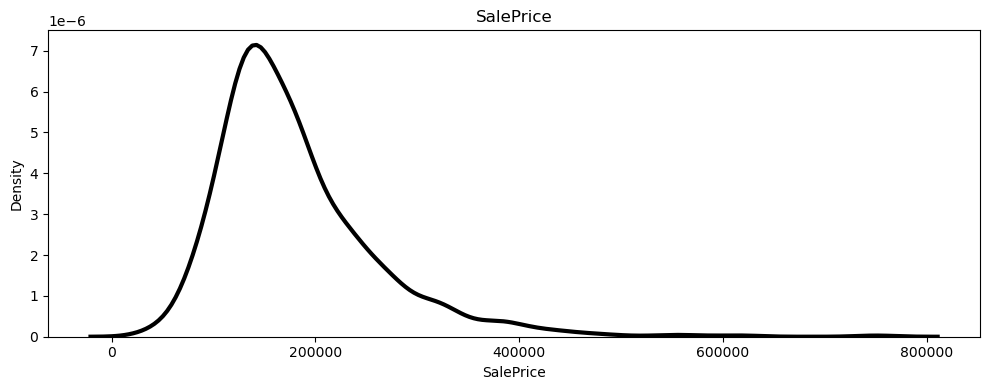

In [139]:
for col in skew_cols:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.kdeplot(df[col], color = 'black', linewidth = 3, ax = ax)
    ax.set_title(col)
    plt.tight_layout()
    plt.show()

### A Closer Look at Our Target Feature *Sale Price*
A skewed feature can be transformed into a near-normal distributed, more bell-shaped curve using **Log Transformation**. `np.log1p` helps us achieve this. Why `log1p` and not just `log`?

`log1p` computes the value as:

log1p(x) = log(x + 1)

This helps us protect against 0 values in out data, since log(0) is undefined (negative infinity).
It converts log(0) to log(0 + 1) = log(1) = 0.

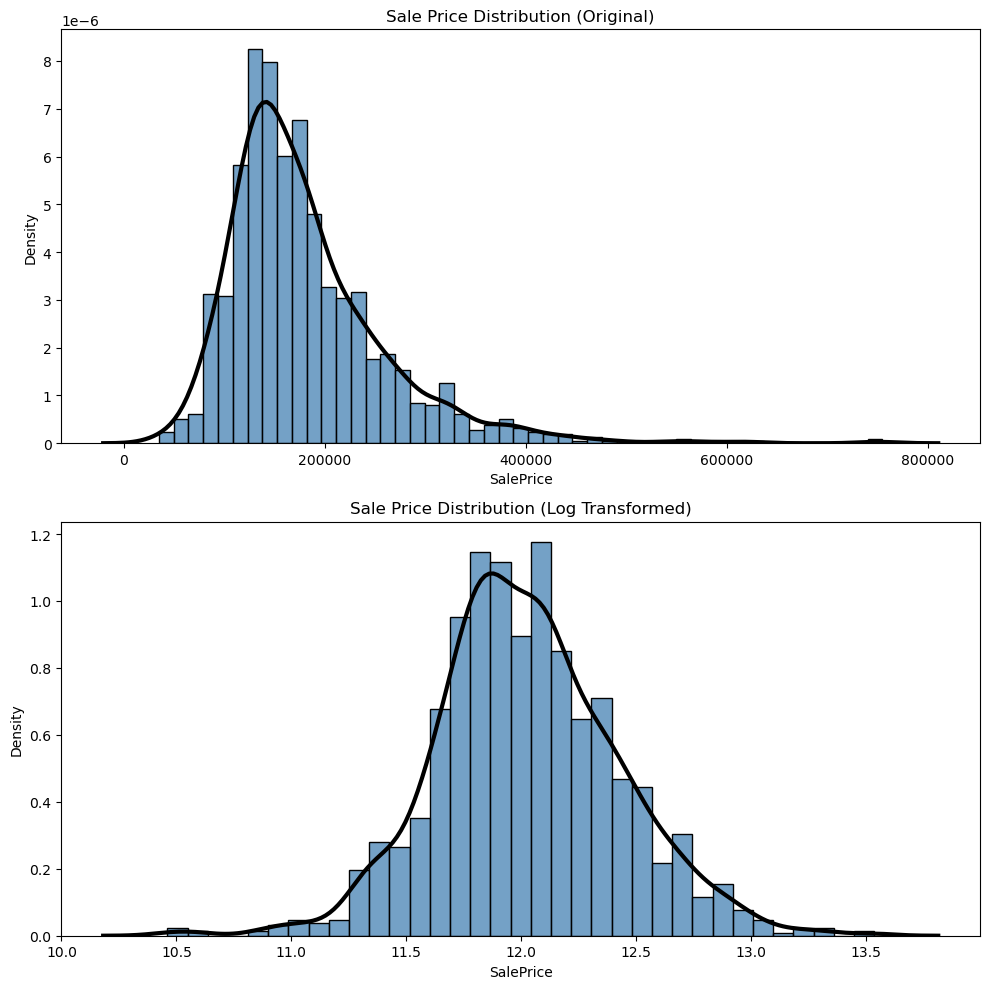

In [147]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
#Original
sns.histplot(df['SalePrice'], color = 'steelblue', stat = 'density', ax = axes[0])
sns.kdeplot(df['SalePrice'], color = 'black', linewidth = 3, ax = axes[0])
axes[0].set_title('Sale Price Distribution (Original)')
#Log Transformed
sns.histplot(np.log1p(df['SalePrice']), color = 'steelblue', stat = 'density', ax = axes[1])
sns.kdeplot(np.log1p(df['SalePrice']), color = 'black', linewidth = 3, ax = axes[1])
axes[1].set_title('Sale Price Distribution (Log Transformed)')
plt.tight_layout()
plt.savefig('../plots/SalePrice Log Transform.png')
plt.show()

### Correlation Matrix
It is a `n X n` matrix which gives the correlation value between a particular pair of features.

A correlation value is a numerical value which indicates relationship between the two features for which it is calculated, i.e how are those two features related with each other.

**Positive** value: The increment in one feature value is associated with the increment in the other feature value

**Negative** value: The increment in one feature value is associated with the decrement in the other feature value

The correlation values are calculated using the Pearson correlation method. It is calculated only for numerical features and captures mainly **linear relationships**. A feature with low Pearson correlation can still be useful if its relationship with SalePrice is **non-linear** or if it is **categorical/ordinal** in nature.

| Correlation Value | Strength |
|---|---|
| ±0.7 to ±1.0 | Strong |
| ±0.4 to ±0.7 | Moderate |
| ±0.0 to ±0.4 | Weak |

Weak correlation does not necessarily mean a feature is useless, especially if the relationship is non-linear or interacts with other variables.

In [149]:
corr_matrix = df.corr(numeric_only = True)
#print(corr_matrix)

#run the print command to show the correlation values

In [58]:
corr_matrix['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

### Correlation Matrix Findings
Calculated correlation scores between all numerical features and `SalePrice`.

Top positively correlated features:
- `OverallQual` — strongest predictor of price
- `GrLivArea` — above ground living area
- `GarageCars`, `GarageArea` — garage size

Top negatively correlated features:
- `EnclosedPorch`, `KitchenAbvGr` — slight negative correlation

These findings provide a useful starting point for feature selection, though final decisions should also consider non-linear relationships, categorical effects, and model performance.

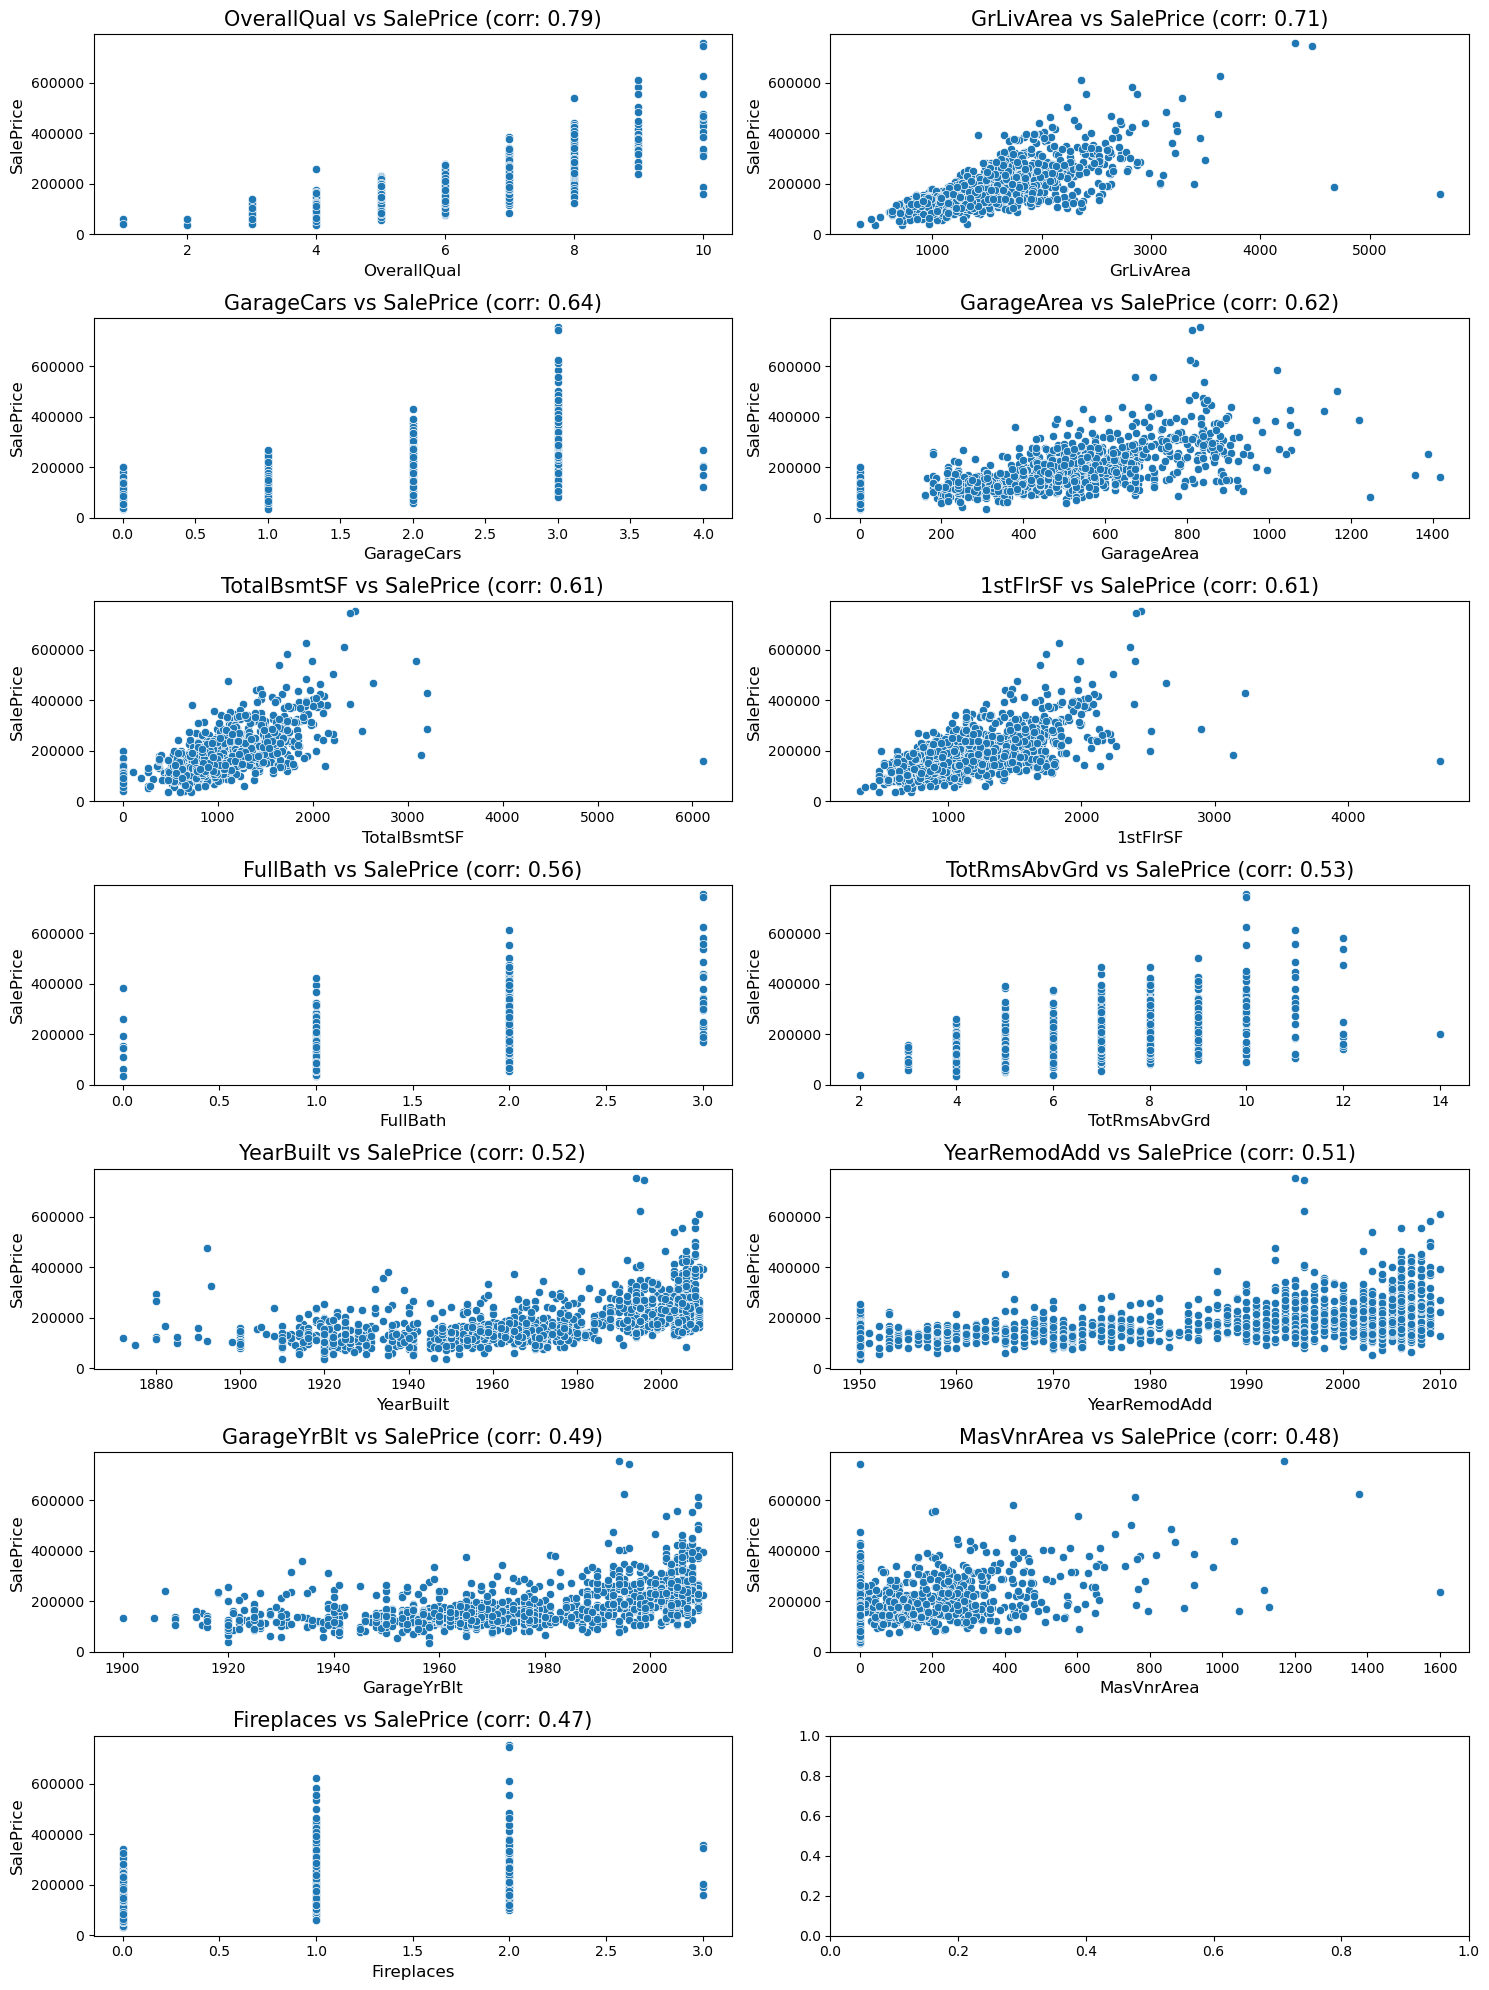

In [77]:
# Get top correlated features with SalePrice (excluding SalePrice itself)
top_corr = corr_matrix['SalePrice'].drop('SalePrice').sort_values(ascending=False)

# Pick top N features
top_features = top_corr[abs(top_corr) > 0.4].index

n = len(top_features)
rows = (n + 1) // 2

fig, axes = plt.subplots(rows, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.scatterplot(x=df[col], y=df['SalePrice'], ax=axes[i])
    axes[i].set_title(f'{col} vs SalePrice (corr: {top_corr[col]:.2f})', size = 15)
    axes[i].set_xlabel(col, size = 12)
    axes[i].set_ylabel('SalePrice', size = 12)
    plt.tight_layout()
plt.savefig('../plots/scatter_plots.png')
plt.show()

### Scatter Plots — Top Correlated Features vs SalePrice
Scatter plots generated for all features with absolute correlation > 0.4 with `SalePrice`,
arranged in descending order of correlation strength.

Key observations:
- `OverallQual` shows a clear positive relationship with `SalePrice`
- `GrLivArea` shows a strong linear relationship with a few high-value outliers visible
- `GarageCars` and `GarageArea` appear highly related and may contain overlapping information, making them candidates for multicollinearity checks.
- Some plots reveal outlier pairs that could affect model performance

These features appear promising and are good candidates to prioritize during model building, subject to further validation.


**Additional Observation:**
Several features in the scatter plots reveal discrete vertical bands rather 
than continuous distributions — `OverallQual`, `GarageCars`, `FullBath`, 
`TotRmsAbvGrd` and `Fireplaces` are ordinal/discrete in nature despite being stored as integers.
These will be treated accordingly during preprocessing.

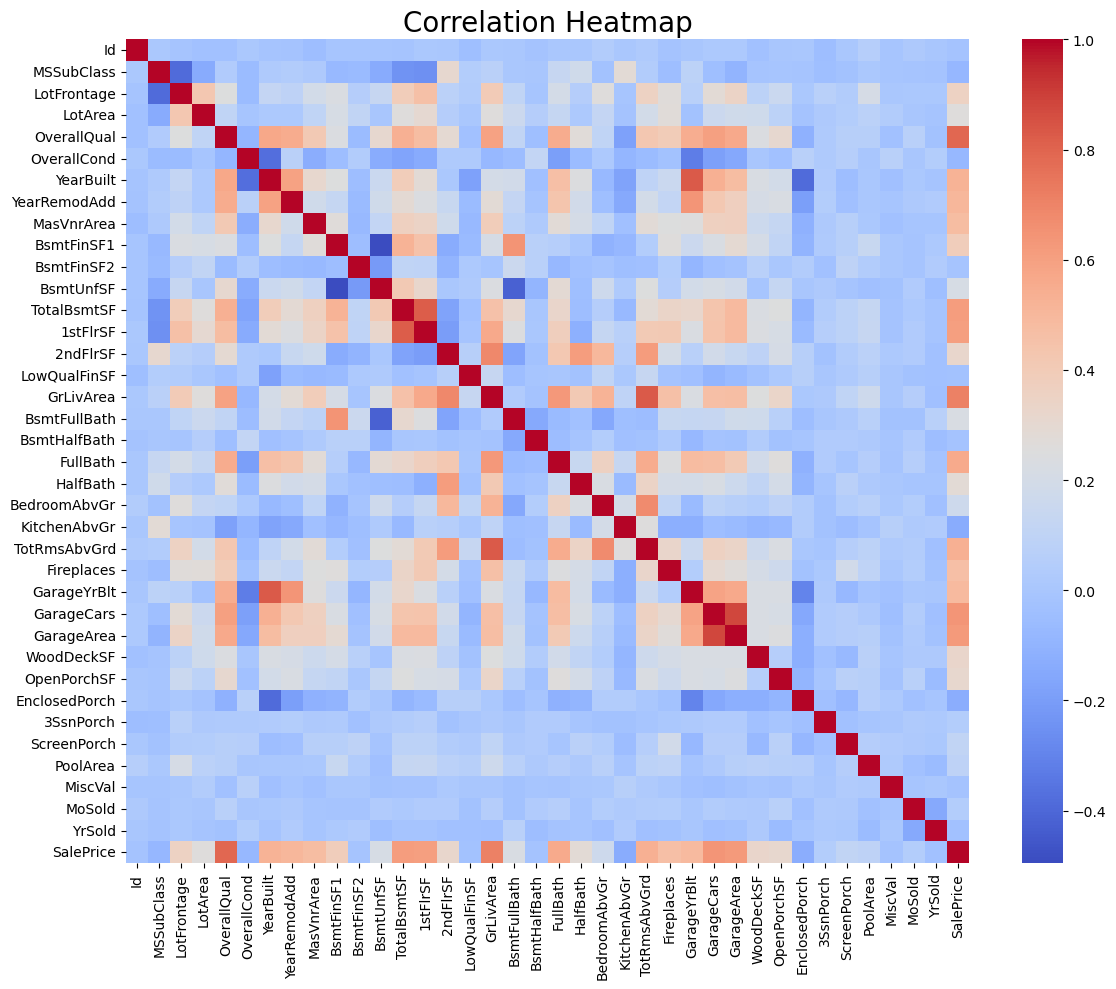

In [141]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap', size = 20)
plt.tight_layout()
plt.savefig('../plots/correlation_heatmap.png')
plt.show()

### Correlation Heatmap
Visual representation of the correlation matrix across all numerical features.
Red cells indicate positive correlation, blue indicates negative correlation,
and white indicates little to no correlation.

`OverallQual` and `GrLivArea` visibly stand out as the strongest predictors
of `SalePrice`. Highly correlated numerical feature pairs, such as GarageArea and GarageCars, may indicate multicollinearity and should be reviewed during feature selection.

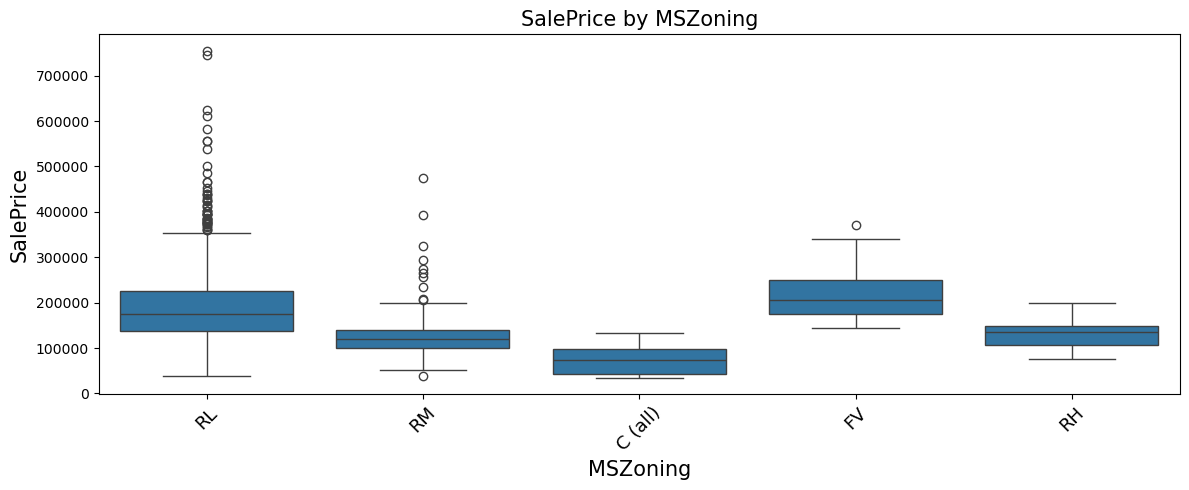

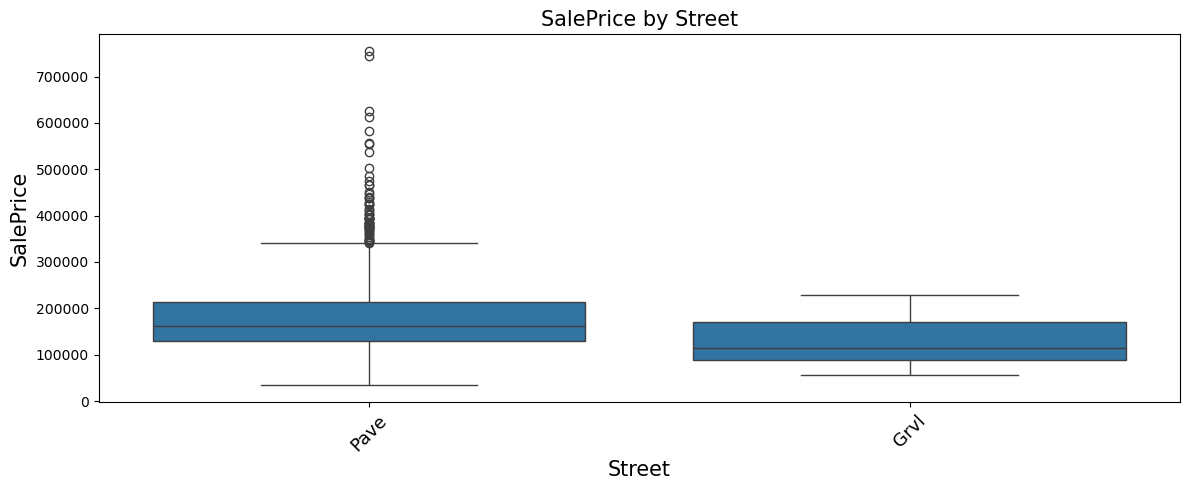

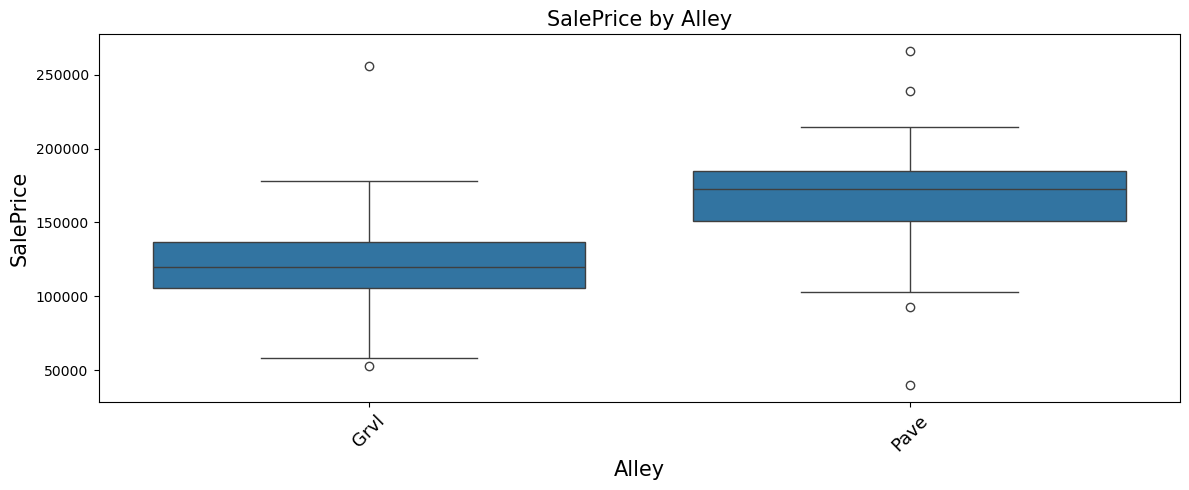

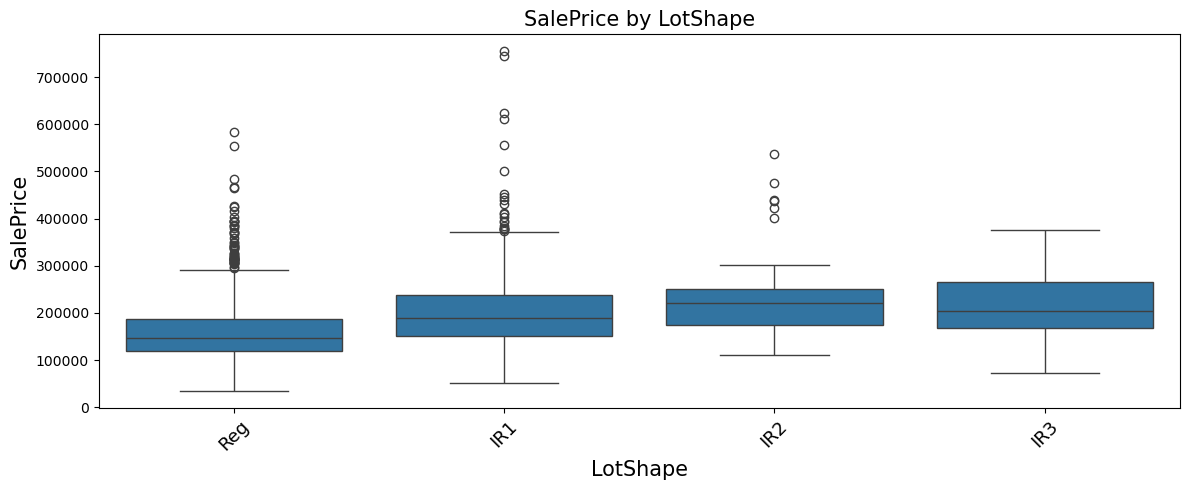

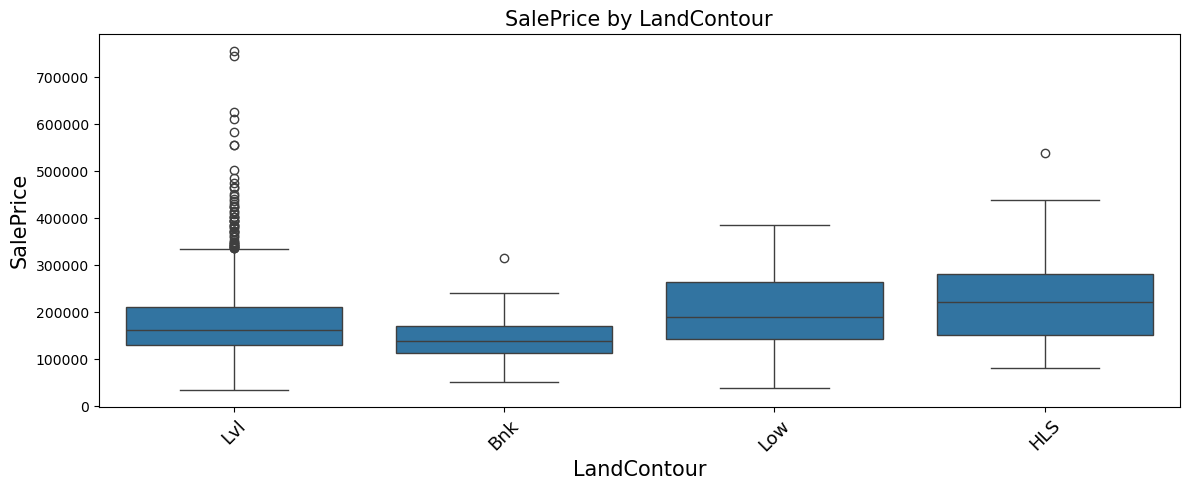

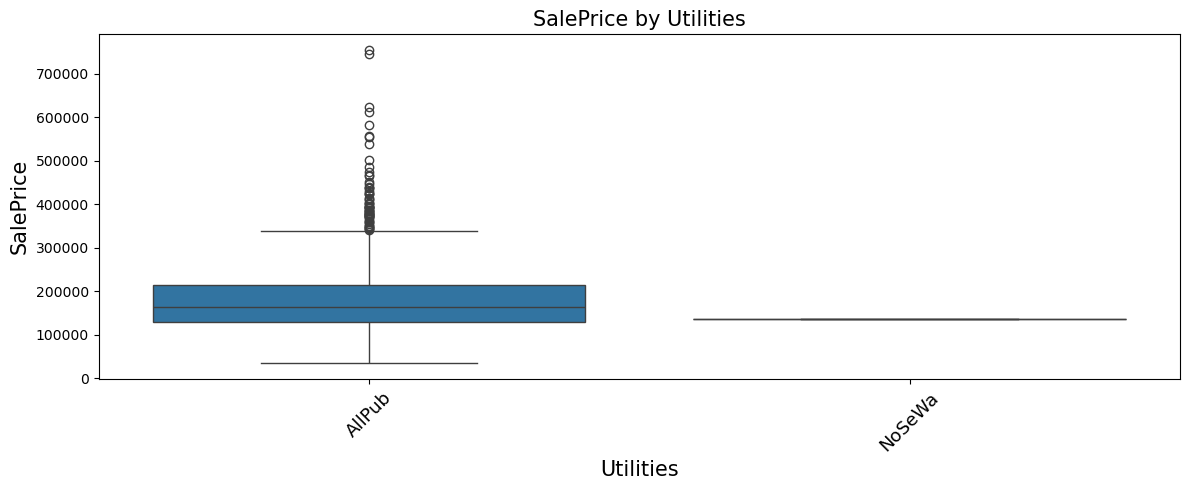

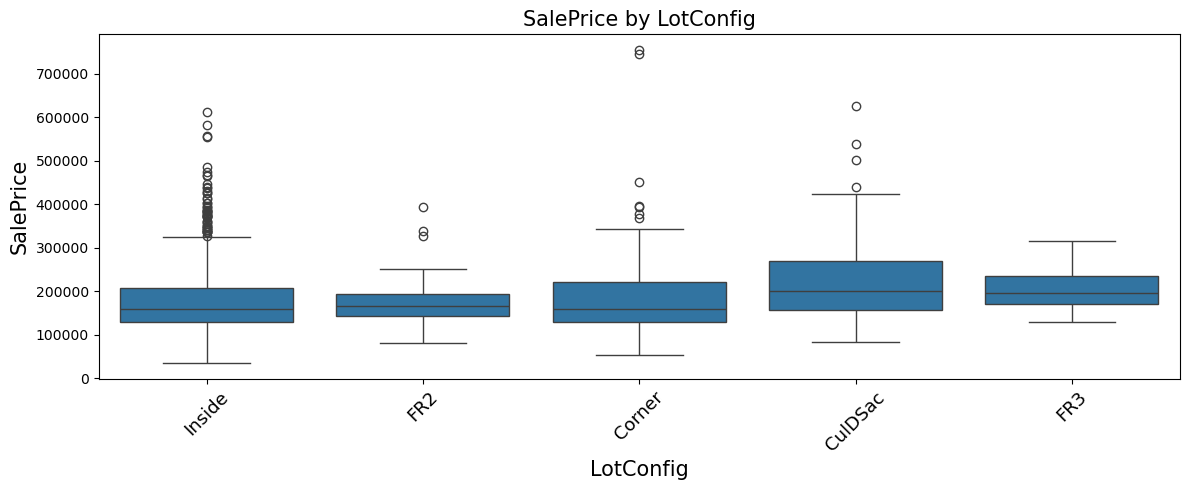

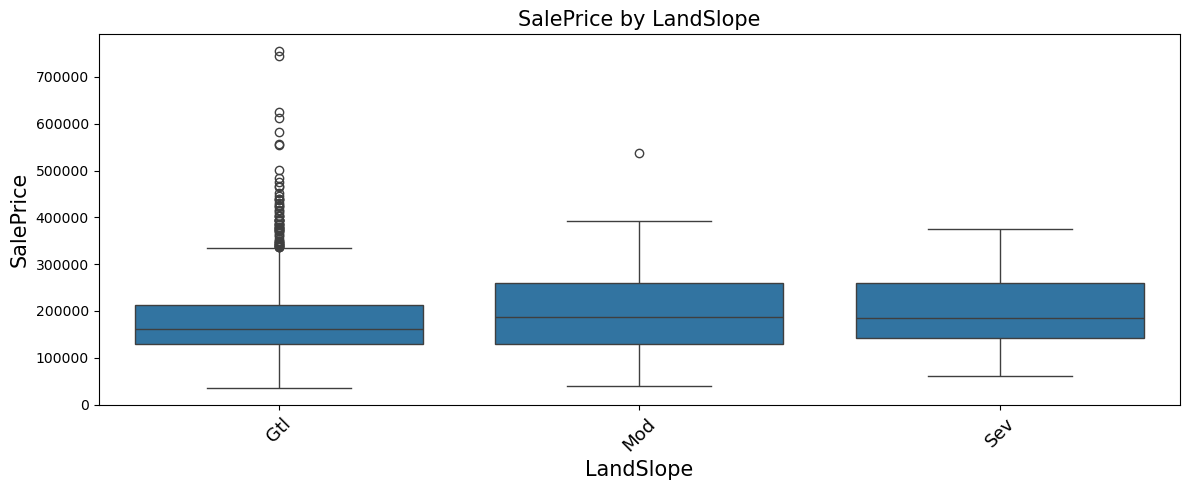

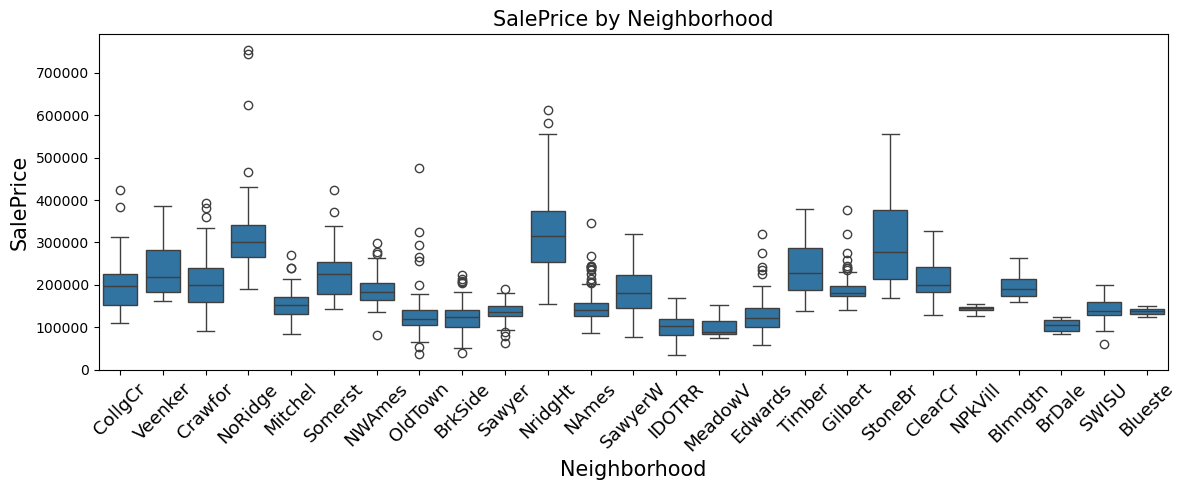

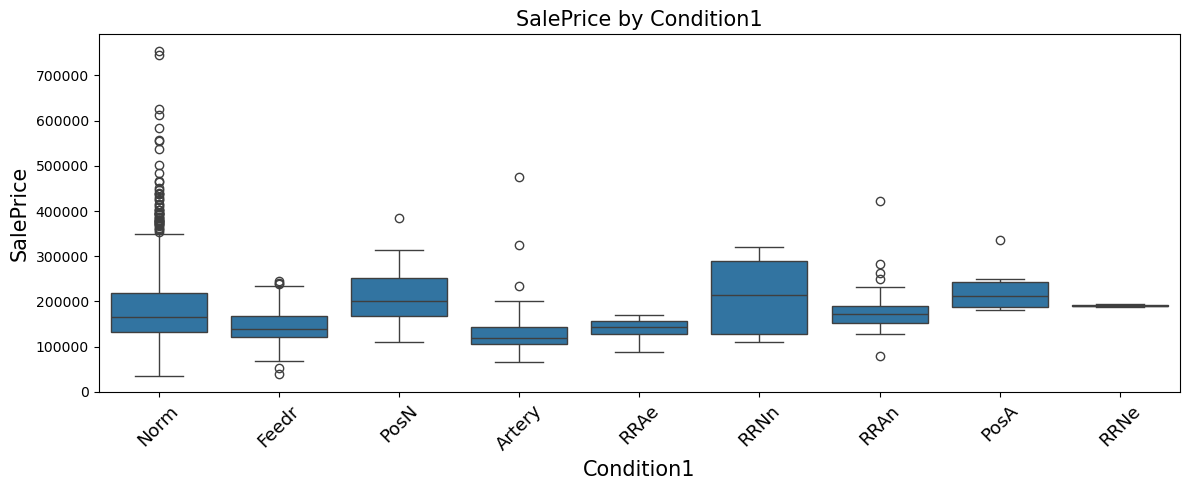

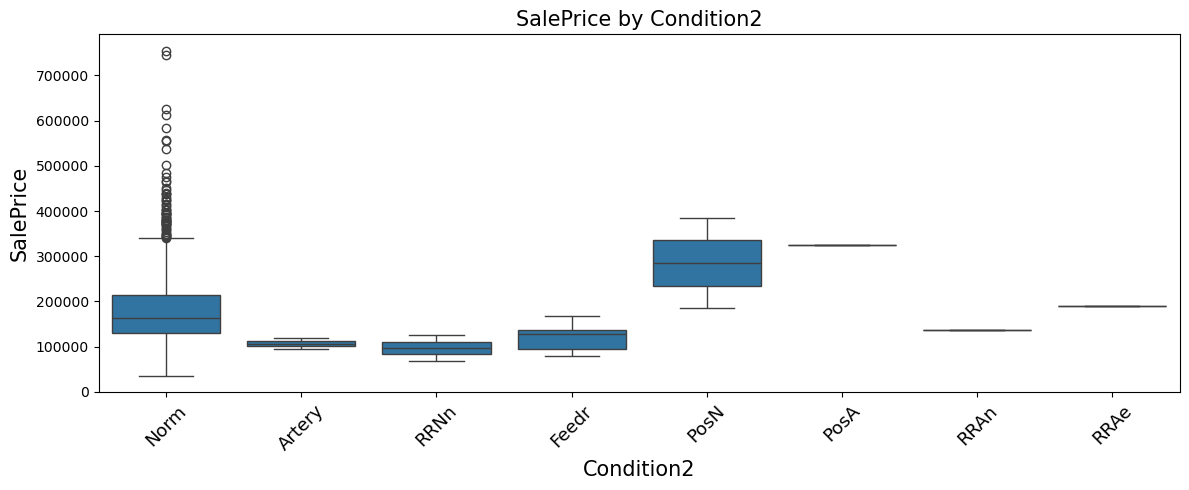

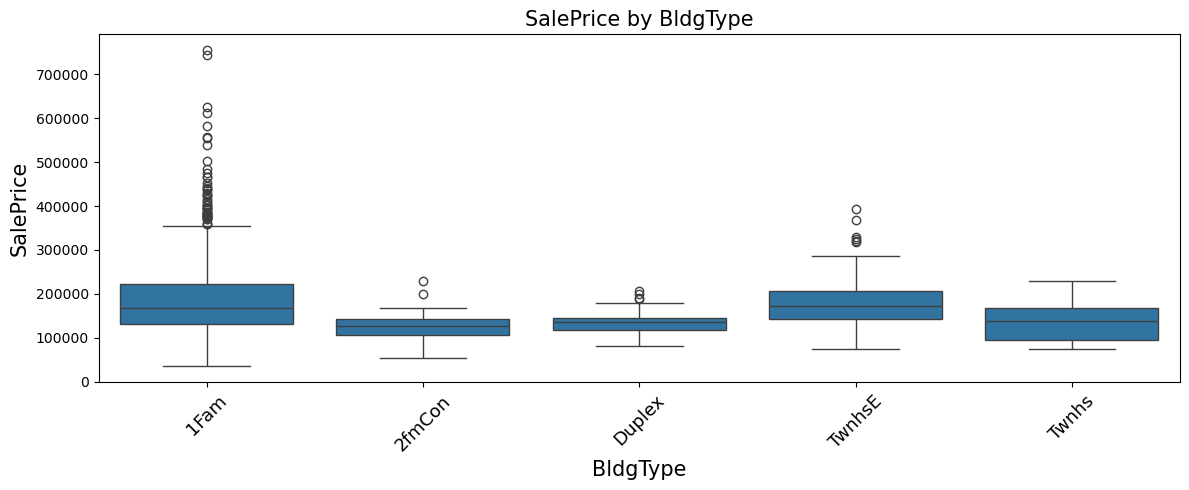

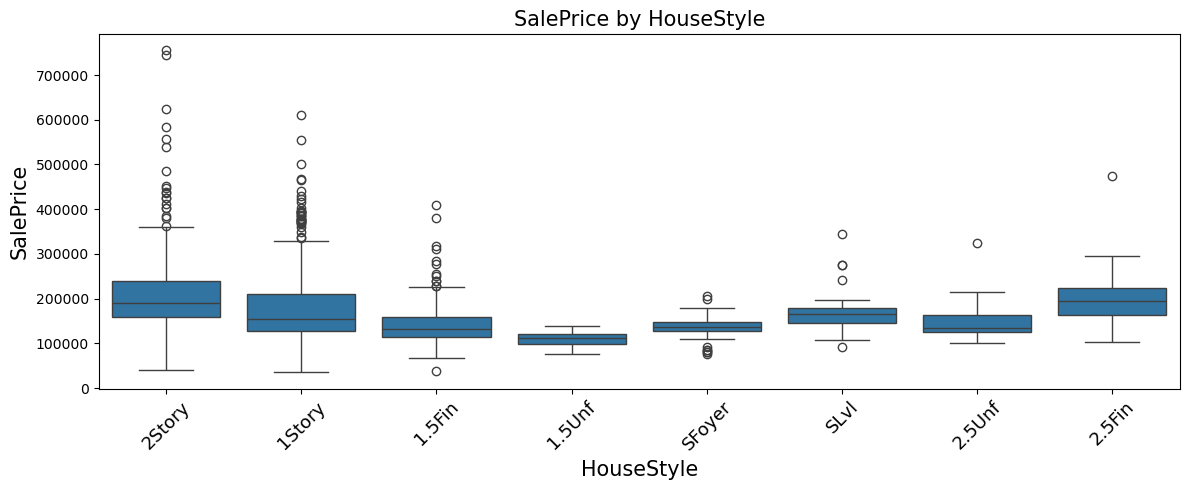

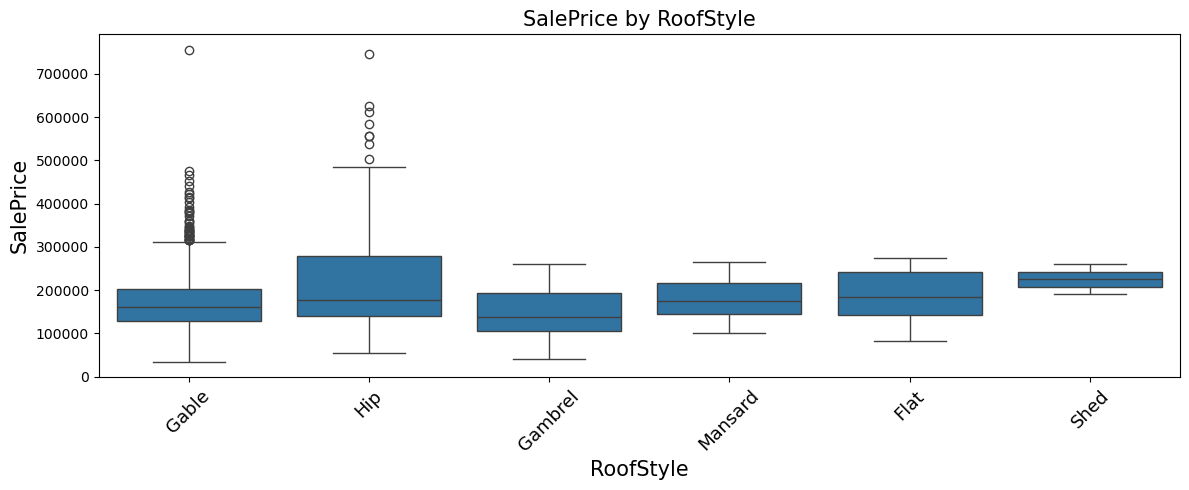

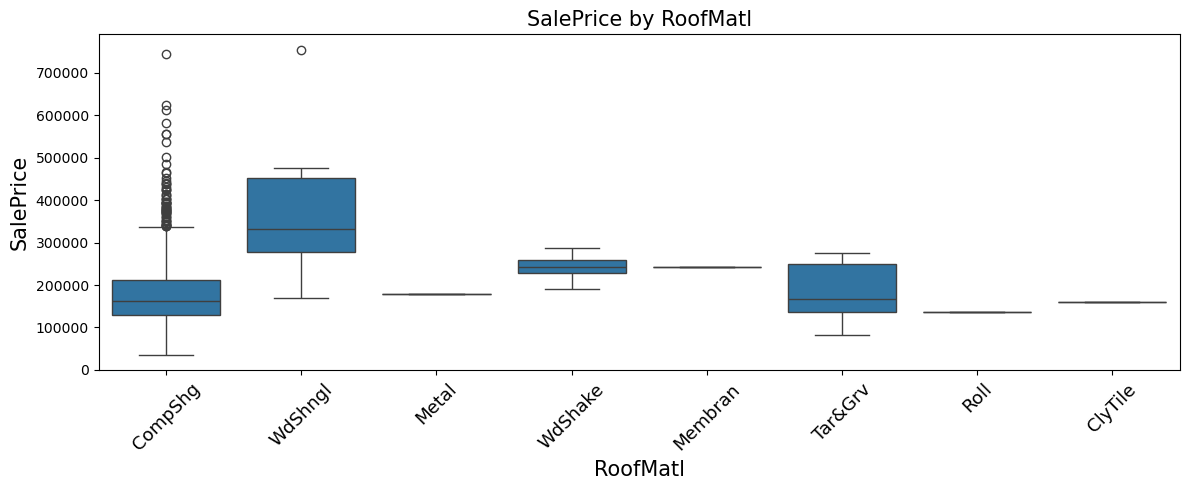

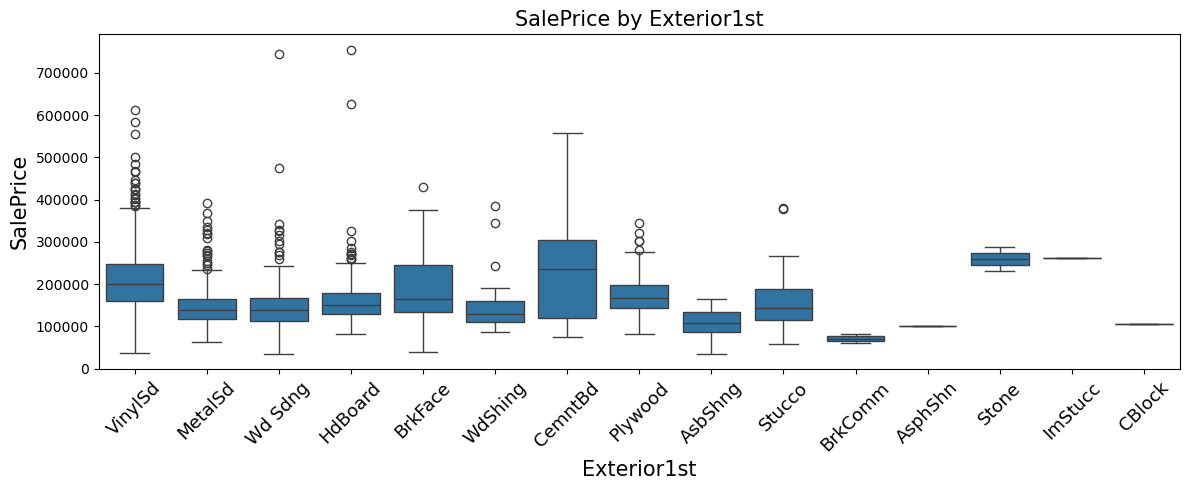

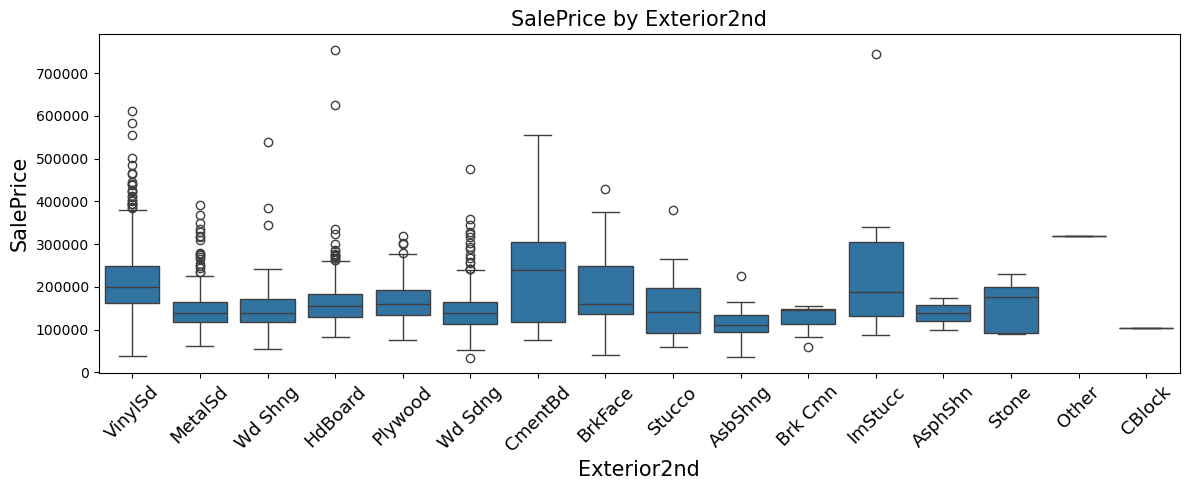

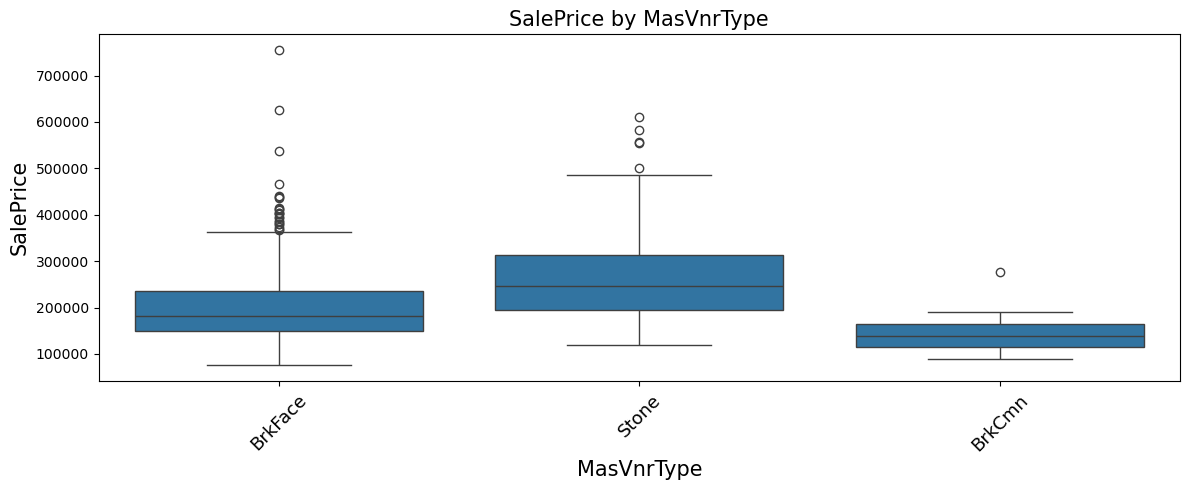

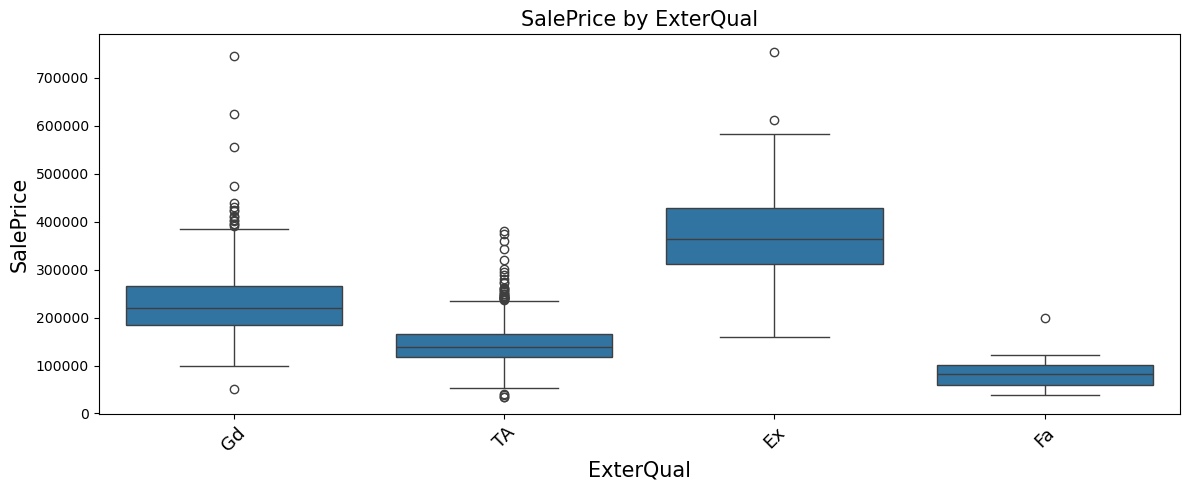

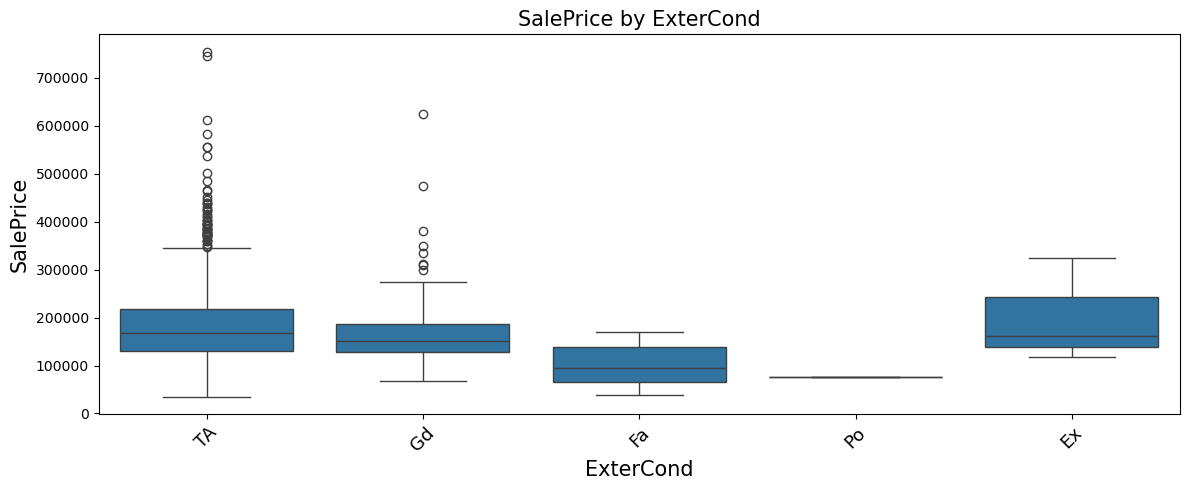

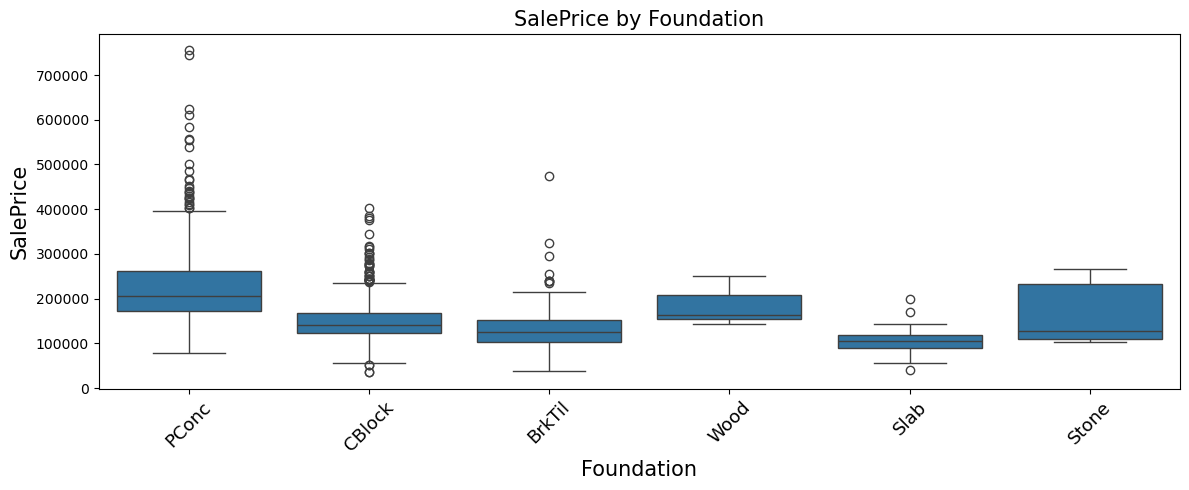

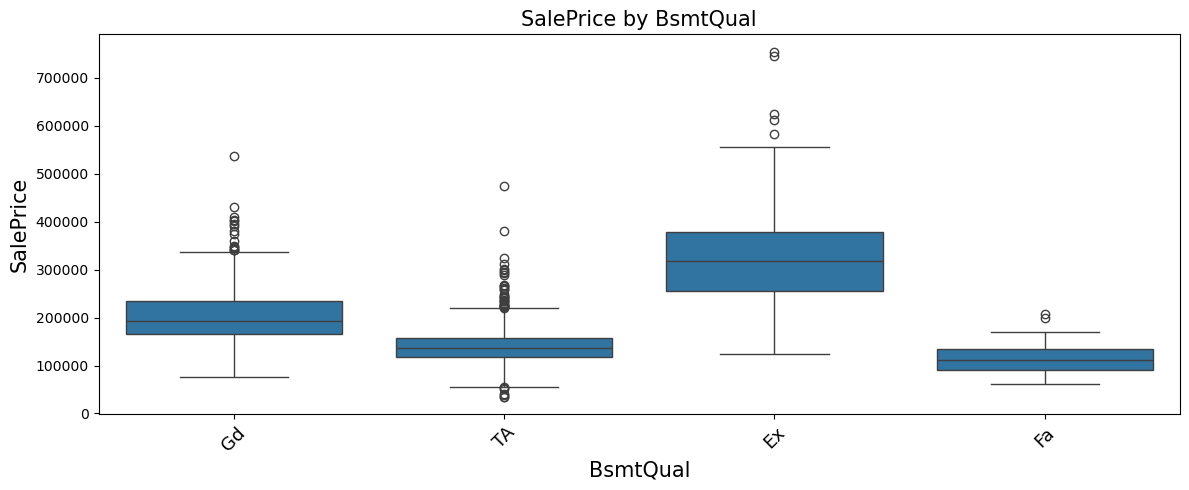

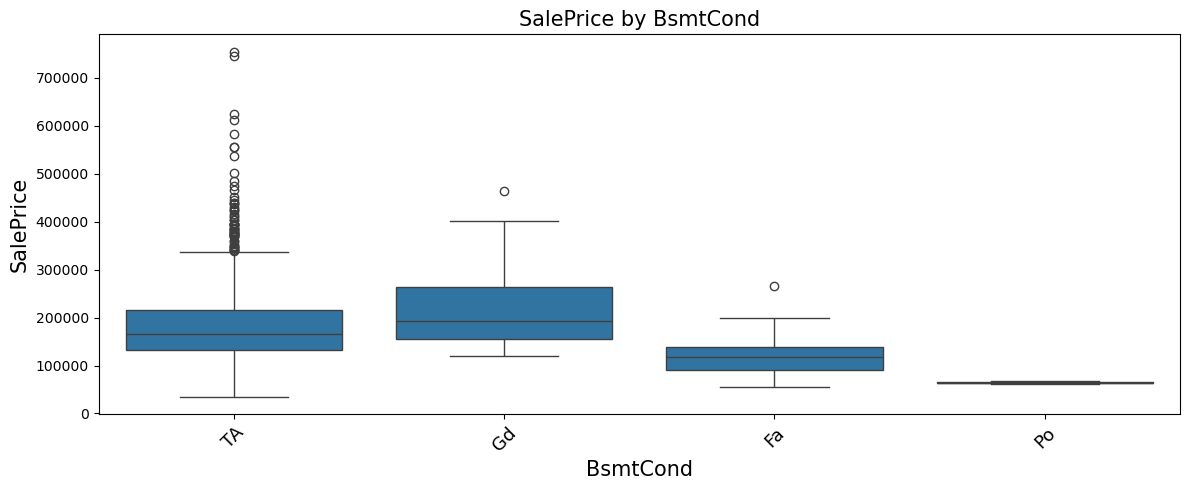

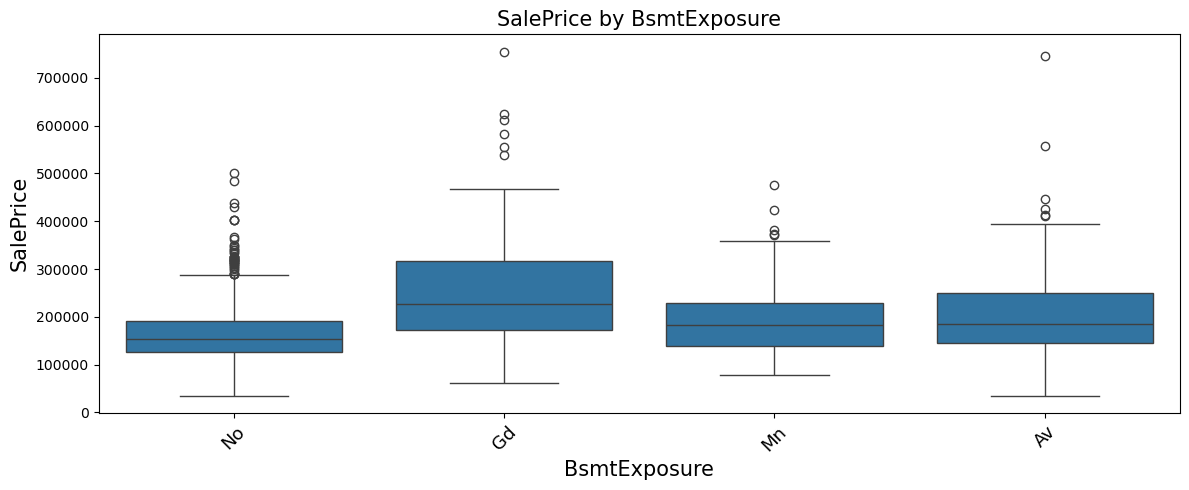

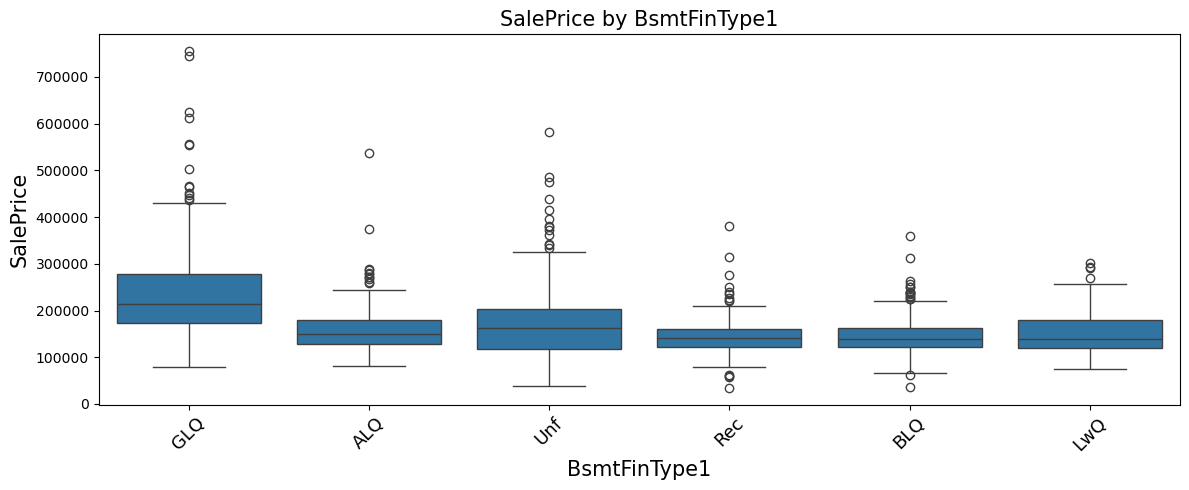

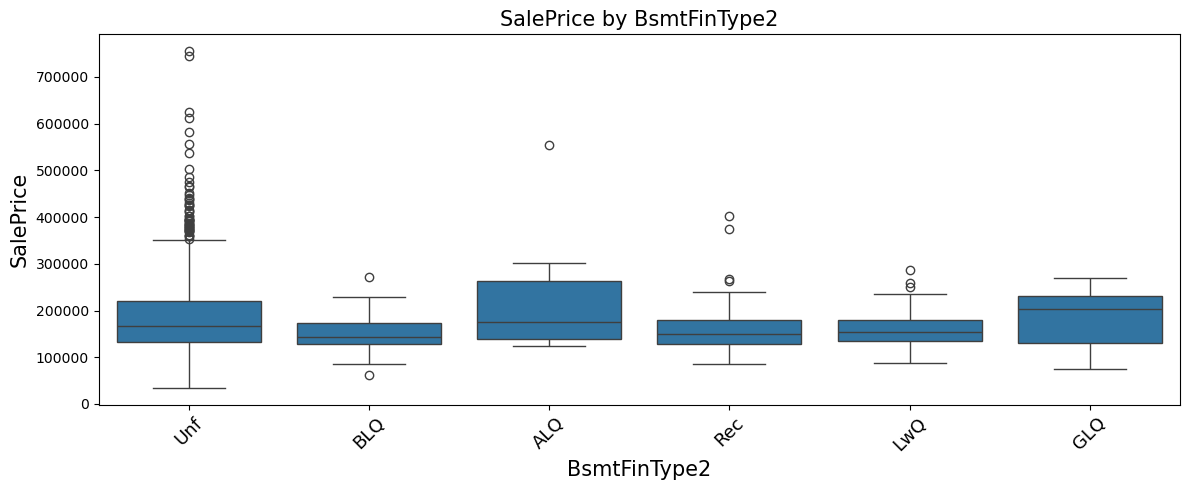

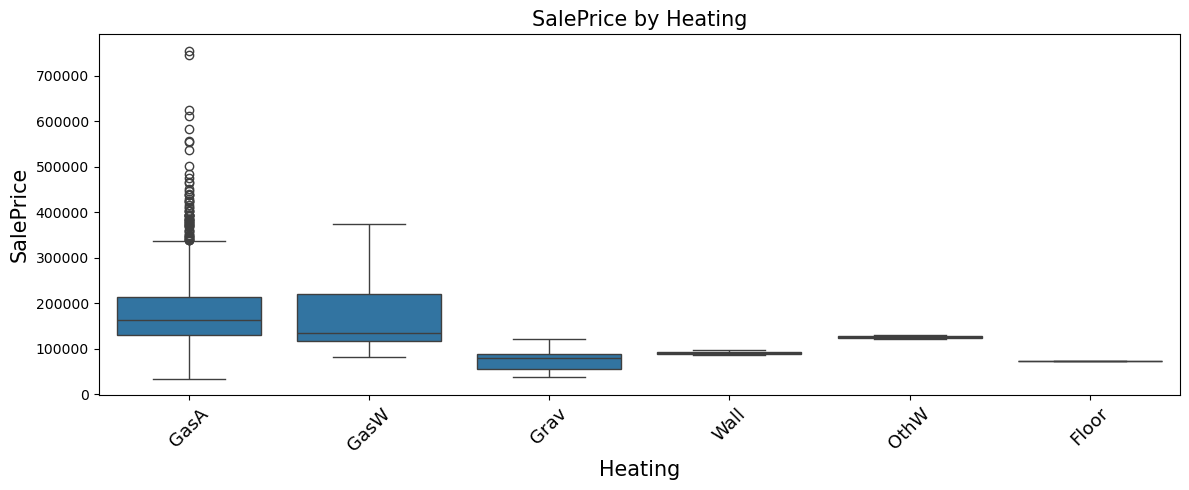

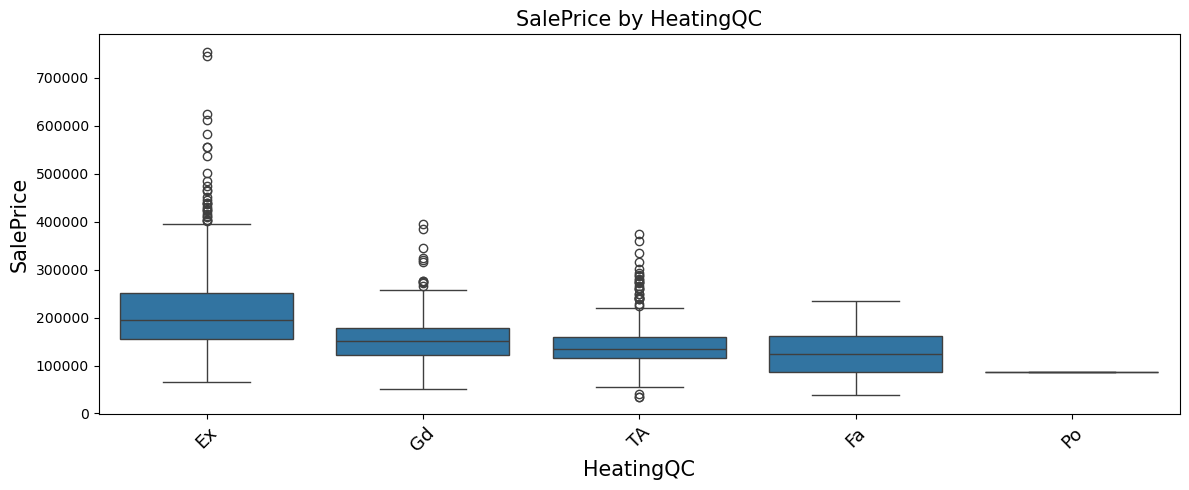

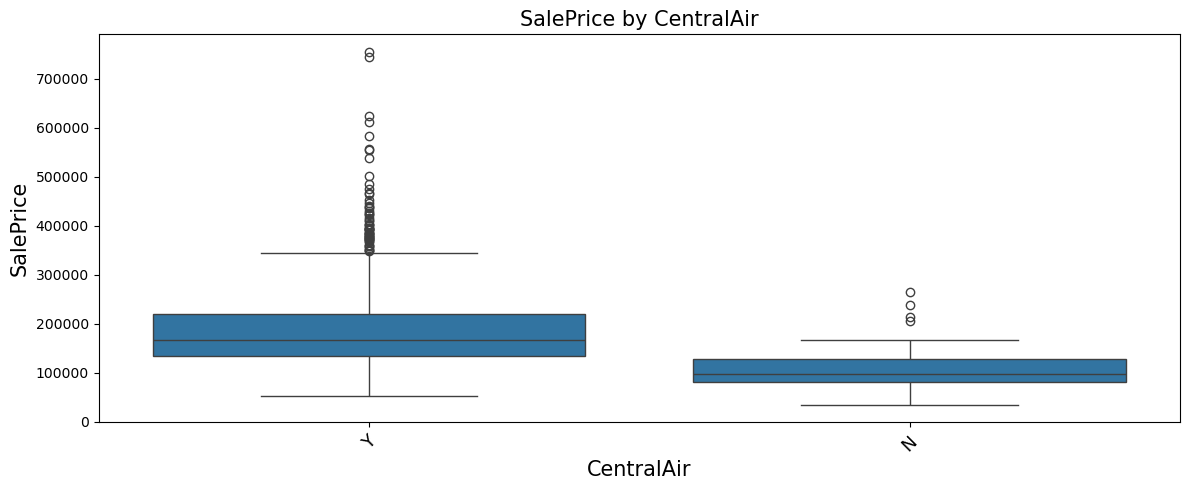

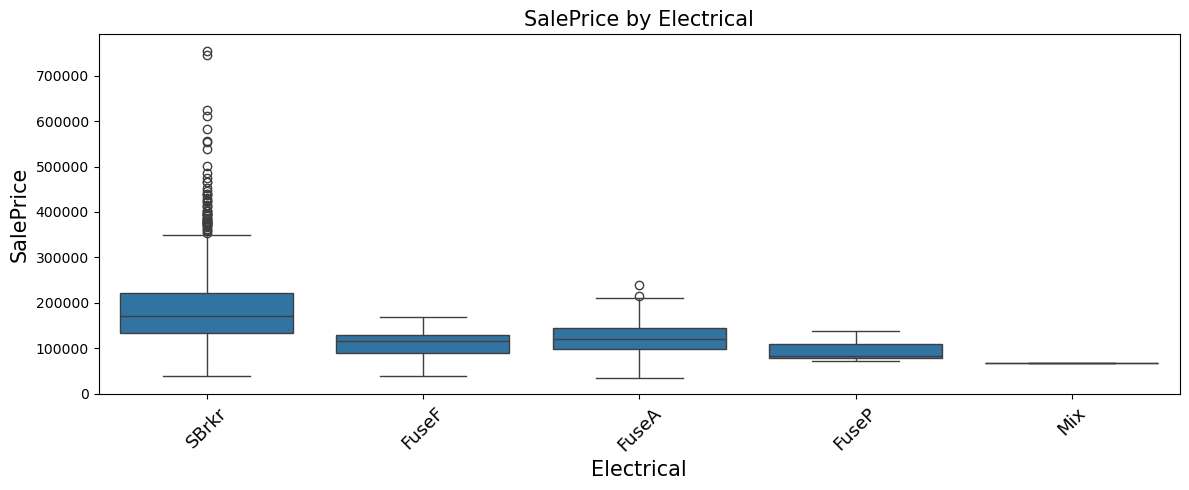

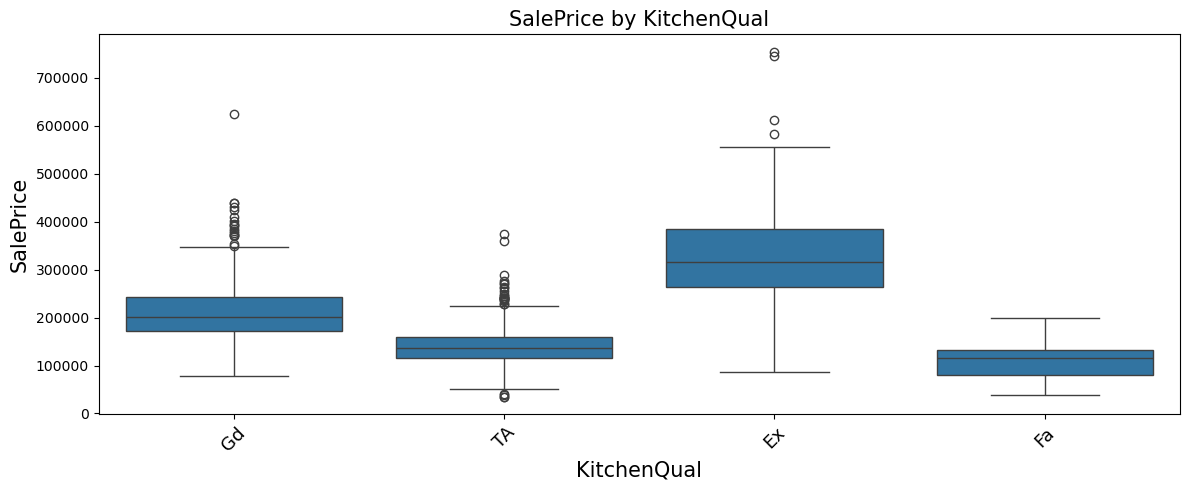

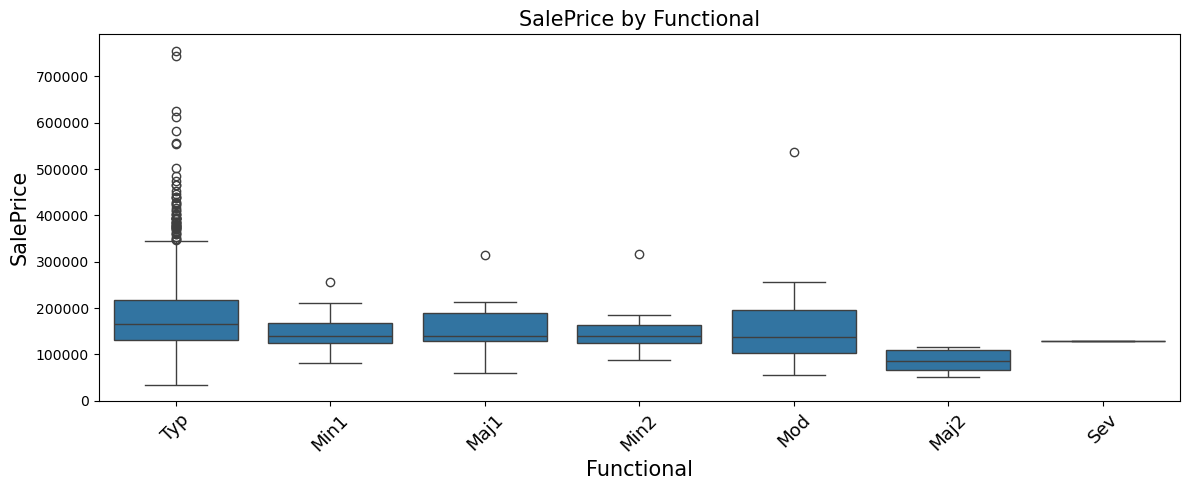

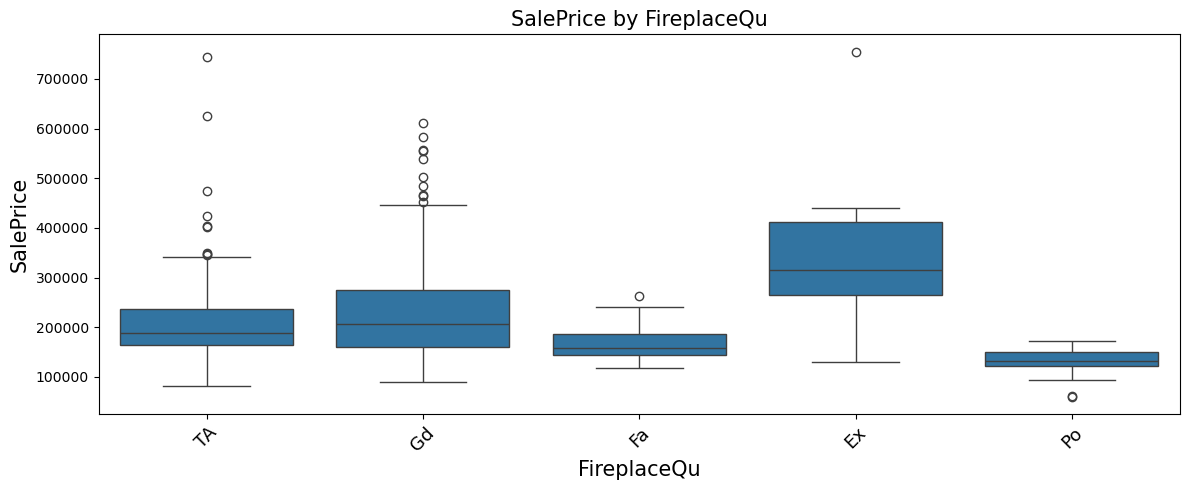

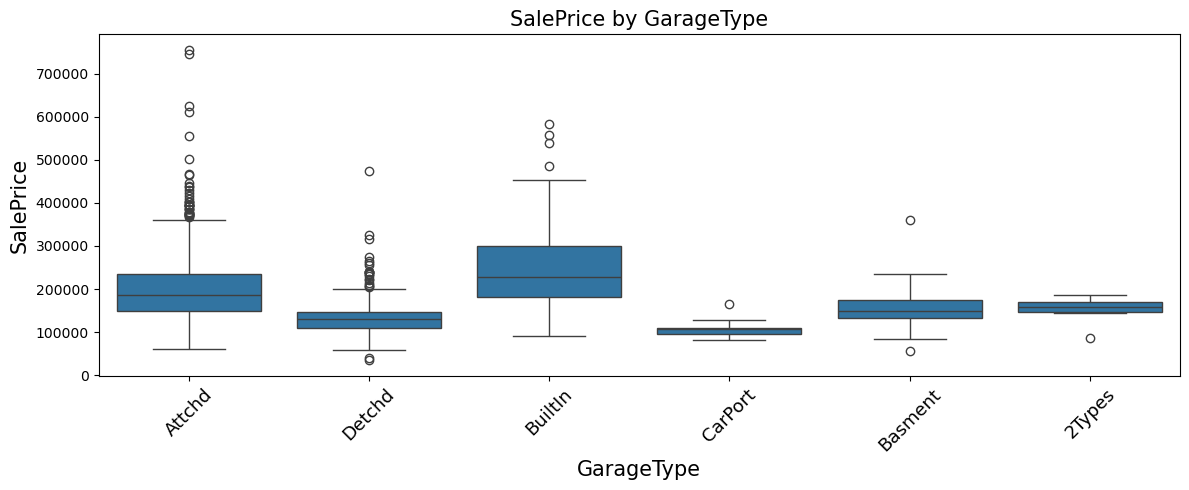

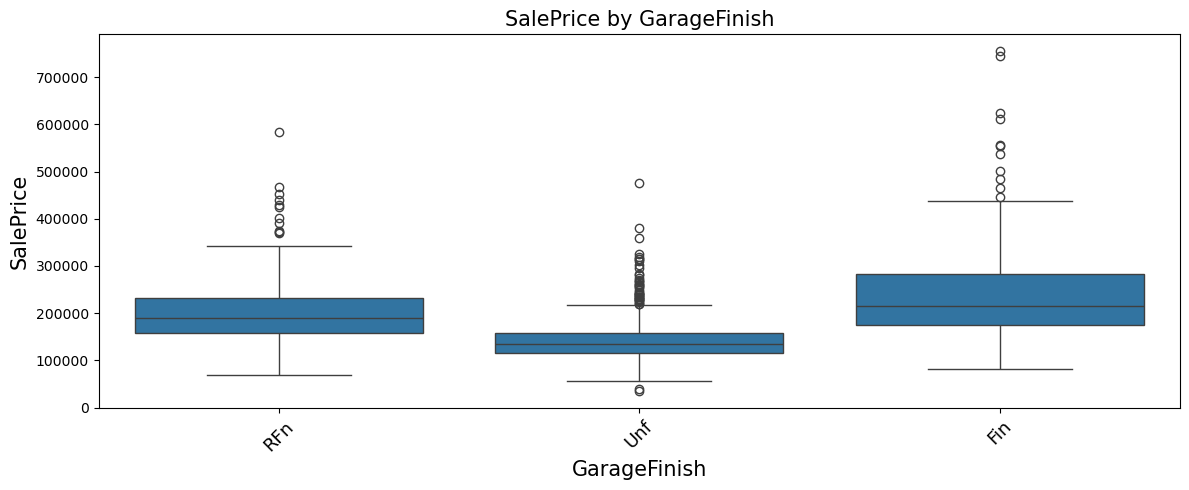

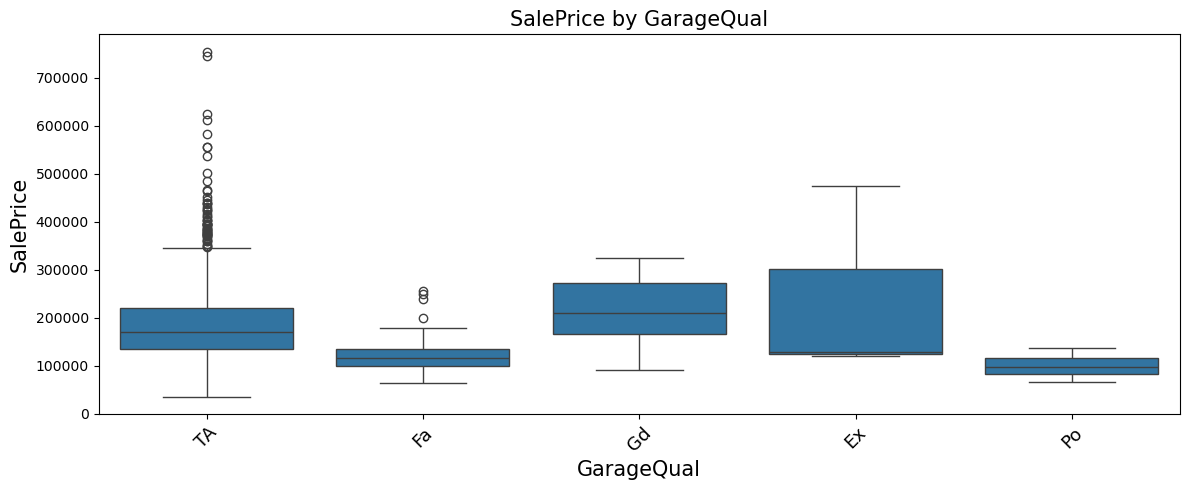

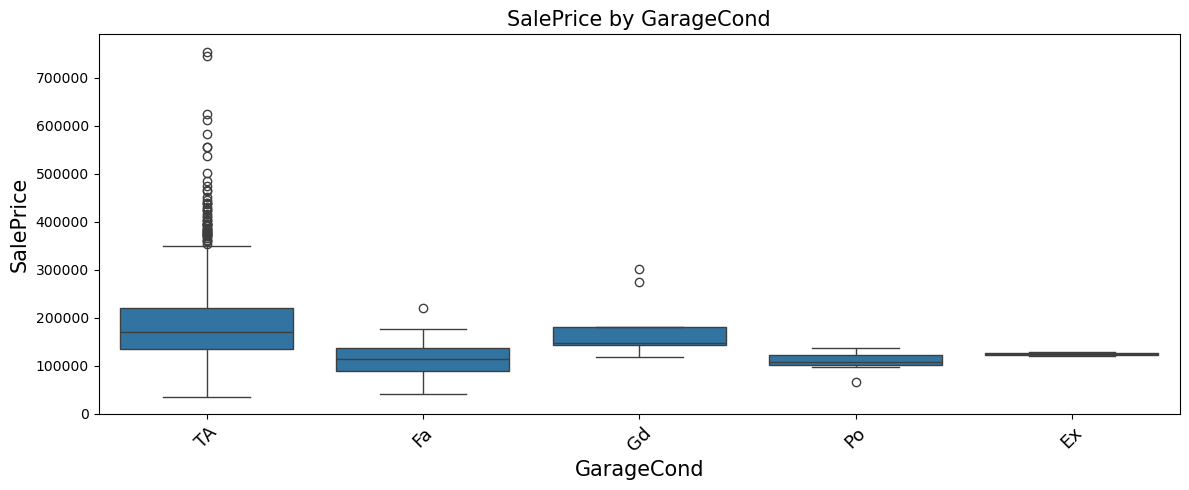

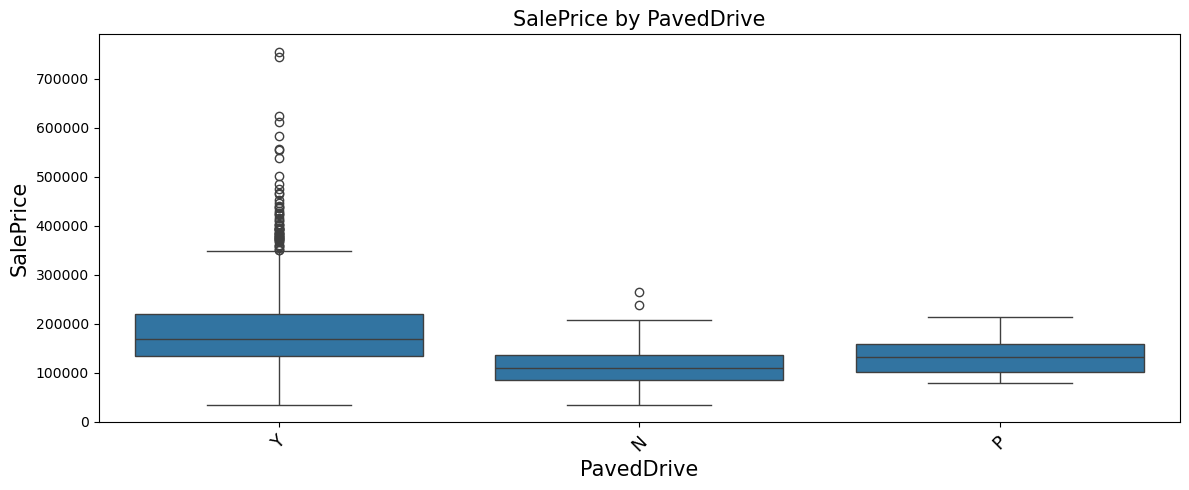

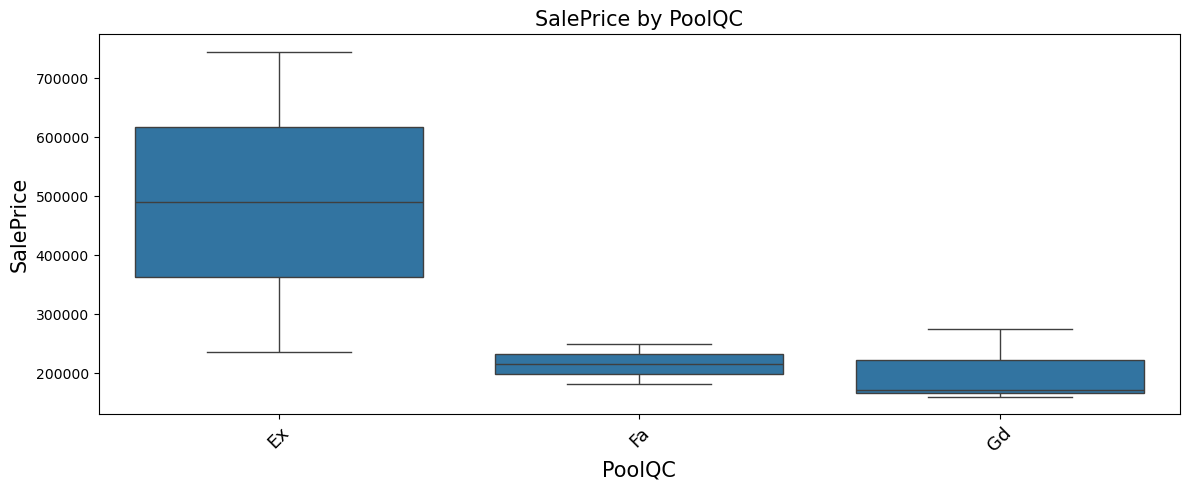

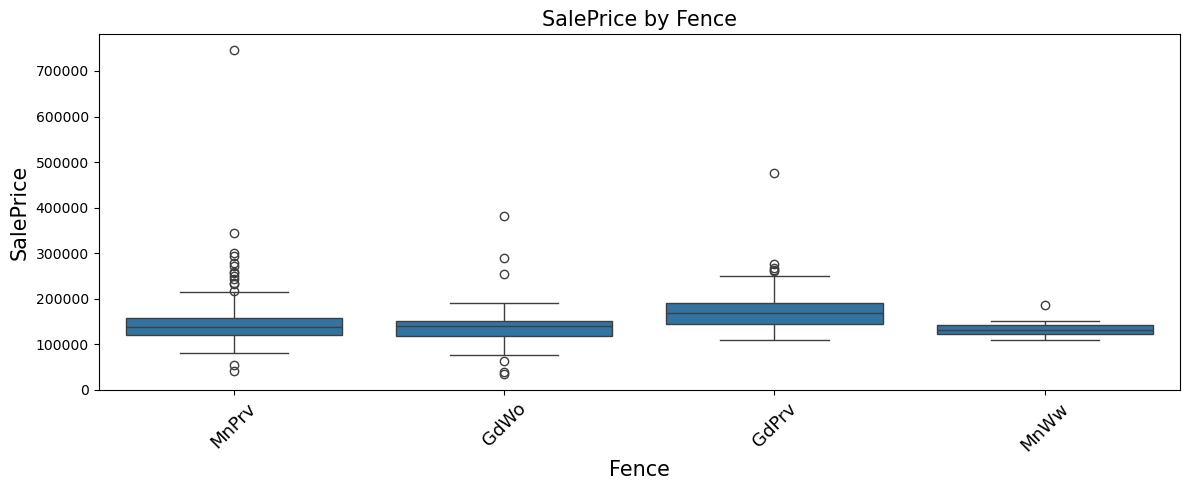

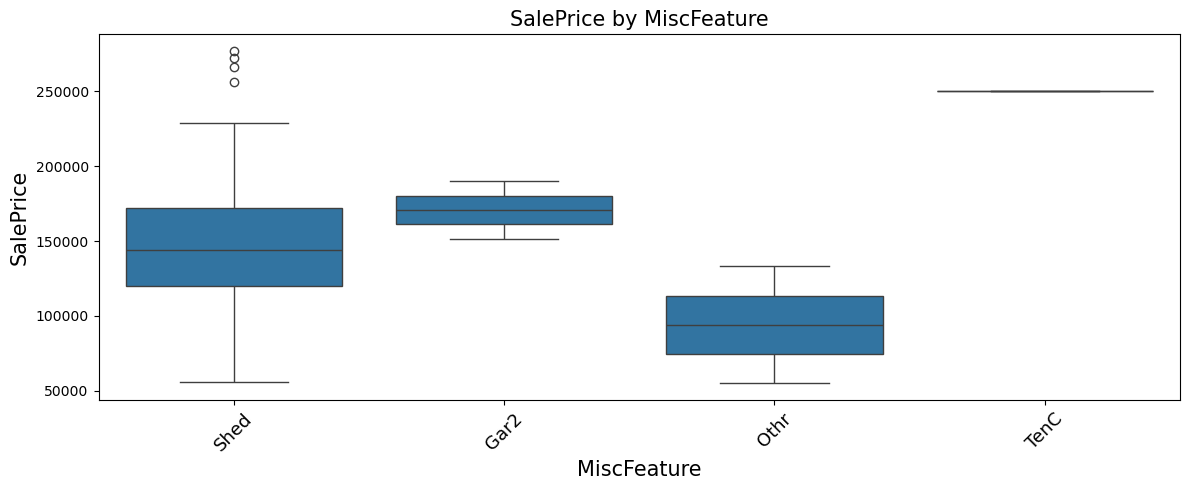

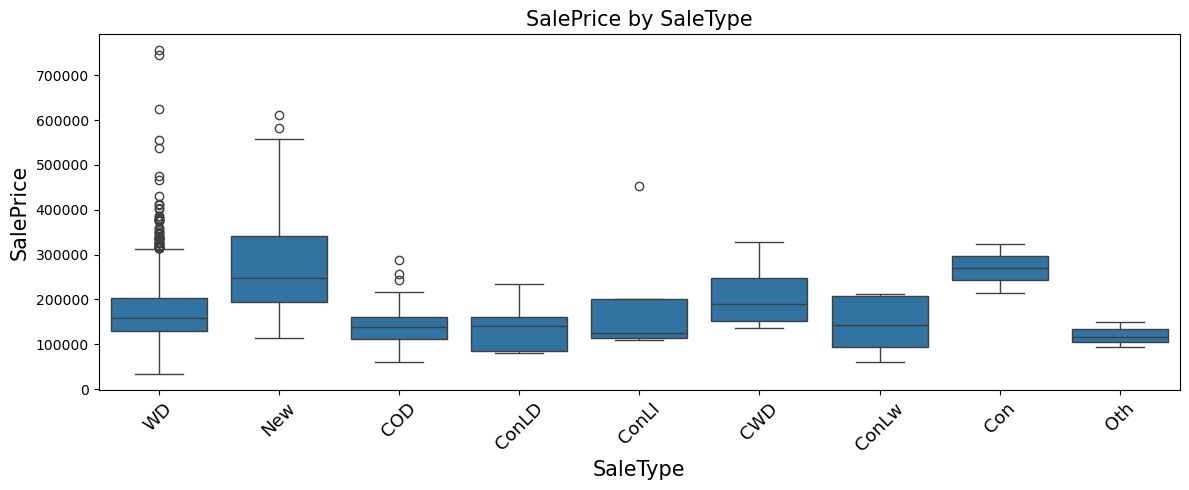

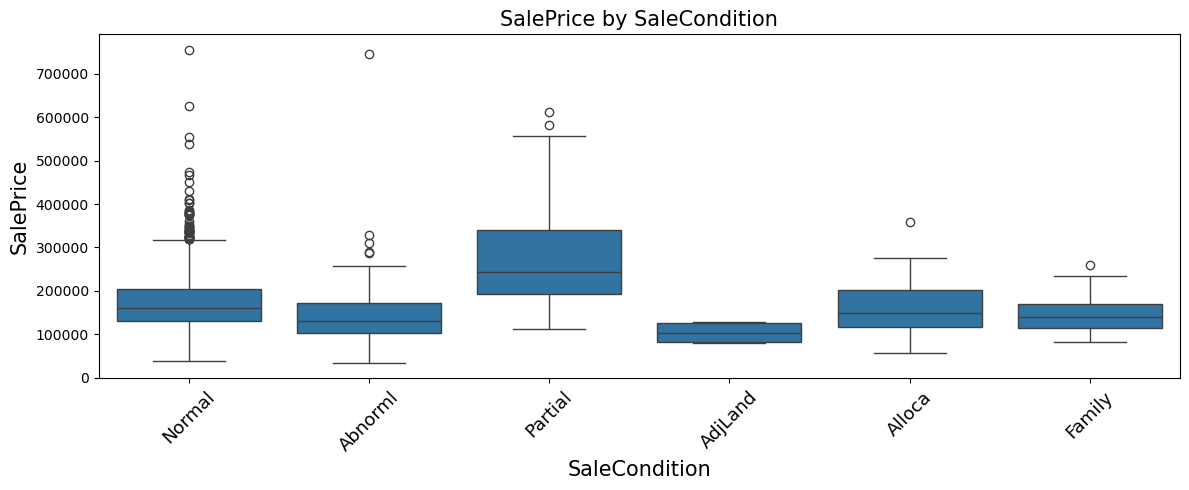

In [142]:
for col in cat_cols:
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(x=col, y='SalePrice', data=df, ax=ax)
    ax.set_title(f'SalePrice by {col}', size = 15)
    plt.xlabel(col, size = 15)
    plt.ylabel('SalePrice', size = 15)
    plt.xticks(rotation=45, size = 13)
    plt.tight_layout()
    plt.show()

### SalePrice vs Categorical Features — Grouped Boxplots
Boxplots generated for all categorical features showing how `SalePrice`
varies across each category.

Key observations:
- `Neighborhood` shows significant price variation — some areas command much higher prices
- `GarageType` and `BsmtQual` also show meaningful price differences across categories

Features showing little visual variation in `SalePrice` across categories may have lower predictive value, though this should be confirmed during modeling rather than concluded from plots alone.

### Plotting *OverallQual* separately
The feature `OverallQual` is plotted with `SalePrice` separately solely for the purpose of demonstrating how an ordinal feature associates with our target feature and since it is an `int64` datatype, it was not plotted in the previous cell. We plot it separately now:

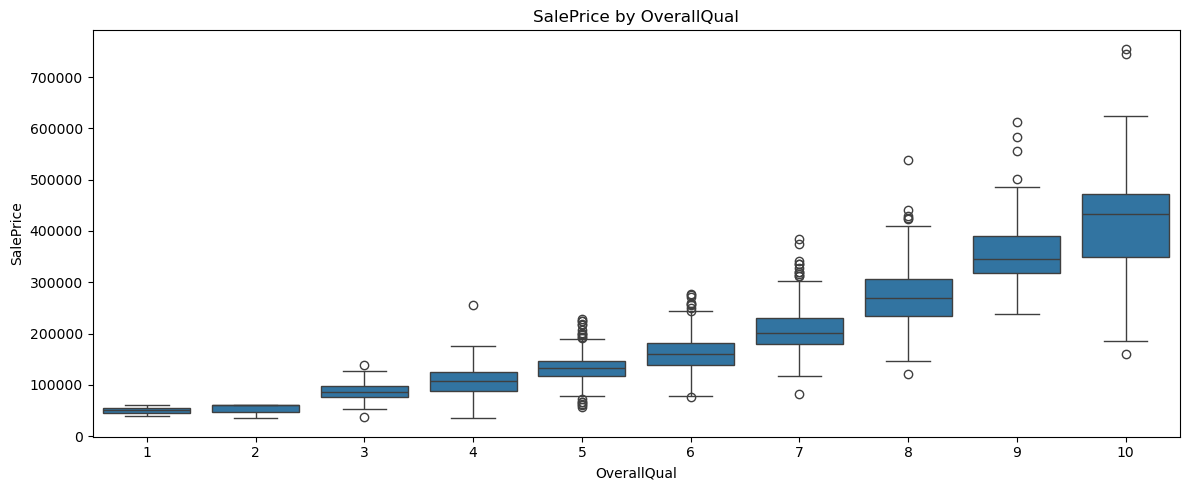

In [151]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=ax)
ax.set_title('SalePrice by OverallQual')
plt.tight_layout()
plt.savefig('../plots/Overall Quality boxplots.png')
plt.show()

### Observation
`OverallQual` shows a clear progressive increase in price from rating 1 to 10

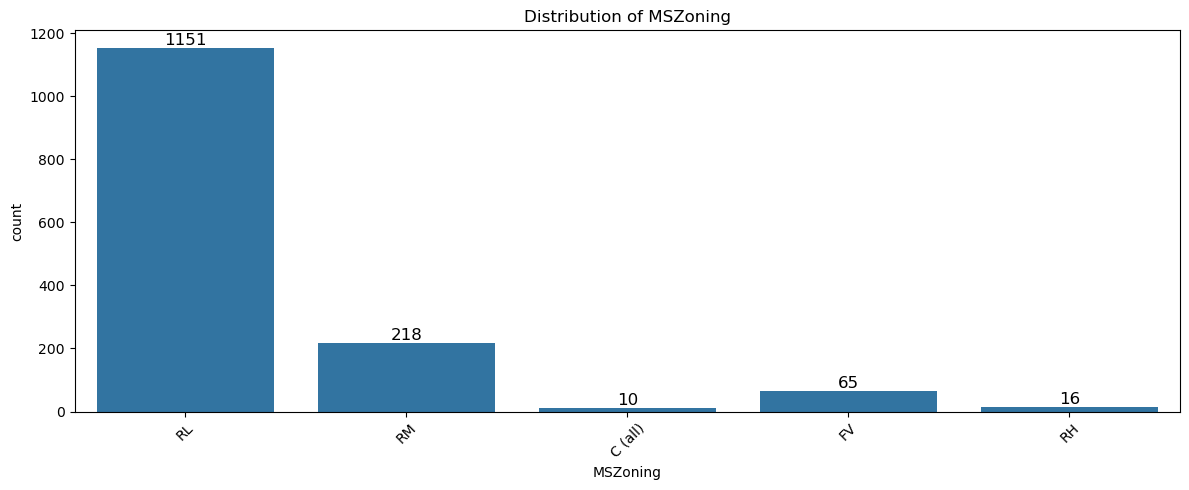

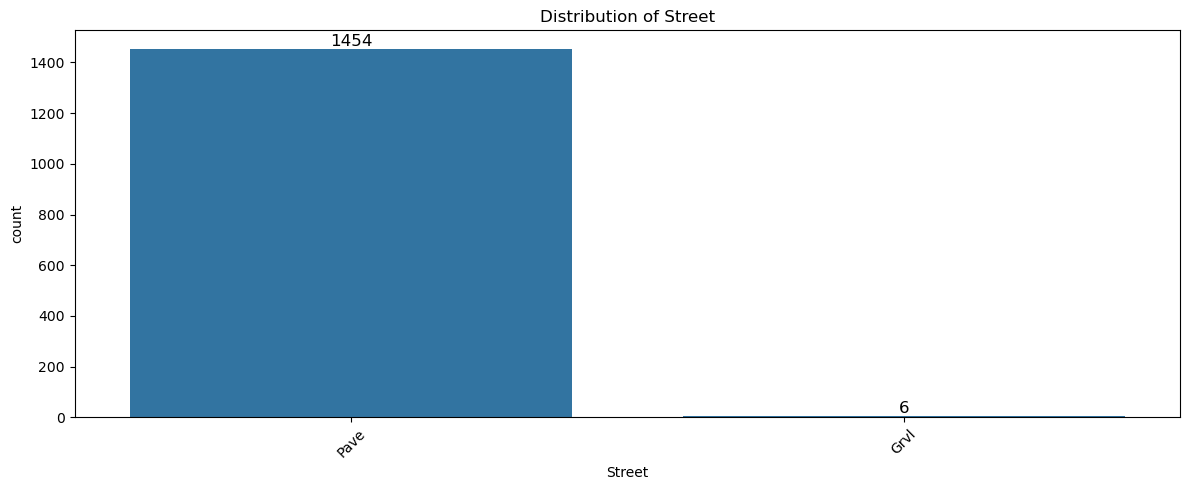

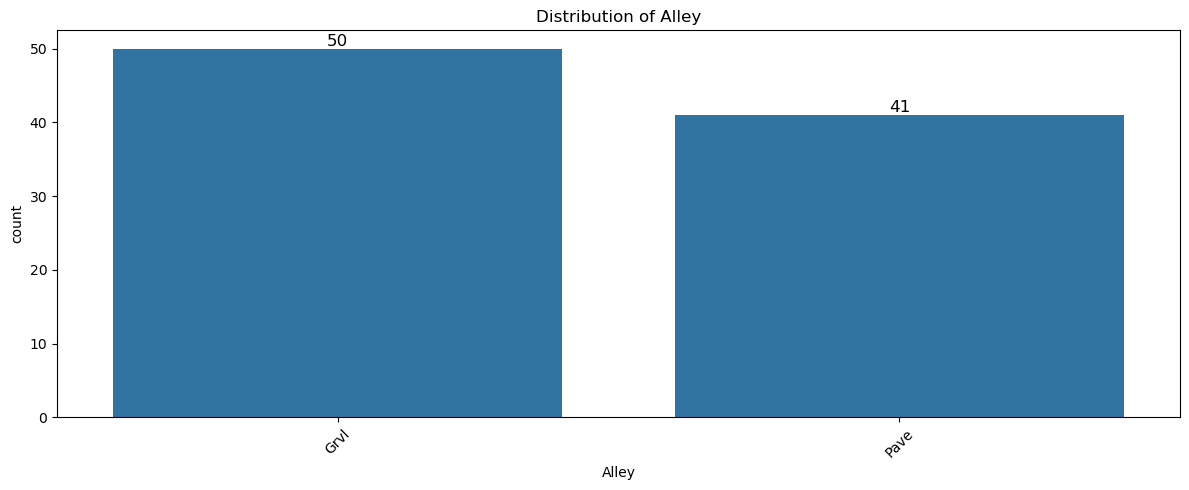

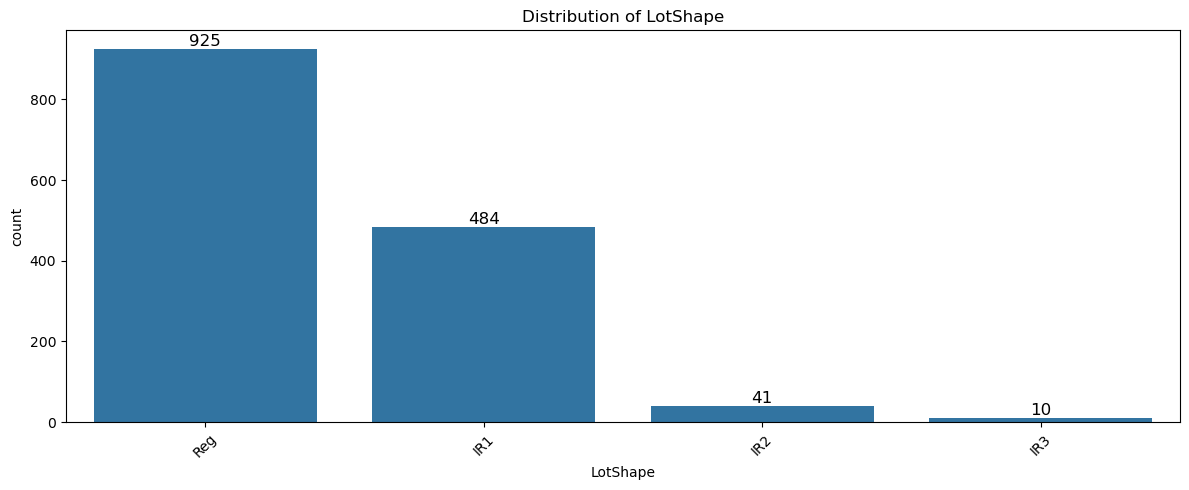

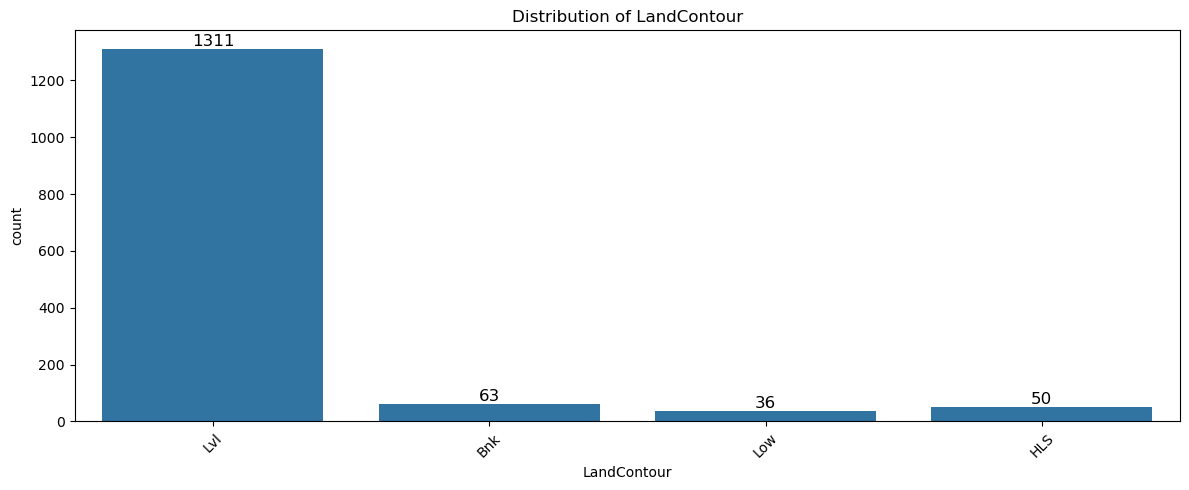

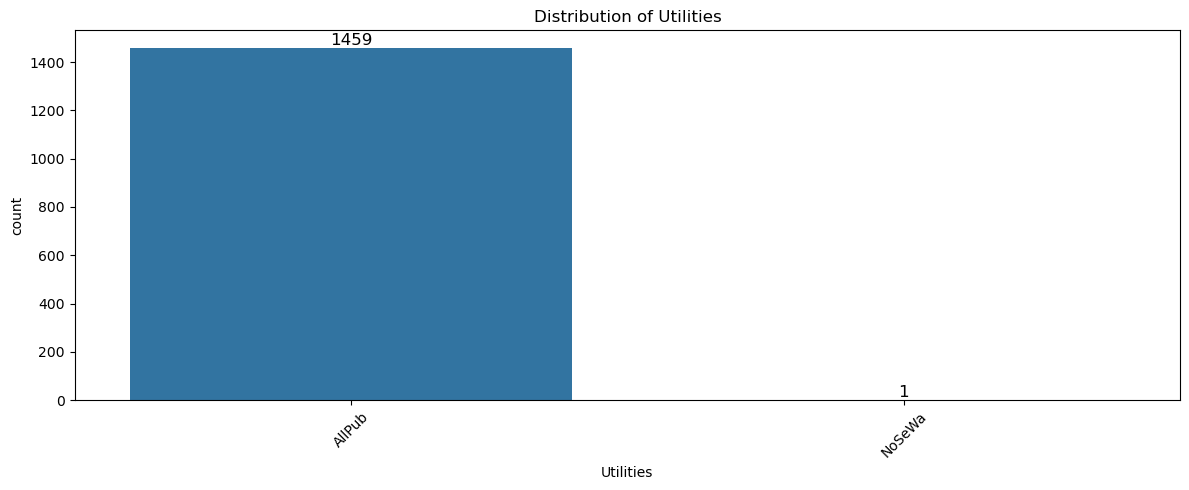

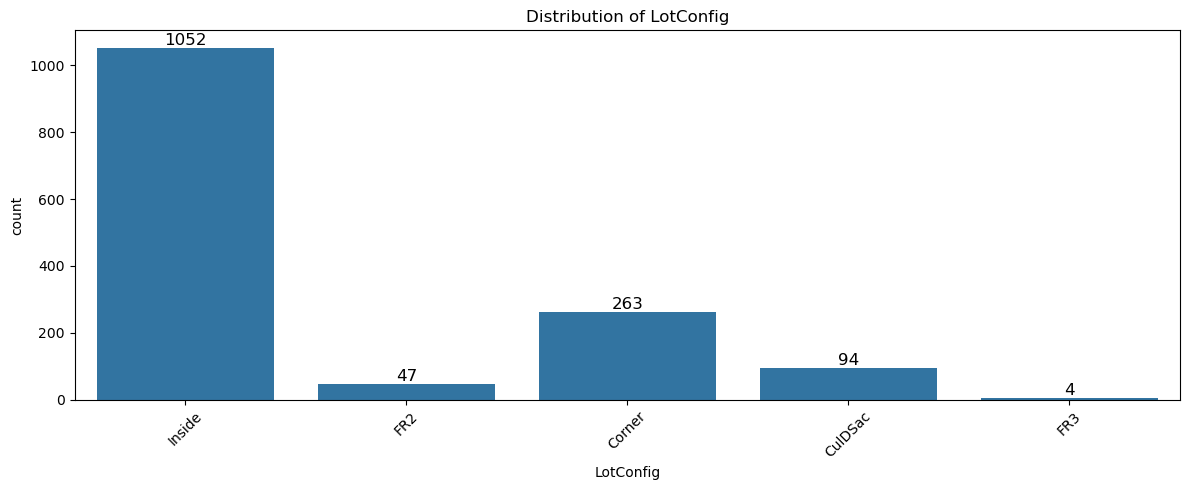

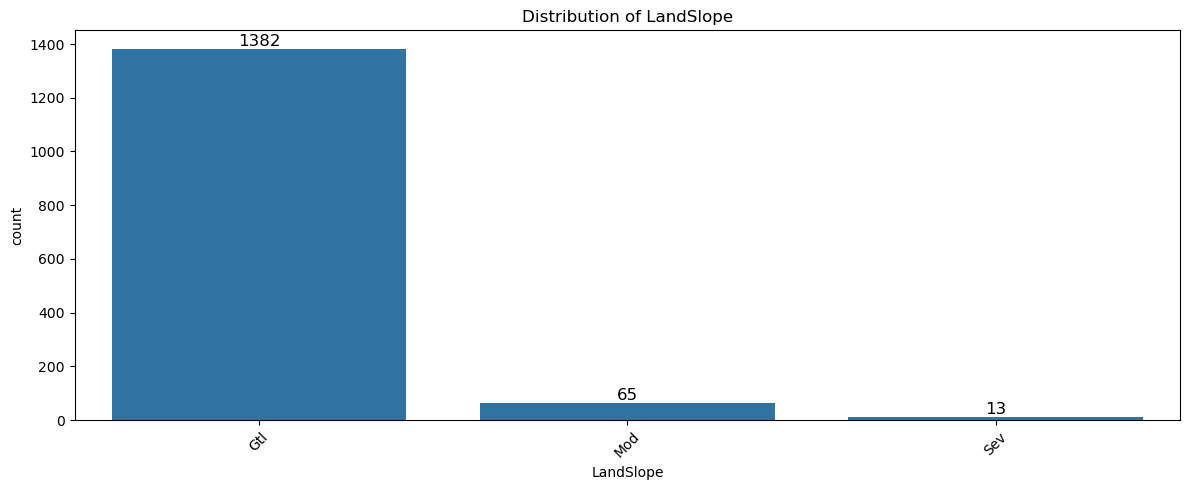

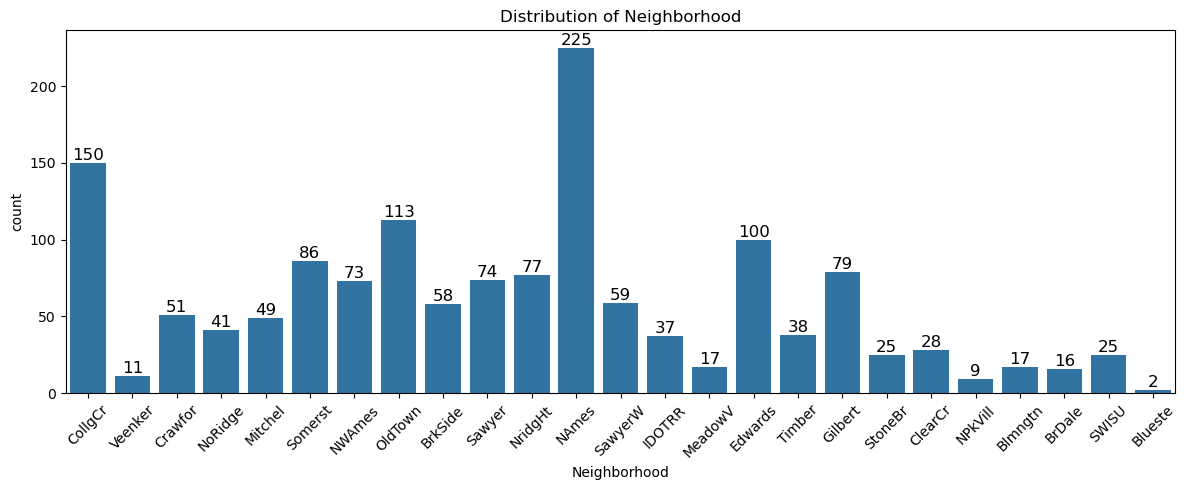

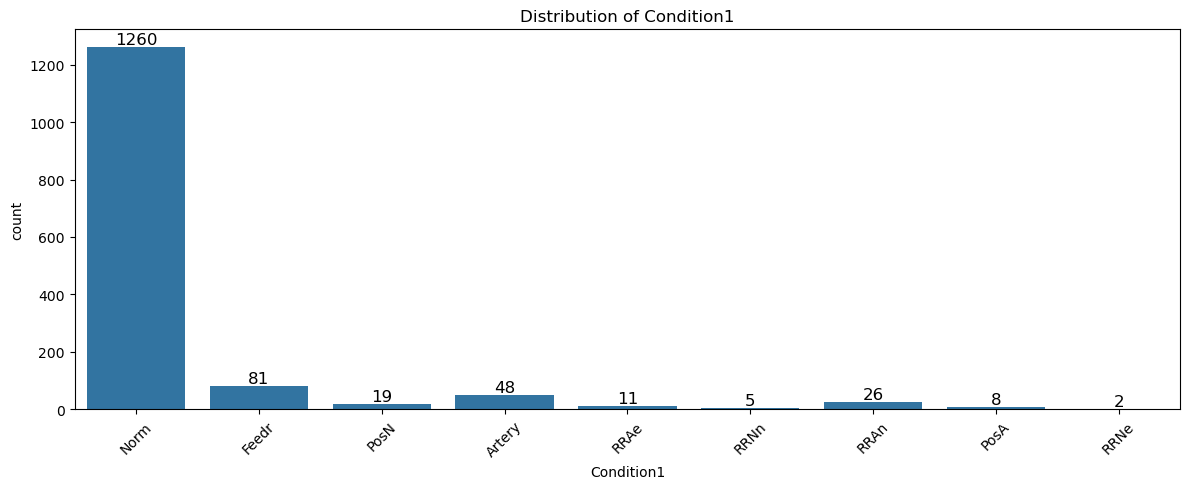

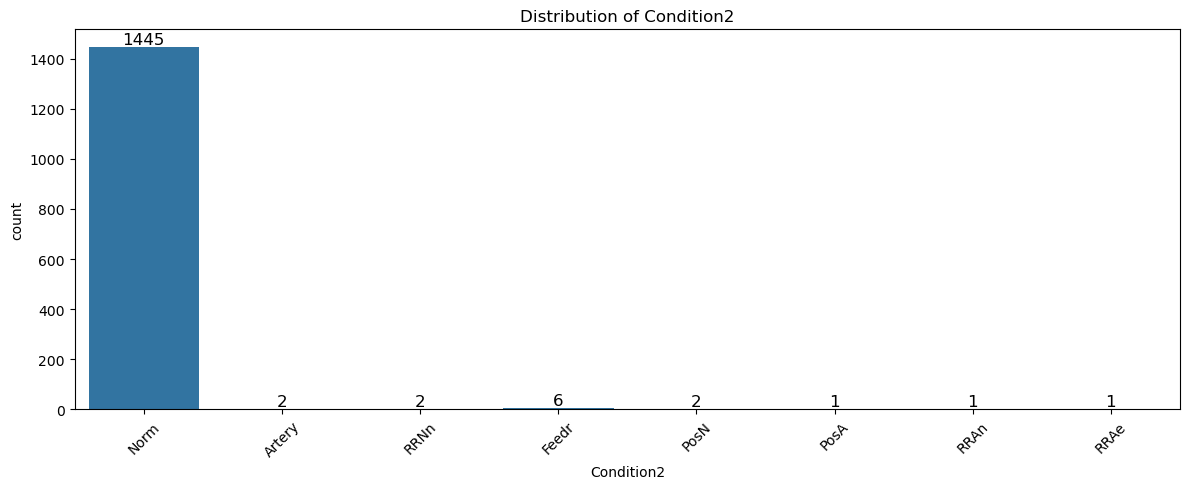

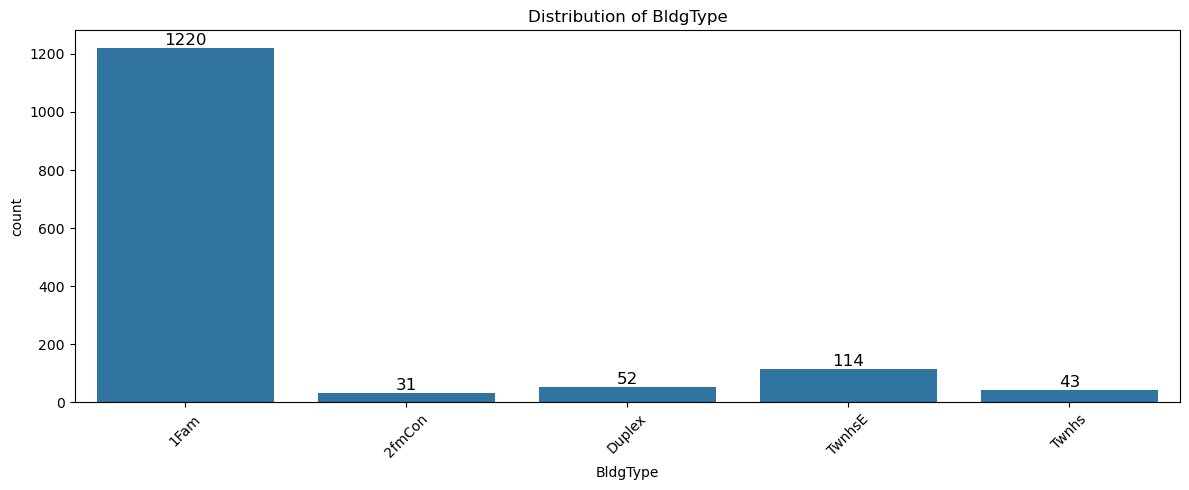

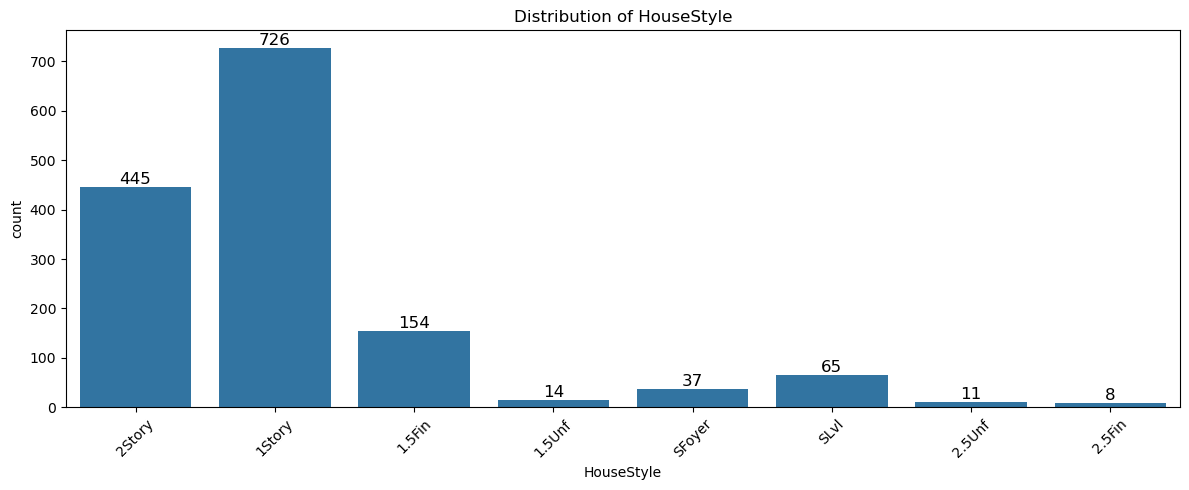

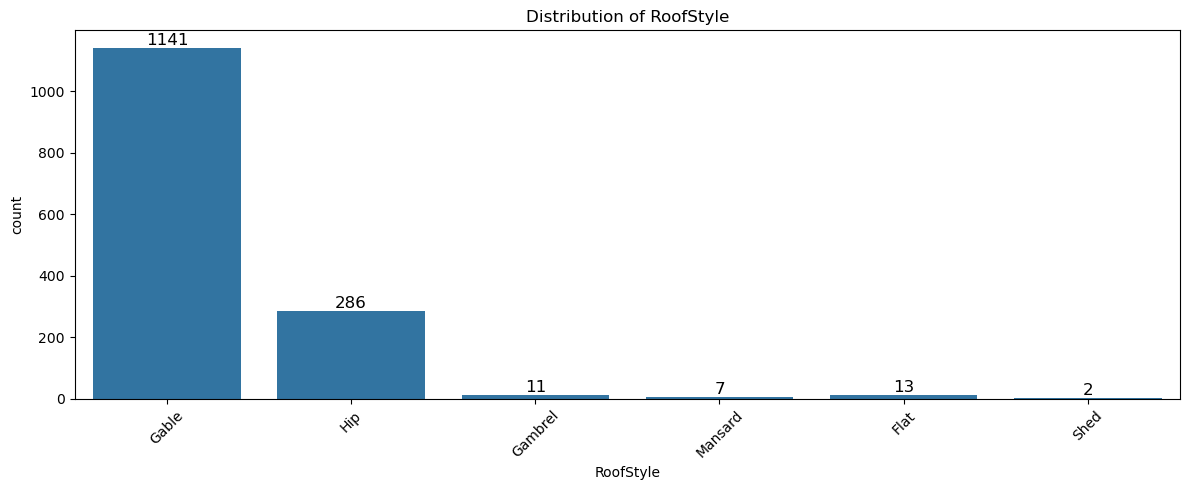

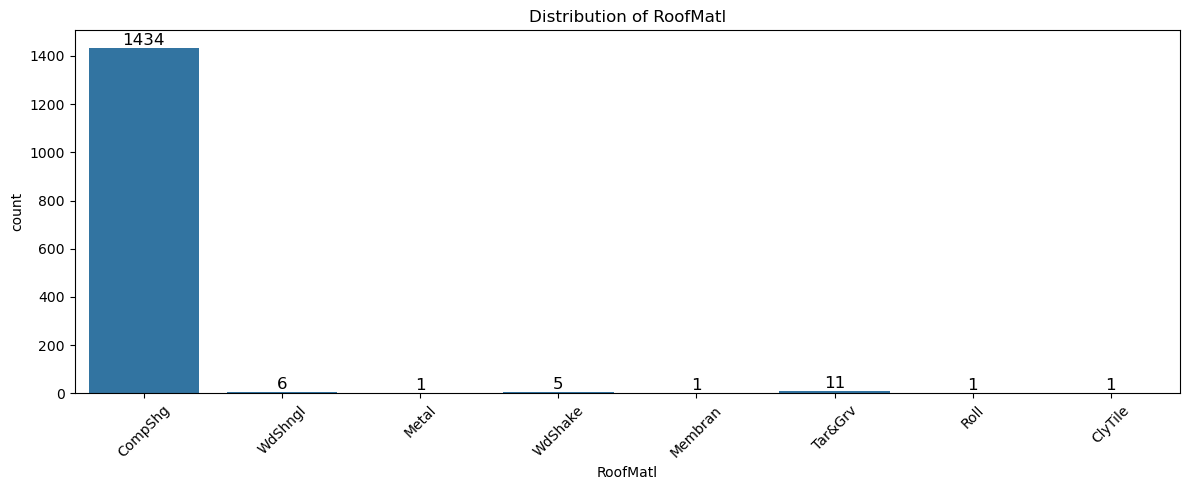

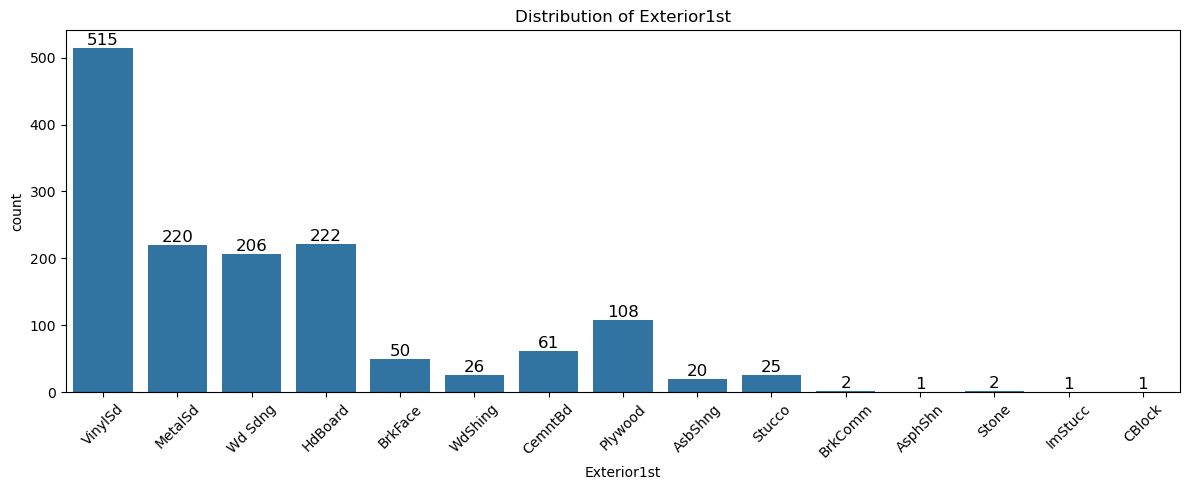

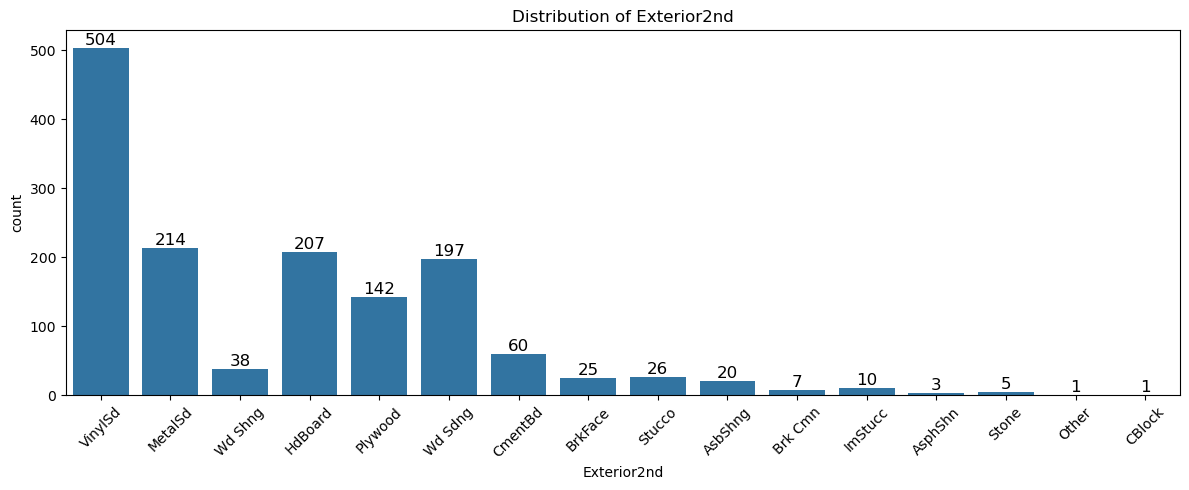

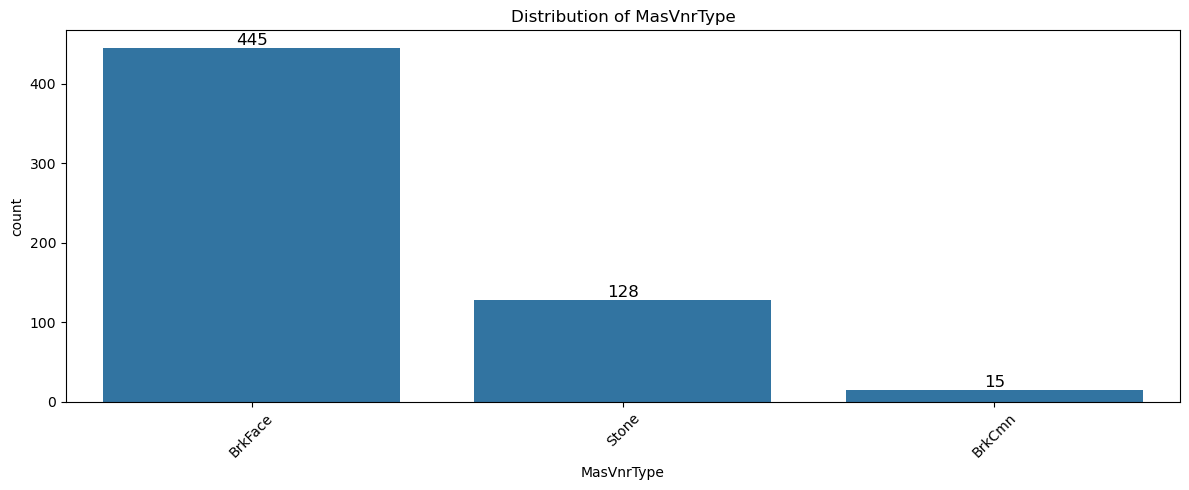

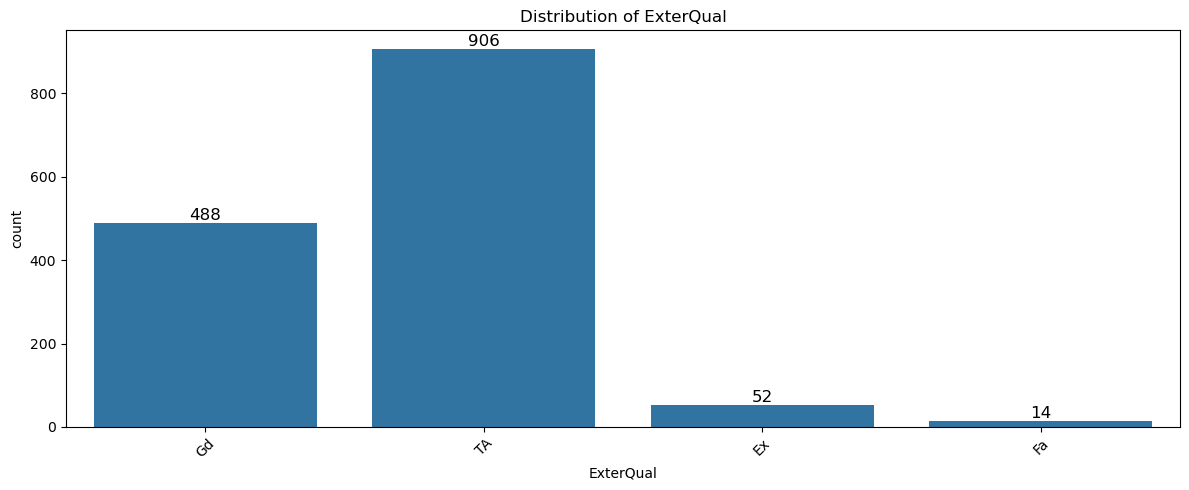

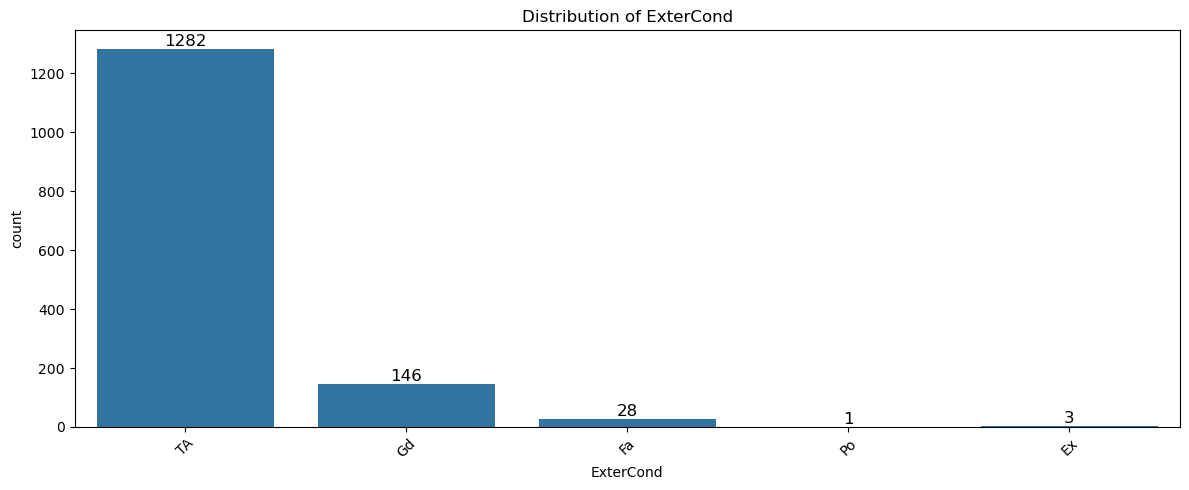

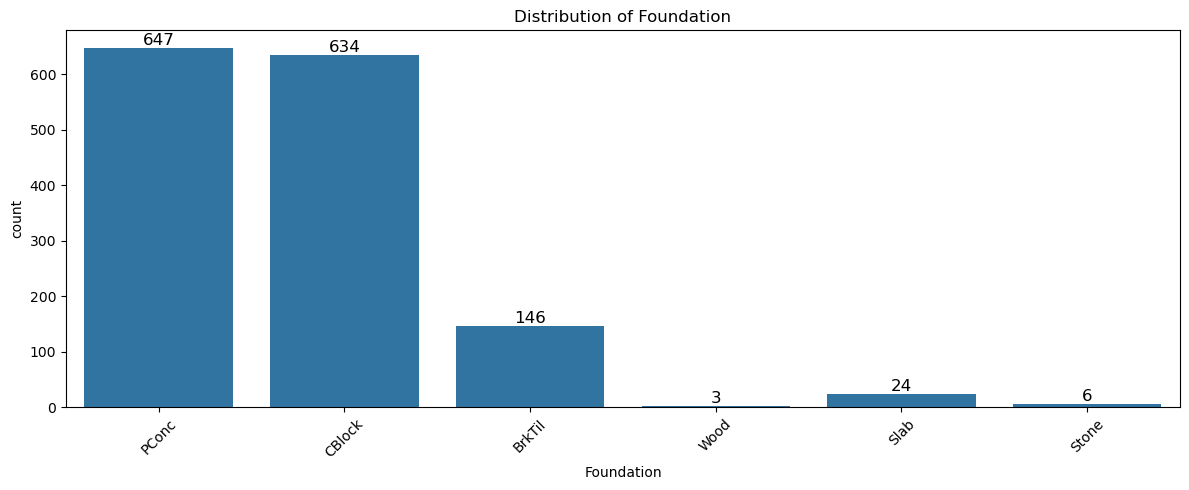

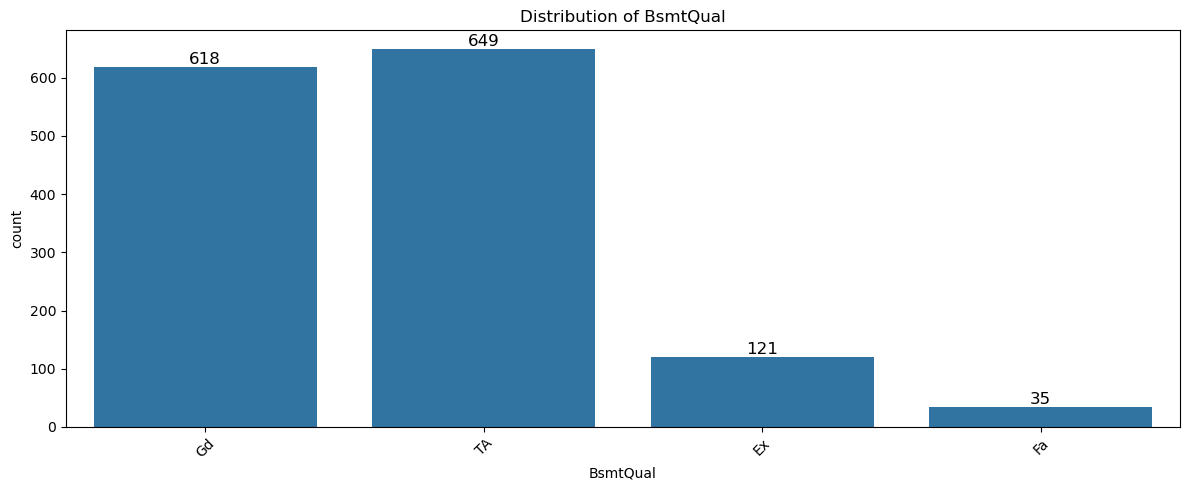

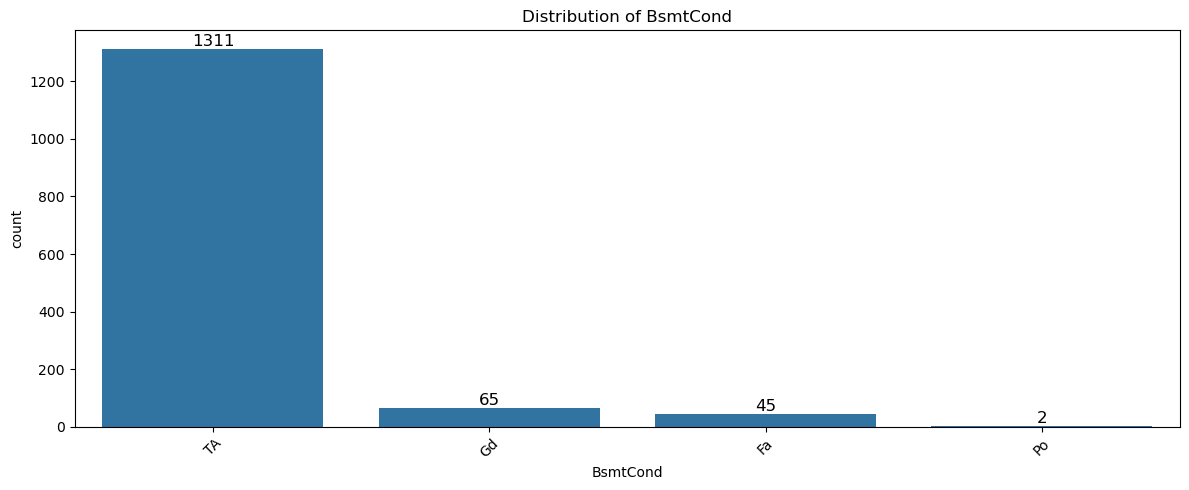

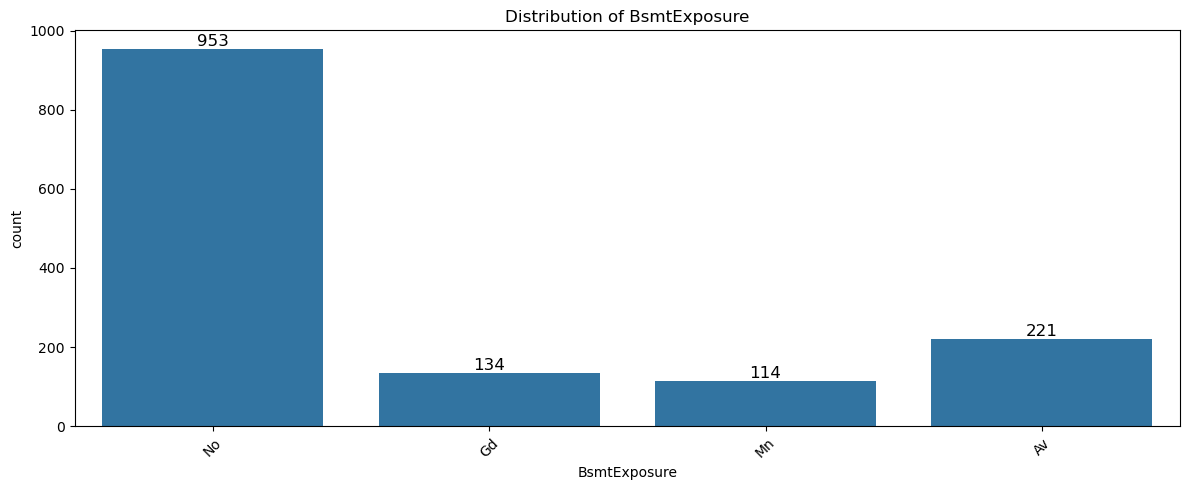

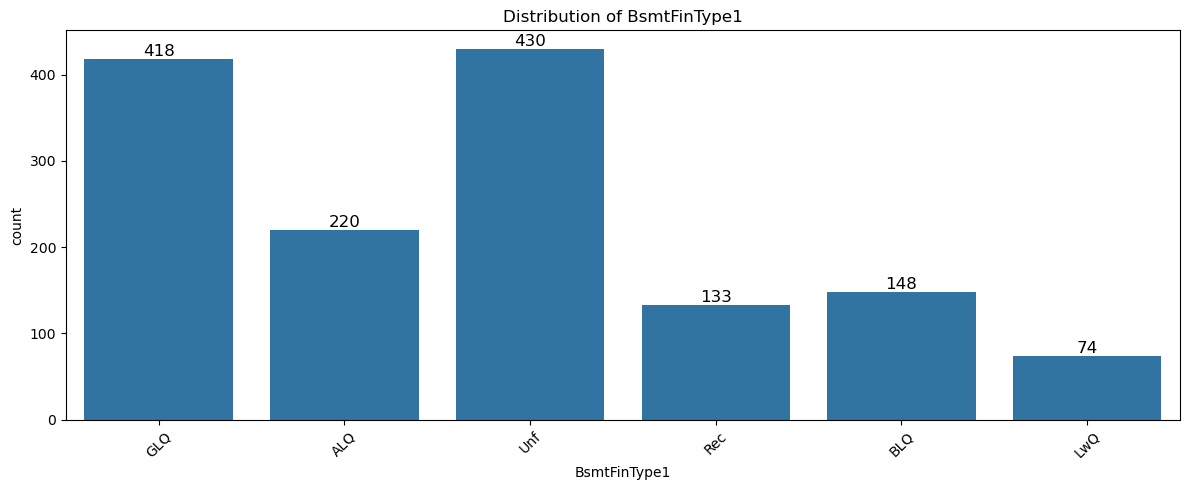

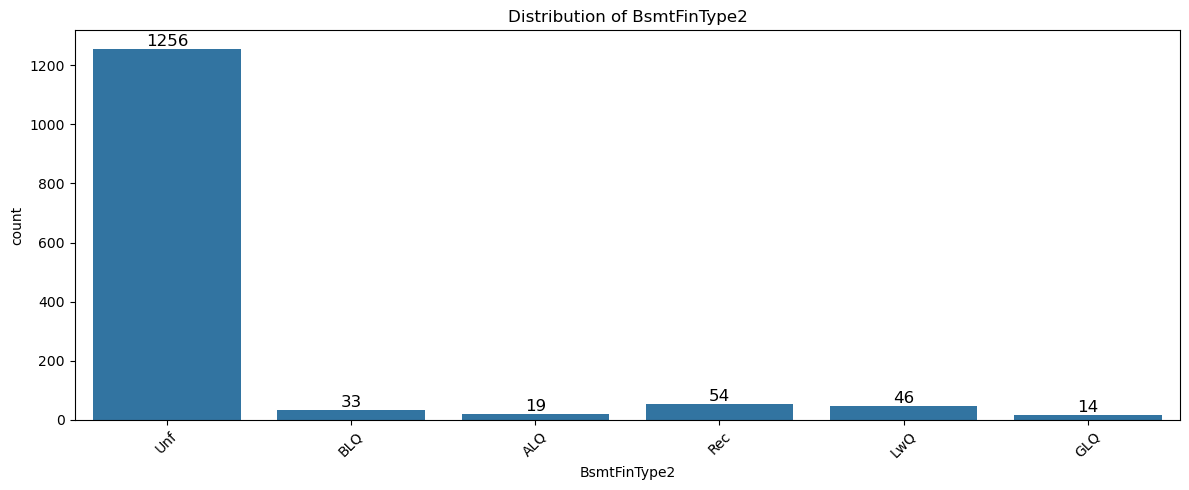

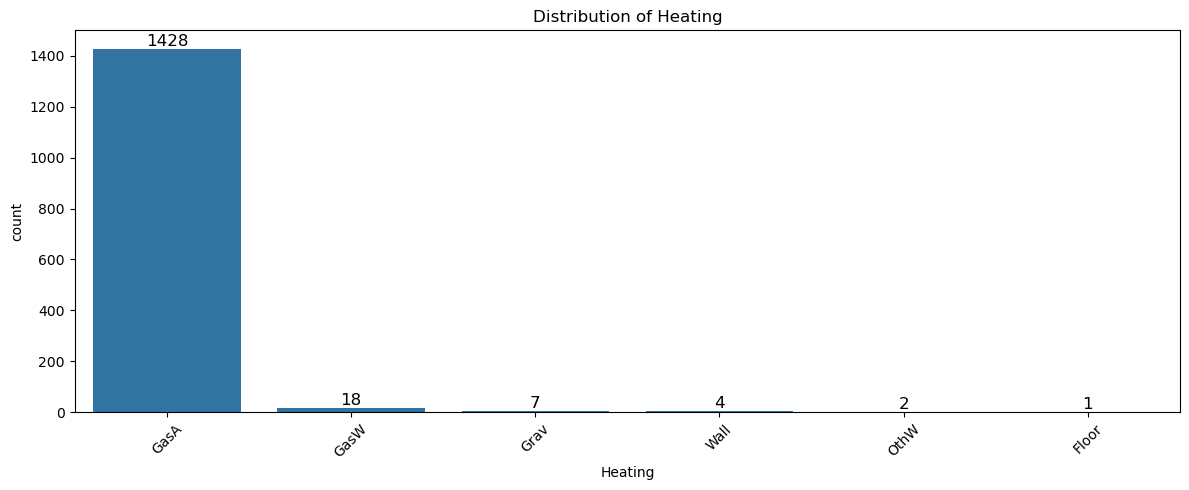

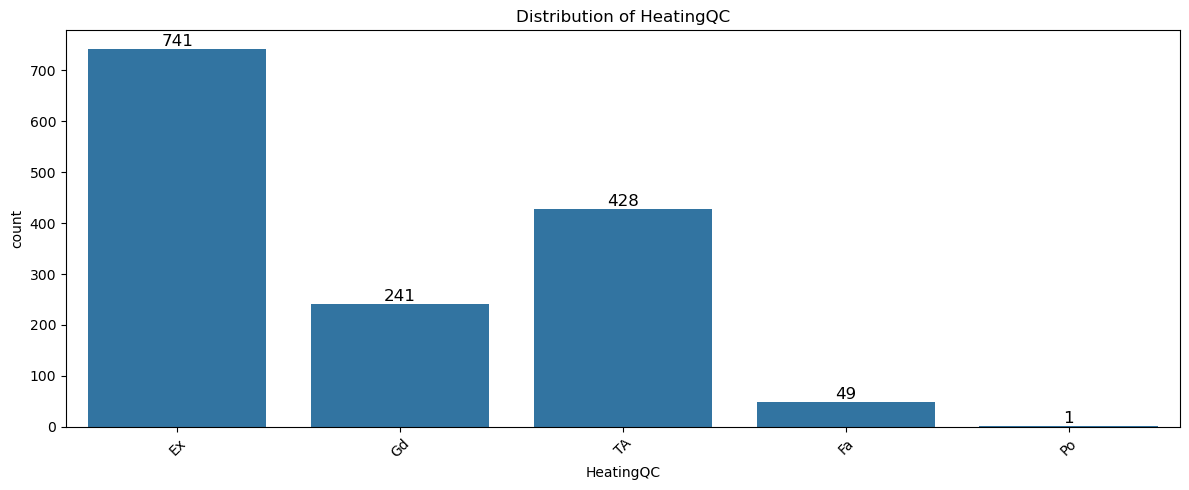

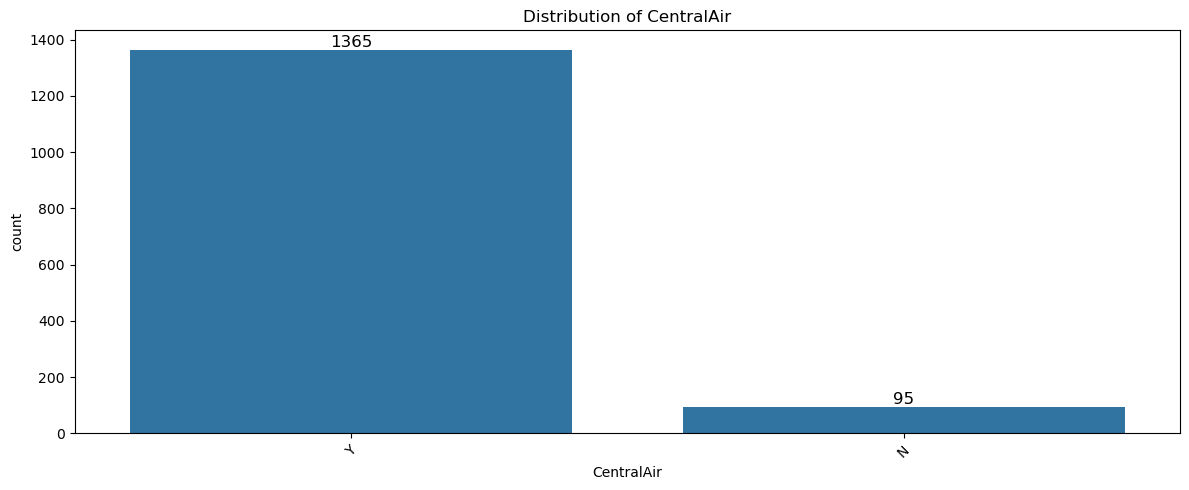

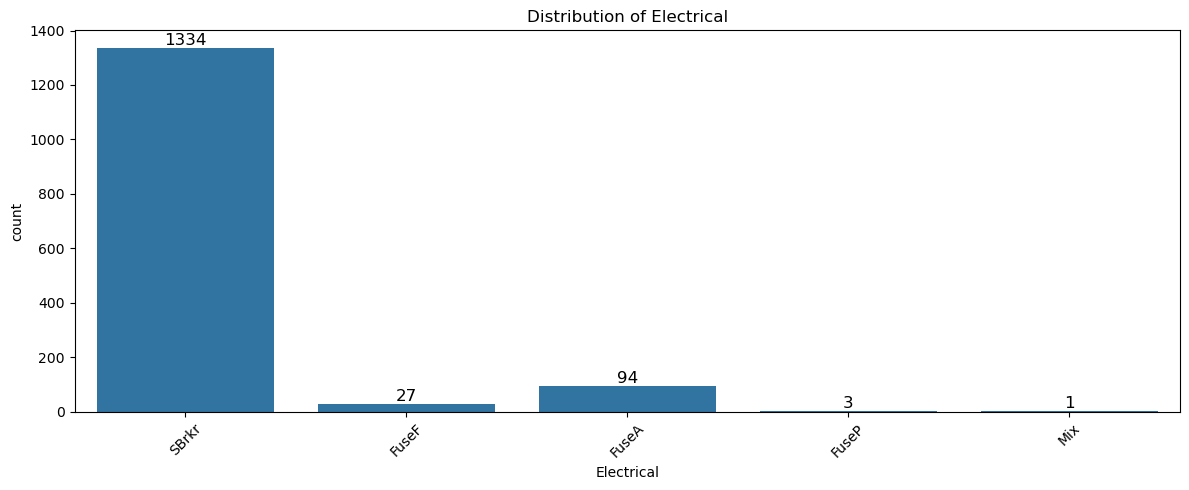

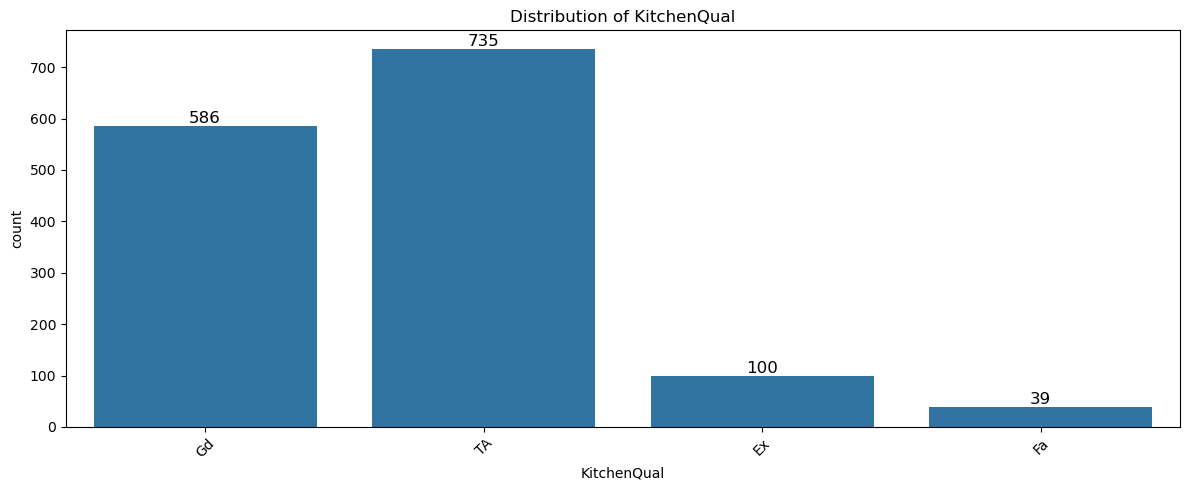

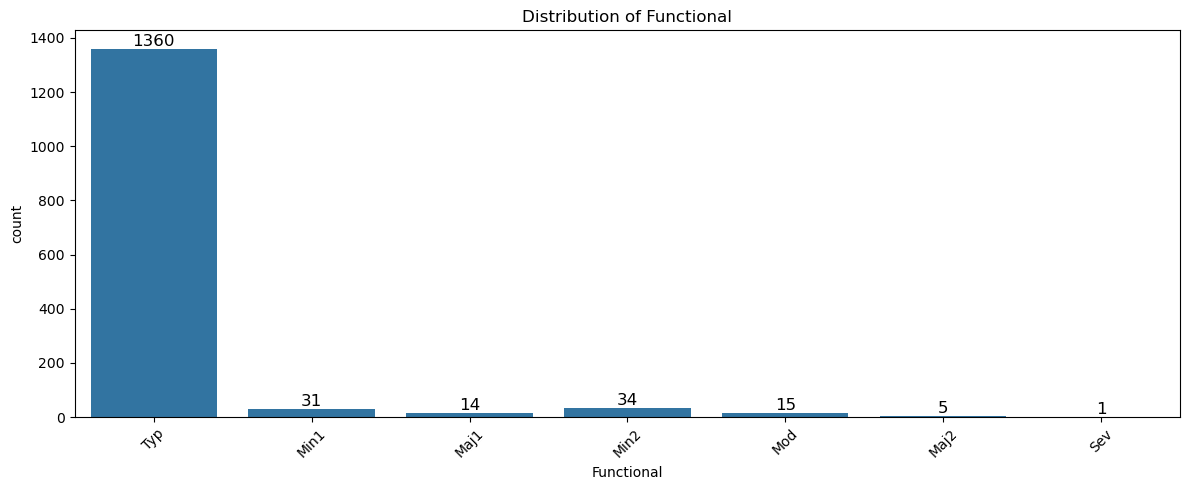

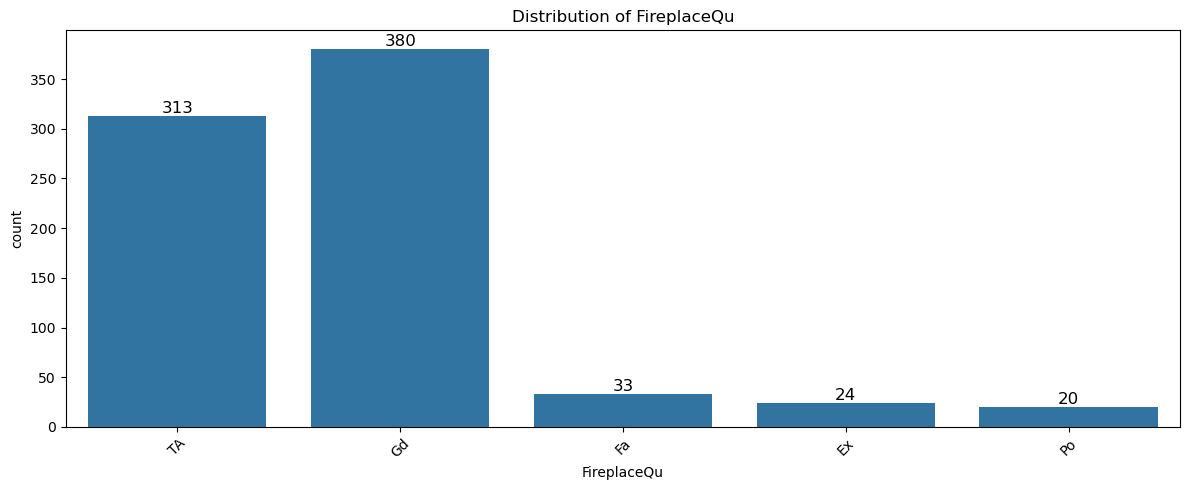

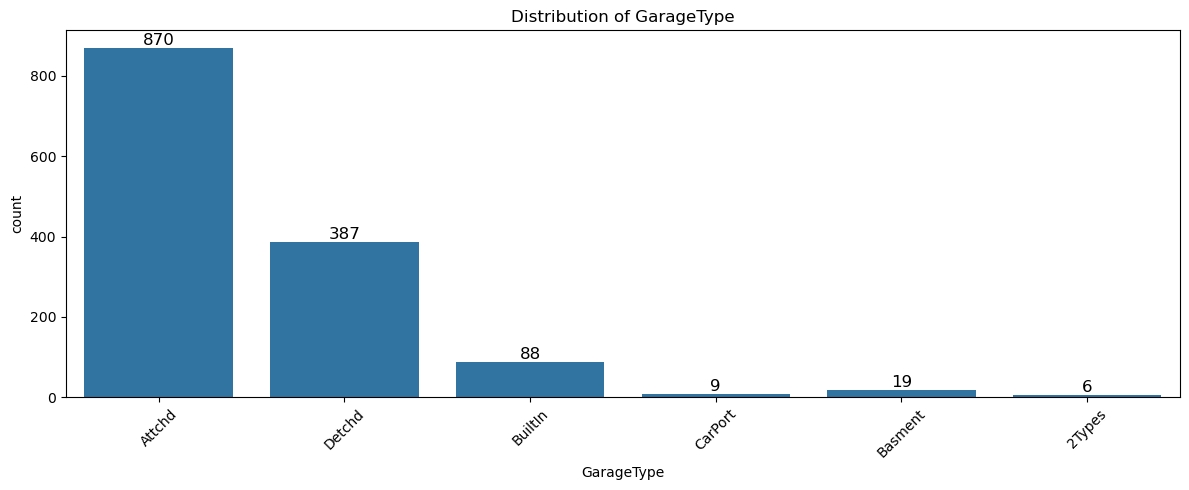

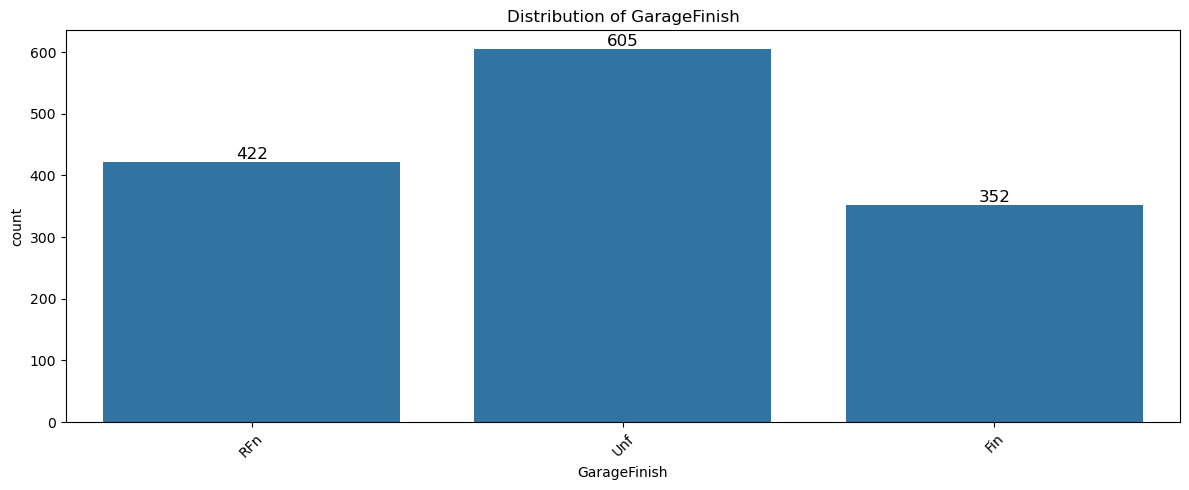

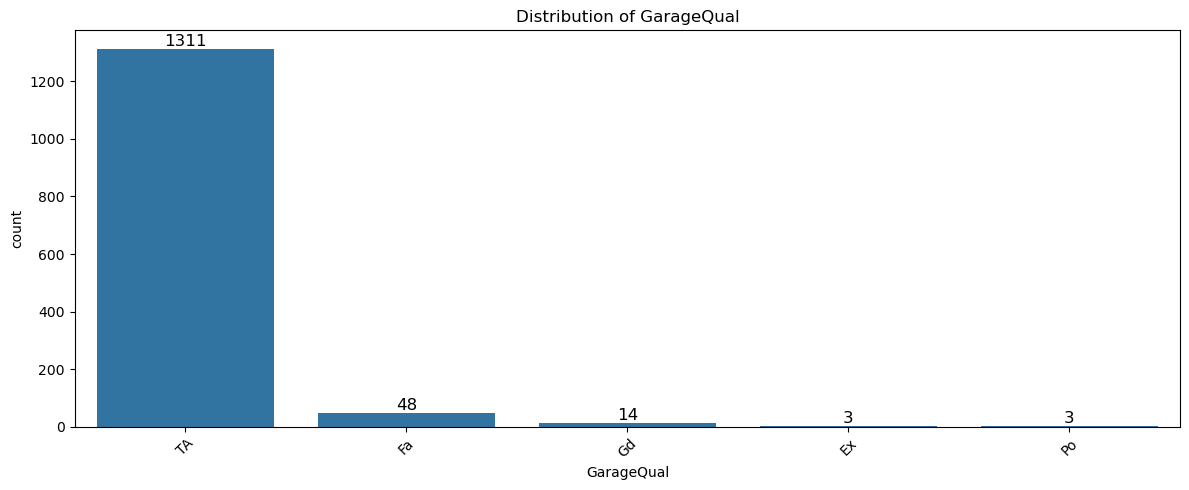

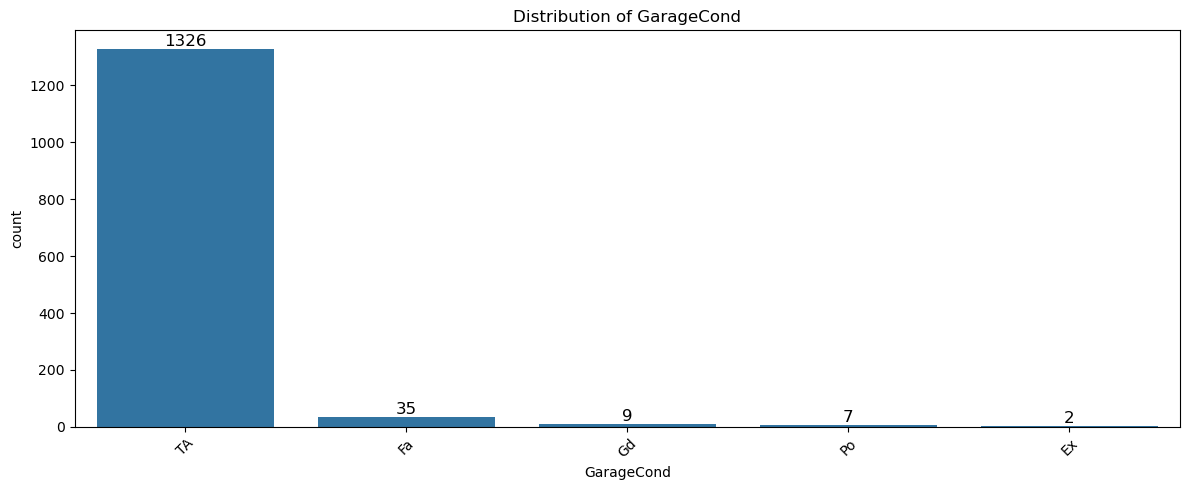

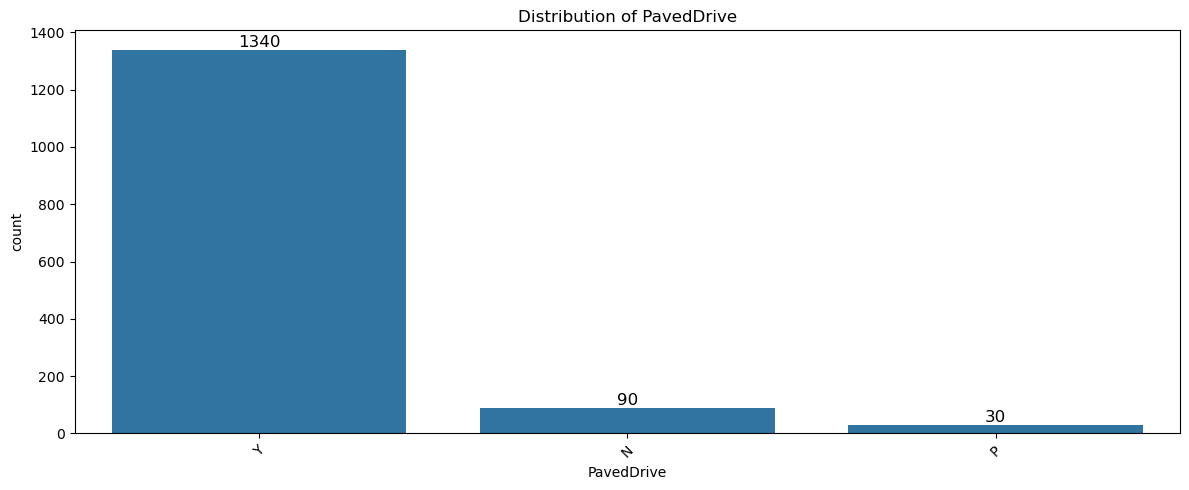

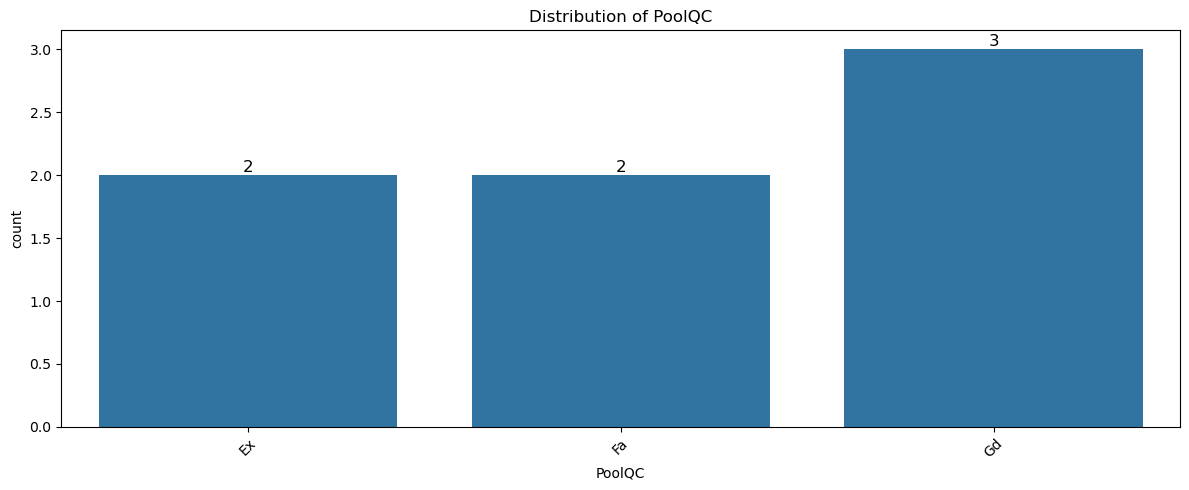

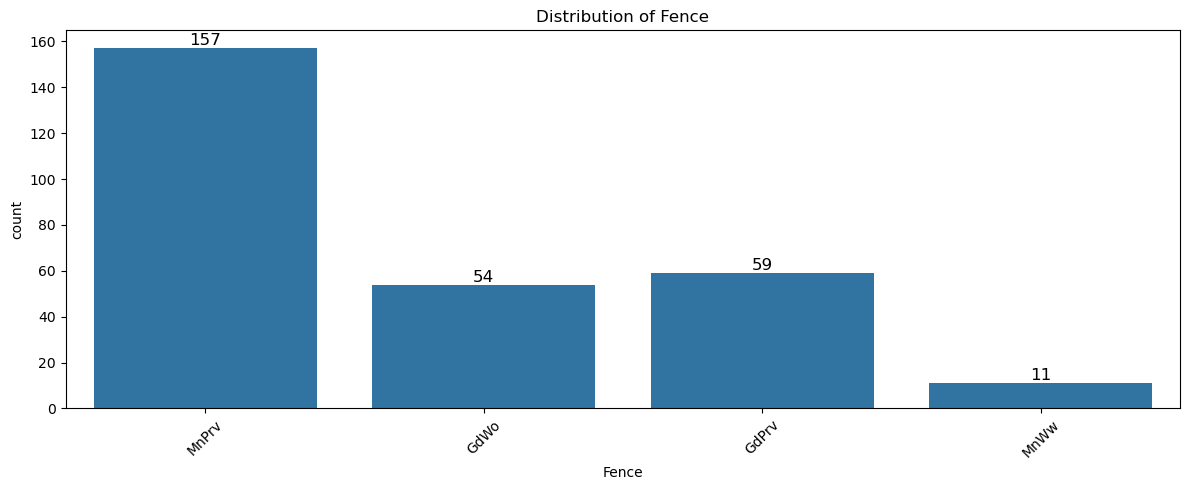

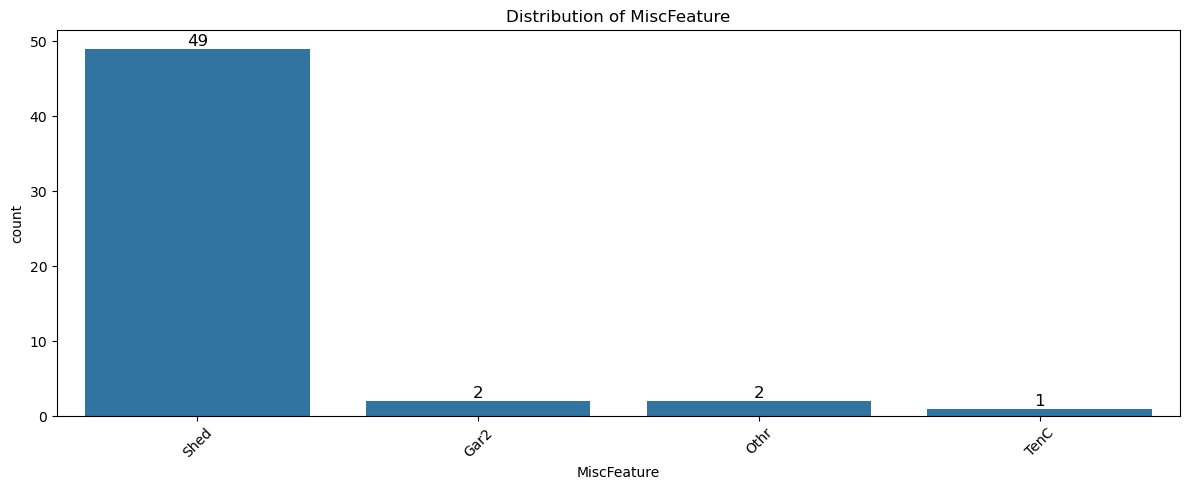

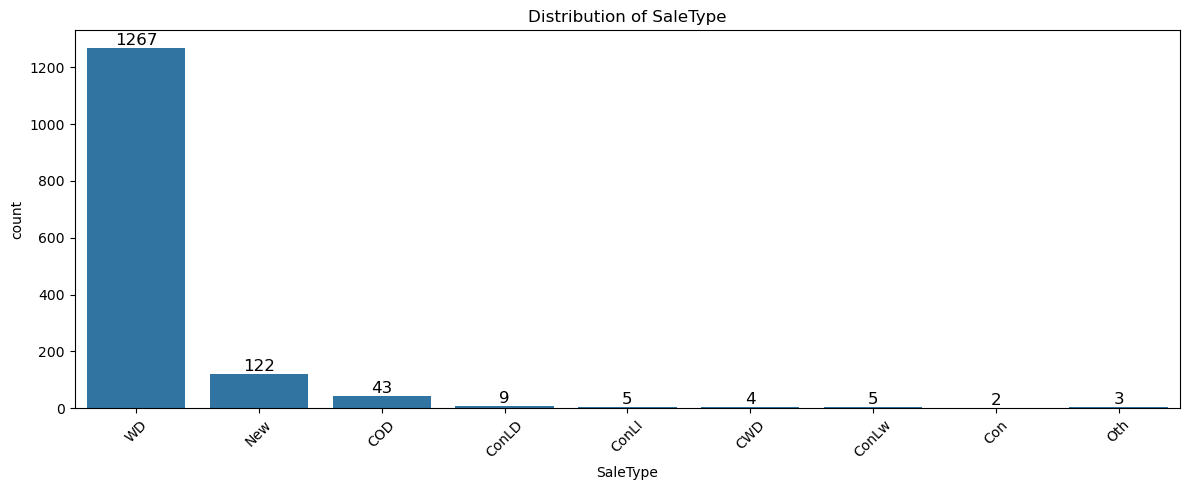

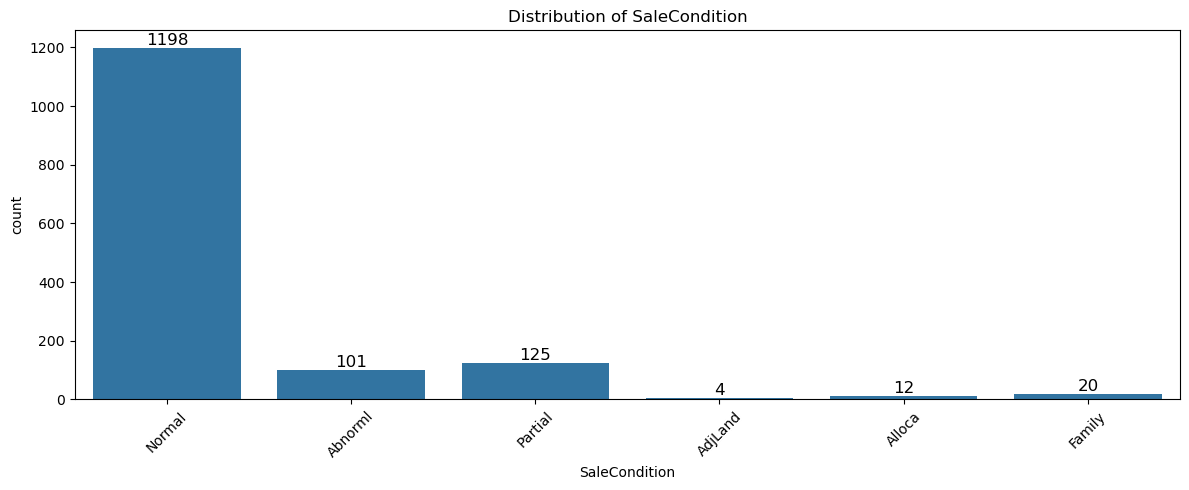

In [144]:
for col in cat_cols:
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.countplot(x=col, data=df, ax=ax)
    ax.bar_label(ax.containers[0], size = 12)
    ax.set_title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### SalePrice vs Categorical features - Countplots
Countplots give us the number of rows that belong to each value for a particular category.
It helps us in feature selection by revealing **class imbalance**. For example, if one category dominates a feature, that feature may provide limited information on its own, but it is not automatically useless. Its actual predictive value should be judged during modeling.